# MVTec AD — V5.1 FINAL FIXED LOGSUMEXP
## Confirmatory fixed-aggregation reproducibility run

This notebook is the **frozen V5.1 Protocol-A configuration** for the final three-seed reproducibility experiment.

### Frozen choices
- Backbone: ViT-B/16
- SSL: SimCLR-v2, `pretrained=False`
- Patch layers: transformer blocks 6, 9, 12
- Primary detector: local patch detector
- Patch prototypes/category: 1024
- **Image aggregation: `logsumexp_t4` fixed before this rerun**
- Image-level scoring: position-wise robust patch calibration + normal-only image calibration
- Localization: `raw_patch_knn`
- Hybrid: fixed 25% global / 75% local, **secondary ablation only**
- Seeds: 42, 123, 2026

### Important execution rule
For the final reproducibility experiment, change **only**:

```python
seed: int = 2026
```

to `123` or `2026` for the other runs. Do not change any other detector, calibration, aggregation, layer, prototype, or threshold setting.

### Checkpoint rule
This notebook is **evaluation-only for SSL**. It searches the existing project folder for a scientifically compatible SSL checkpoint with the same seed. If none is found, it stops with an error instead of training a new encoder.

The new version tag writes results to separate run folders, so it will not overwrite the previous V5.1 development runs.

### Methodological note
`logsumexp_t4` is no longer selected inside this notebook. The detector-tuning/synthetic branch is retained only as a diagnostic audit of the already-fixed aggregation. The official MVTec test is not used to choose or alter the aggregation in this final rerun.

Because earlier V5.1 development results on the MVTec test have already been viewed, this should be described as a **fixed-configuration reproducibility rerun on MVTec**, not as restoration of an untouched test set. A completely untouched external benchmark should be used later for confirmatory generalization.


In [1]:
# ============================================================
# 1. COLAB SETUP + CONFIGURATION
# ============================================================

import os
import sys
import json
import math
import random
import subprocess
import hashlib
import shutil
from dataclasses import dataclass, asdict
from pathlib import Path
from contextlib import nullcontext
from typing import Dict, List, Optional, Tuple

# Preserve Colab's CUDA-enabled PyTorch installation.
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "timm", "kagglehub", "scikit-learn", "pandas", "scipy"
])

import numpy as np
import pandas as pd
from PIL import Image, ImageFilter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torchvision.transforms as T

import timm
import kagglehub

from scipy import ndimage
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    precision_recall_fscore_support,
    matthews_corrcoef,
)


@dataclass
class Config:
    # ---------------- Storage ----------------
    use_google_drive: bool = True
    drive_folder: str = "MVTec_SimCLR_ViT_PATCH_PUBLICATION"
    version_tag: str = "v5p1_FINAL_FIXED_LOGSUMEXP"
    manual_mvtec_root: Optional[str] = None
    selected_categories: object = "all"

    # ---------------- Reproducibility ----------------
    seed: int = 2026
    publication_seeds: tuple = (42, 123, 2026)
    ssl_val_fraction: float = 0.20
    # The normal SSL-validation pool reserves 30% for detector tuning and 70% for threshold calibration.
    detector_tune_fraction_of_ssl_val: float = 0.30

    # Downstream supervised split INSIDE official test.
    downstream_train_fraction: float = 0.60
    downstream_val_fraction: float = 0.20
    downstream_test_fraction: float = 0.20

    # ---------------- Images / encoder ----------------
    image_size: int = 224
    backbone: str = "vit_base_patch16_224"
    pretrained: bool = False
    projection_hidden_dim: int = 4096
    projection_dim: int = 256

    # ---------------- Industrial-preserving SimCLR augmentation ----------------
    # Less destructive than generic SimCLR because color/texture/geometry can
    # themselves be anomaly cues in industrial inspection.
    augmentation_profile: str = "industrial_preserving_v1"
    crop_scale_min: float = 0.60
    horizontal_flip_p: float = 0.50
    color_jitter_strength: float = 0.40
    hue_jitter: float = 0.05
    color_jitter_p: float = 0.70
    grayscale_p: float = 0.10
    gaussian_blur_p: float = 0.30

    # ---------------- SimCLR ----------------
    epochs: int = 200
    # Actual contrastive batch size matters because negatives are formed
    # inside each micro-batch. 16 is a practical L4/24-GB default; on A100
    # you can test 32 as a separate ablation/run.
    batch_size: int = 16
    accumulation_steps: int = 2
    num_workers: int = 2
    eval_num_workers: int = 0  # avoids DataLoader worker-cleanup warnings
    warmup_epochs: int = 10
    encoder_lr: float = 1e-4
    projector_lr: float = 3e-4
    weight_decay_encoder: float = 1e-2
    weight_decay_projector: float = 1e-4
    temperature: float = 0.10
    max_grad_norm: float = 1.0
    use_amp: bool = True
    ssl_early_stopping_patience: int = 30
    resume_ssl: bool = False
    # Reuse a scientifically compatible V3 SSL checkpoint when available.
    reuse_compatible_ssl_checkpoint: bool = True

    # ---------------- Protocol A: global anomaly scoring ----------------
    eval_batch_size: int = 32
    threshold_quantile: float = 0.95
    knn_k: int = 3
    reference_bank_max_per_category: int = 1000
    normalize_encoder_features: bool = True


    # ---------------- Protocol A V5.1: local-primary multi-layer patch scoring ----------------
    # Zero-based indices -> transformer blocks 6, 9 and 12.
    patch_layer_indices: tuple = (5, 8, 11)
    patch_projection_dim: int = 256
    patch_candidate_max_per_category: int = 25000
    patch_prototype_count: int = 1024
    patch_knn_k: int = 3
    patch_kmeans_batch_size: int = 2048
    patch_kmeans_max_iter: int = 50

    # V4 synthetic tuning selected zero spatial penalty. V5.1 keeps zero spatial
    # matching. Position calibration is used ONLY for image-level scoring;
    # localization uses the raw feature-space patch kNN distances.
    patch_spatial_penalty_candidates: tuple = (0.00,)
    patch_spatial_penalty: float = 0.00

    # FINAL FROZEN aggregation for the confirmatory reproducibility rerun.
    # It is NOT selected inside this notebook.
    final_fixed_patch_aggregation: str = "logsumexp_t4"

    # Kept as a one-item tuple only so the existing synthetic diagnostic code
    # can audit the fixed rule without performing model selection.
    patch_aggregation_candidates: tuple = ("logsumexp_t4",)

    # V5.1 proposed method is LOCAL PATCH ONLY. A fixed 25% global / 75% local
    # hybrid is retained only as an ablation and is not tuned on the test set.
    primary_detector: str = "local_patch"
    fixed_hybrid_global_weight: float = 0.25

    # Synthetic anomaly generation for hyperparameter selection only.
    # Multiple deterministic variants improve the reliability of detector tuning.
    synthetic_variants_per_image: int = 4
    synthetic_patch_min_fraction: float = 0.015
    synthetic_patch_max_fraction: float = 0.14
    synthetic_anomaly_types: tuple = (
        "scratch", "stain", "irregular_cutpaste",
        "texture_noise", "local_contrast", "small_blur"
    )
    synthetic_selection_auc_weight: float = 0.70
    synthetic_selection_balanced_accuracy_weight: float = 0.20
    synthetic_selection_recall_weight: float = 0.10

    # Position-wise patch calibration and image-level normal calibration.
    position_calibration_positive_only: bool = False
    position_calibration_clip_z: float = 15.0
    robust_scale_eps: float = 1e-6

    # Compatibility defaults used by helper/plotting code.
    patch_top_fraction: float = 0.01
    hybrid_global_weight: float = 0.25

    # Pixel-level localization evaluation. V5.1 explicitly decouples the
    # localization heatmap from position-calibrated image scoring.
    localization_map_mode: str = "raw_patch_knn"
    pixel_aupro_max_fpr: float = 0.30
    pixel_aupro_thresholds: int = 100

    # Test-set uncertainty reporting only; never used for tuning.
    bootstrap_iterations: int = 1000

    # ---------------- Protocol B: frozen-feature probing ----------------
    probe_epochs: int = 200
    probe_batch_size: int = 128
    probe_lr: float = 1e-3
    probe_weight_decay: float = 1e-4
    category_loss_weight: float = 1.0
    anomaly_loss_weight: float = 1.0
    defect_loss_weight: float = 1.0
    probe_early_stopping_patience: int = 30
    resume_probe: bool = True
    strict_embedding_cache: bool = True
    # Adds local patch distribution statistics to the global ViT feature.
    probe_feature_mode: str = "global_plus_patch_stats"

    # ---------------- Runtime ----------------
    require_gpu: bool = True
    quick_test: bool = False

    # FINAL safety switch: never train a new SSL encoder in this notebook.
    # A compatible existing checkpoint for the current seed is required.
    final_eval_only: bool = True


CFG = Config()

# FINAL frozen-run safety assertions.
assert CFG.seed in CFG.publication_seeds, "Use only publication seeds: 42, 123, 2026."
assert CFG.final_eval_only is True
assert CFG.final_fixed_patch_aggregation == "logsumexp_t4"
assert tuple(CFG.patch_aggregation_candidates) == ("logsumexp_t4",)

print("FINAL FIXED RUN")
print("Seed:", CFG.seed)
print("Fixed aggregation:", CFG.final_fixed_patch_aggregation)
print("SSL training allowed:", not CFG.final_eval_only)

if CFG.quick_test:
    CFG.epochs = 2
    CFG.probe_epochs = 5
    CFG.ssl_early_stopping_patience = 2
    CFG.probe_early_stopping_patience = 3
    CFG.patch_candidate_max_per_category = 3000
    CFG.patch_prototype_count = 128
    CFG.bootstrap_iterations = 100


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(CFG.seed)

# ---------------- Persistent run directory ----------------
# A configuration hash is deliberately part of the path. This makes it very
# difficult to accidentally resume an incompatible model or reuse stale caches.
config_payload = json.dumps(asdict(CFG), sort_keys=True, default=str)
CONFIG_SIGNATURE = hashlib.sha256(config_payload.encode("utf-8")).hexdigest()[:10]
RUN_NAME = (
    f"{CFG.version_tag}_{CFG.backbone}_pre{int(CFG.pretrained)}_"
    f"{CFG.augmentation_profile}_seed{CFG.seed}_{CONFIG_SIGNATURE}"
)

if CFG.use_google_drive:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive") / CFG.drive_folder
else:
    PROJECT_ROOT = Path("/content") / CFG.drive_folder

WORK_DIR = PROJECT_ROOT / RUN_NAME
RESULTS_DIR = WORK_DIR / "results"
MODELS_DIR = RESULTS_DIR / "models"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"
METADATA_DIR = WORK_DIR / "metadata"
CACHE_DIR = WORK_DIR / "cache"
PATCH_BANK_DIR = RESULTS_DIR / "patch_banks"

for directory in [
    PROJECT_ROOT, WORK_DIR, RESULTS_DIR, MODELS_DIR, TABLES_DIR,
    FIGURES_DIR, METADATA_DIR, CACHE_DIR, PATCH_BANK_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# ---------------- Device ----------------
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = bool(CFG.use_amp and DEVICE.type == "cuda")

print("Project root:", PROJECT_ROOT)
print("Run directory:", WORK_DIR)
print("Run signature:", CONFIG_SIGNATURE)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA runtime:", torch.version.cuda)
    print(
        "GPU memory (GB):",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1),
    )

if CFG.require_gpu and DEVICE.type != "cuda":
    raise RuntimeError(
        "GPU is required. In Colab choose Runtime -> Change runtime type -> GPU."
    )

if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

# ---------------- Locate/download MVTec AD ----------------
EXPECTED_CATEGORIES = {
    "bottle", "cable", "capsule", "carpet", "grid",
    "hazelnut", "leather", "metal_nut", "pill", "screw",
    "tile", "toothbrush", "transistor", "wood", "zipper"
}


def find_mvtec_root(start_path: str) -> Path:
    start_path = Path(start_path)
    for root, dirs, _files in os.walk(start_path):
        if len(EXPECTED_CATEGORIES.intersection(dirs)) >= 10:
            return Path(root)
    raise FileNotFoundError(f"Could not locate MVTec category folders under {start_path}")


if CFG.manual_mvtec_root is not None:
    DATASET_PATH = Path(CFG.manual_mvtec_root)
    if not DATASET_PATH.exists():
        raise FileNotFoundError(f"manual_mvtec_root does not exist: {DATASET_PATH}")
else:
    download_root = kagglehub.dataset_download("ipythonx/mvtec-ad")
    DATASET_PATH = find_mvtec_root(download_root)

available_categories = sorted(
    c for c in EXPECTED_CATEGORIES
    if (DATASET_PATH / c / "train" / "good").is_dir()
    and (DATASET_PATH / c / "test").is_dir()
)

if CFG.selected_categories == "all":
    CATEGORIES = available_categories
else:
    requested = sorted(list(CFG.selected_categories))
    missing = sorted(set(requested) - set(available_categories))
    if missing:
        raise ValueError(f"Requested categories not found: {missing}")
    CATEGORIES = requested

if not CATEGORIES:
    raise RuntimeError("No valid MVTec categories found.")

print("MVTec root:", DATASET_PATH)
print(f"Selected categories ({len(CATEGORIES)}):", CATEGORIES)

with open(RESULTS_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(asdict(CFG), f, indent=2)

with open(RESULTS_DIR / "run_identity.json", "w", encoding="utf-8") as f:
    json.dump({
        "run_name": RUN_NAME,
        "config_signature": CONFIG_SIGNATURE,
        "project_root": str(PROJECT_ROOT),
    }, f, indent=2)


FINAL FIXED RUN
Seed: 2026
Fixed aggregation: logsumexp_t4
SSL training allowed: False
Mounted at /content/drive
Project root: /content/drive/MyDrive/MVTec_SimCLR_ViT_PATCH_PUBLICATION
Run directory: /content/drive/MyDrive/MVTec_SimCLR_ViT_PATCH_PUBLICATION/v5p1_FINAL_FIXED_LOGSUMEXP_vit_base_patch16_224_pre0_industrial_preserving_v1_seed2026_5c952414f9
Run signature: 5c952414f9
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
CUDA runtime: 12.8
GPU memory (GB): 79.3


100%|██████████| 4.91G/4.91G [02:03<00:00, 42.8MB/s]

Extracting files...


MVTec root: /root/.cache/kagglehub/datasets/ipythonx/mvtec-ad/versions/2
Selected categories (15): ['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']


In [2]:
print("Work directory:", WORK_DIR)
print("Models directory:", MODELS_DIR)

print("\nSaved model files:")
for p in MODELS_DIR.glob("*"):
    print(p.name)

Work directory: /content/drive/MyDrive/MVTec_SimCLR_ViT_PATCH_PUBLICATION/v5p1_FINAL_FIXED_LOGSUMEXP_vit_base_patch16_224_pre0_industrial_preserving_v1_seed2026_5c952414f9
Models directory: /content/drive/MyDrive/MVTec_SimCLR_ViT_PATCH_PUBLICATION/v5p1_FINAL_FIXED_LOGSUMEXP_vit_base_patch16_224_pre0_industrial_preserving_v1_seed2026_5c952414f9/results/models

Saved model files:
ssl_best_checkpoint.pt
linear_probe_best.pt
linear_probe_last.pt


In [3]:
# ============================================================
# 2. PREPROCESSING INDEX + LEAKAGE-SAFE SPLITS
# ============================================================
# Important change from the older preprocessing:
# We preserve path, category, defect_type, binary/anomaly label,
# original MVTec split, and mask path. Images are transformed
# on-the-fly so SimCLR augmentations are NOT permanently baked in.

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}


def list_images(folder: Path) -> List[Path]:
    if not folder.is_dir():
        return []
    return sorted(
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )


records = []

for category in CATEGORIES:
    category_root = DATASET_PATH / category

    # Official training split: only normal/good images.
    train_good_dir = category_root / "train" / "good"
    for path in list_images(train_good_dir):
        records.append({
            "path": str(path),
            "category": category,
            "defect_type": "good",
            "binary_label": 0,
            "official_split": "train",
            "mask_path": "",
        })

    # Official test split: good + real defects.
    test_root = category_root / "test"
    for defect_dir in sorted(p for p in test_root.iterdir() if p.is_dir()):
        defect_type = defect_dir.name
        binary_label = 0 if defect_type == "good" else 1

        for path in list_images(defect_dir):
            mask_path = ""
            if binary_label == 1:
                candidate = (
                    category_root / "ground_truth" / defect_type / f"{path.stem}_mask.png"
                )
                if candidate.is_file():
                    mask_path = str(candidate)

            records.append({
                "path": str(path),
                "category": category,
                "defect_type": defect_type,
                "binary_label": binary_label,
                "official_split": "test",
                "mask_path": mask_path,
            })

index_df = pd.DataFrame(records).sort_values(
    ["official_split", "category", "defect_type", "path"]
).reset_index(drop=True)

train_good_df = index_df[index_df["official_split"] == "train"].copy().reset_index(drop=True)
official_test_df = index_df[index_df["official_split"] == "test"].copy().reset_index(drop=True)

assert len(train_good_df) > 0
assert len(official_test_df) > 0
assert (train_good_df["defect_type"] == "good").all()
assert (train_good_df["binary_label"] == 0).all()

# ---------------- SSL train/validation split ----------------
def split_normal_train_by_category(df: pd.DataFrame, val_fraction: float, seed: int):
    rng = np.random.default_rng(seed)
    train_parts, val_parts = [], []

    for category, group in df.groupby("category", sort=True):
        idx = group.index.to_numpy().copy()
        rng.shuffle(idx)
        n = len(idx)
        n_val = max(1, int(round(n * val_fraction)))
        n_val = min(n_val, n - 1)
        val_idx = idx[:n_val]
        train_idx = idx[n_val:]
        train_parts.append(df.loc[train_idx])
        val_parts.append(df.loc[val_idx])

    train_out = pd.concat(train_parts, ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)
    val_out = pd.concat(val_parts, ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)
    return train_out, val_out


ssl_train_df, ssl_val_df = split_normal_train_by_category(
    train_good_df,
    val_fraction=CFG.ssl_val_fraction,
    seed=CFG.seed,
)


# ---------------- Detector tuning/calibration split ----------------
# The encoder may still use the entire ssl_val_df for normal-only early stopping.
# Protocol-A detector design is stricter: synthetic hyperparameter tuning and
# final threshold calibration use disjoint normal subsets.
def split_detector_validation_by_category(df: pd.DataFrame, tune_fraction: float, seed: int):
    rng = np.random.default_rng(seed + 17011)
    tune_parts, calib_parts = [], []
    for category, group in df.groupby("category", sort=True):
        idx = group.index.to_numpy().copy()
        rng.shuffle(idx)
        n = len(idx)
        if n < 2:
            raise RuntimeError(f"Need >=2 validation normals for detector split: {category}")
        n_tune = max(1, int(round(n * tune_fraction)))
        n_tune = min(n_tune, n - 1)
        tune_parts.append(df.loc[idx[:n_tune]])
        calib_parts.append(df.loc[idx[n_tune:]])
    tune_df = pd.concat(tune_parts, ignore_index=True).sample(frac=1, random_state=seed + 1).reset_index(drop=True)
    calib_df = pd.concat(calib_parts, ignore_index=True).sample(frac=1, random_state=seed + 2).reset_index(drop=True)
    return tune_df, calib_df


detector_tune_df, detector_calib_df = split_detector_validation_by_category(
    ssl_val_df,
    tune_fraction=CFG.detector_tune_fraction_of_ssl_val,
    seed=CFG.seed,
)

# Hard leakage checks for Protocol A.
ssl_train_paths = set(ssl_train_df["path"])

ssl_val_paths = set(ssl_val_df["path"])
detector_tune_paths = set(detector_tune_df["path"])
detector_calib_paths = set(detector_calib_df["path"])
official_test_paths = set(official_test_df["path"])

assert ssl_train_paths.isdisjoint(ssl_val_paths)
assert ssl_train_paths.isdisjoint(official_test_paths)
assert ssl_val_paths.isdisjoint(official_test_paths)
assert detector_tune_paths.isdisjoint(detector_calib_paths)
assert detector_tune_paths.union(detector_calib_paths) == ssl_val_paths
assert detector_tune_paths.isdisjoint(official_test_paths)
assert detector_calib_paths.isdisjoint(official_test_paths)

# Add a category-specific exact class name for later supervised defect classification.
official_test_df["joint_class"] = (
    official_test_df["category"] + "::" + official_test_df["defect_type"]
)

# Save metadata before any training.
index_df.to_csv(METADATA_DIR / "mvtec_full_index.csv", index=False)
ssl_train_df.to_csv(METADATA_DIR / "ssl_train_good.csv", index=False)
ssl_val_df.to_csv(METADATA_DIR / "ssl_val_good.csv", index=False)
detector_tune_df.to_csv(METADATA_DIR / "detector_tune_good.csv", index=False)
detector_calib_df.to_csv(METADATA_DIR / "detector_calibration_good.csv", index=False)
official_test_df.to_csv(METADATA_DIR / "official_test_index.csv", index=False)

print("Full indexed images:", len(index_df))
print("Official train/good:", len(train_good_df))
print("SSL train:", len(ssl_train_df))
print("SSL validation (normal-only early stopping):", len(ssl_val_df))
print("Detector tuning normals:", len(detector_tune_df))
print("Detector calibration normals:", len(detector_calib_df))
print("Official test (untouched for Protocol A):", len(official_test_df))
print("\nPer-category counts:")
print(index_df.groupby(["category", "official_split", "defect_type"]).size().to_string())


Full indexed images: 5354
Official train/good: 3629
SSL train: 2903
SSL validation (normal-only early stopping): 726
Detector tuning normals: 219
Detector calibration normals: 507
Official test (untouched for Protocol A): 1725

Per-category counts:
category    official_split  defect_type         
bottle      test            broken_large             20
                            broken_small             22
                            contamination            21
                            good                     20
            train           good                    209
cable       test            bent_wire                13
                            cable_swap               12
                            combined                 11
                            cut_inner_insulation     14
                            cut_outer_insulation     10
                            good                     58
                            missing_cable            12
                            mi

In [4]:
# ============================================================
# 3. IMAGE TRANSFORMS + DATASETS + V5 SYNTHETIC TUNING ANOMALIES
# ============================================================
# Synthetic anomalies are used ONLY to choose the local patch aggregation rule.
# They never enter SSL training, never enter threshold calibration, and never
# replace or tune on the official MVTec test set.

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

j = CFG.color_jitter_strength

simclr_transform = T.Compose([
    T.RandomResizedCrop(CFG.image_size, scale=(CFG.crop_scale_min, 1.00)),
    T.RandomHorizontalFlip(p=CFG.horizontal_flip_p),
    T.RandomApply([
        T.ColorJitter(
            brightness=j,
            contrast=j,
            saturation=j,
            hue=CFG.hue_jitter,
        )
    ], p=CFG.color_jitter_p),
    T.RandomGrayscale(p=CFG.grayscale_p),
    T.RandomApply([
        T.GaussianBlur(kernel_size=9, sigma=(0.1, 2.0))
    ], p=CFG.gaussian_blur_p),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_geometry = T.Compose([
    T.Resize(256),
    T.CenterCrop(CFG.image_size),
])

eval_tensor_normalize = T.Compose([
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = T.Compose([
    eval_geometry,
    eval_tensor_normalize,
])

mask_eval_transform = T.Compose([
    T.Resize(256, interpolation=T.InterpolationMode.NEAREST),
    T.CenterCrop(CFG.image_size),
    T.ToTensor(),
])


class TwoViewDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = self.df.loc[idx, "path"]
        with Image.open(path) as image:
            image = image.convert("RGB")
            view1 = self.transform(image)
            view2 = self.transform(image)
        return view1, view2


class PathImageDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(row["path"]) as image:
            image = image.convert("RGB")
            tensor = self.transform(image)
        return tensor, idx


# ------------------------------------------------------------------
# V5 synthetic anomalies
# ------------------------------------------------------------------
# V4's simple rectangular perturbations were too easy/unrepresentative. V5 uses
# smaller, irregular, scratch-like and texture-like changes. All randomness is
# deterministic from (seed, path, variant), and all source pixels come from the
# same normal image or procedural perturbations. No real defect mask is used.

from PIL import ImageDraw


def _path_hash(text: str) -> int:
    return int(hashlib.sha256(text.encode("utf-8")).hexdigest()[:8], 16)


def _soft_mask(binary_mask: np.ndarray, sigma: float = 1.0) -> np.ndarray:
    mask = binary_mask.astype(np.float32)
    if sigma > 0:
        mask = ndimage.gaussian_filter(mask, sigma=sigma)
    max_value = float(mask.max())
    if max_value > 0:
        mask = mask / max_value
    return np.clip(mask, 0.0, 1.0)


def _irregular_blob_mask(h: int, w: int, rng, min_frac: float, max_frac: float):
    # Build one compact irregular ellipse-like region rather than a hard rectangle.
    frac_h = float(rng.uniform(min_frac, max_frac))
    frac_w = float(rng.uniform(min_frac, max_frac))
    ph = max(5, min(h, int(round(h * frac_h))))
    pw = max(5, min(w, int(round(w * frac_w))))
    cy = int(rng.integers(ph // 2, max(ph // 2 + 1, h - (ph - ph // 2))))
    cx = int(rng.integers(pw // 2, max(pw // 2 + 1, w - (pw - pw // 2))))

    y0 = max(0, cy - ph // 2)
    x0 = max(0, cx - pw // 2)
    y1 = min(h, y0 + ph)
    x1 = min(w, x0 + pw)
    ph, pw = y1 - y0, x1 - x0

    yy, xx = np.mgrid[0:ph, 0:pw]
    yy = (yy - (ph - 1) / 2.0) / max(ph / 2.0, 1.0)
    xx = (xx - (pw - 1) / 2.0) / max(pw / 2.0, 1.0)
    base = xx**2 + yy**2
    noise = rng.normal(size=(ph, pw)).astype(np.float32)
    sigma = max(0.8, min(ph, pw) / 7.0)
    noise = ndimage.gaussian_filter(noise, sigma=sigma)
    noise = noise / (float(np.std(noise)) + 1e-6)
    local = base < (0.80 + 0.16 * noise)
    local = ndimage.binary_closing(local, iterations=1)
    if int(local.sum()) < 6:
        local = base < 0.8

    mask = np.zeros((h, w), dtype=np.float32)
    mask[y0:y1, x0:x1] = _soft_mask(local, sigma=max(0.5, min(ph, pw) / 20.0))
    return mask


def _scratch_mask(h: int, w: int, rng):
    canvas = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(canvas)
    length = int(rng.uniform(0.08, 0.35) * min(h, w))
    x0 = int(rng.integers(0, w))
    y0 = int(rng.integers(0, h))
    angle = float(rng.uniform(0, 2 * np.pi))
    x1 = int(np.clip(x0 + length * np.cos(angle), 0, w - 1))
    y1 = int(np.clip(y0 + length * np.sin(angle), 0, h - 1))
    width = int(rng.integers(1, max(2, int(round(min(h, w) * 0.012)) + 1)))
    draw.line((x0, y0, x1, y1), fill=255, width=width)
    # Sometimes add a nearby short branch.
    if rng.random() < 0.35:
        bx = int(np.clip((x0 + x1) / 2 + rng.integers(-8, 9), 0, w - 1))
        by = int(np.clip((y0 + y1) / 2 + rng.integers(-8, 9), 0, h - 1))
        draw.line((bx, by, int(np.clip(bx + rng.integers(-15, 16), 0, w - 1)),
                   int(np.clip(by + rng.integers(-15, 16), 0, h - 1))),
                  fill=255, width=max(1, width - 1))
    return _soft_mask(np.asarray(canvas) > 0, sigma=0.7)


def _blend_with_mask(original: np.ndarray, modified: np.ndarray, mask: np.ndarray) -> np.ndarray:
    alpha = np.clip(mask[..., None].astype(np.float32), 0.0, 1.0)
    out = original.astype(np.float32) * (1.0 - alpha) + modified.astype(np.float32) * alpha
    return np.clip(out, 0, 255).astype(np.uint8)


def _deterministic_synthetic_anomaly(image: Image.Image, base_idx: int, variant: int, path_text: str):
    """Create one deterministic, localized, defect-like synthetic anomaly."""
    seed_value = (
        int(CFG.seed) * 1000003
        + int(base_idx) * 1009
        + int(variant) * 9176
        + _path_hash(path_text)
    ) % (2**32 - 1)
    rng = np.random.default_rng(seed_value)

    arr = np.asarray(image.convert("RGB"), dtype=np.uint8).copy()
    h, w = arr.shape[:2]
    types = tuple(CFG.synthetic_anomaly_types)
    anomaly_type = str(types[(base_idx + variant + seed_value) % len(types)])

    if anomaly_type == "scratch":
        mask = _scratch_mask(h, w, rng)
        delta = float(rng.choice([-1.0, 1.0])) * float(rng.uniform(35.0, 95.0))
        modified = np.clip(arr.astype(np.float32) + delta, 0, 255).astype(np.uint8)

    else:
        mask = _irregular_blob_mask(
            h, w, rng,
            float(CFG.synthetic_patch_min_fraction),
            float(CFG.synthetic_patch_max_fraction),
        )

        if anomaly_type == "stain":
            tint = rng.uniform(-65.0, 65.0, size=(1, 1, 3)).astype(np.float32)
            # Bias one channel to create subtle discoloration rather than a uniform brightness patch.
            tint[0, 0, int(rng.integers(0, 3))] *= 1.6
            modified = np.clip(arr.astype(np.float32) + tint, 0, 255).astype(np.uint8)

        elif anomaly_type == "irregular_cutpaste":
            ys, xs = np.where(mask > 0.05)
            if len(ys) == 0:
                return image.copy(), np.zeros((h, w), dtype=np.uint8), anomaly_type
            bh = max(4, int(ys.max() - ys.min() + 1))
            bw = max(4, int(xs.max() - xs.min() + 1))
            sy = int(rng.integers(0, max(1, h - bh + 1)))
            sx = int(rng.integers(0, max(1, w - bw + 1)))
            source = arr[sy:sy + bh, sx:sx + bw].copy()
            modified = arr.copy()
            y0, x0 = int(ys.min()), int(xs.min())
            source = np.asarray(Image.fromarray(source).resize((bw, bh), Image.Resampling.BILINEAR))
            modified[y0:y0 + bh, x0:x0 + bw] = source

        elif anomaly_type == "texture_noise":
            noise = rng.normal(0.0, rng.uniform(18.0, 42.0), size=arr.shape).astype(np.float32)
            for ch in range(3):
                noise[..., ch] = ndimage.gaussian_filter(noise[..., ch], sigma=rng.uniform(0.4, 1.4))
            modified = np.clip(arr.astype(np.float32) + noise, 0, 255).astype(np.uint8)

        elif anomaly_type == "local_contrast":
            arrf = arr.astype(np.float32)
            local_mean = ndimage.gaussian_filter(arrf, sigma=(5.0, 5.0, 0.0))
            factor = float(rng.choice([rng.uniform(0.35, 0.70), rng.uniform(1.35, 1.90)]))
            modified = np.clip(local_mean + factor * (arrf - local_mean), 0, 255).astype(np.uint8)

        elif anomaly_type == "small_blur":
            radius = float(rng.uniform(1.0, 2.8))
            modified = np.asarray(image.filter(ImageFilter.GaussianBlur(radius=radius)), dtype=np.uint8)

        else:
            raise ValueError(f"Unknown synthetic anomaly type: {anomaly_type}")

    # Randomize anomaly strength without creating a hard-edged pasted rectangle.
    strength = float(rng.uniform(0.65, 1.0))
    mask = np.clip(mask * strength, 0.0, 1.0)
    out = _blend_with_mask(arr, modified, mask)
    binary_mask = (mask > 0.08).astype(np.uint8)
    return Image.fromarray(out), binary_mask, anomaly_type


class SyntheticAnomalyDataset(Dataset):
    """Multiple deterministic defect-like variants per detector-tuning normal."""
    def __init__(self, dataframe: pd.DataFrame):
        self.df = dataframe.reset_index(drop=True)
        self.variants = max(1, int(CFG.synthetic_variants_per_image))

    def __len__(self):
        return len(self.df) * self.variants

    def __getitem__(self, idx):
        base_idx = int(idx // self.variants)
        variant = int(idx % self.variants)
        row = self.df.iloc[base_idx]
        with Image.open(row["path"]) as image:
            image = image.convert("RGB")
            image = eval_geometry(image)
            synth, _mask, _kind = _deterministic_synthetic_anomaly(
                image, base_idx, variant, str(row["path"])
            )
            tensor = eval_tensor_normalize(synth)
        return tensor, idx


def seed_worker(worker_id):
    worker_seed = CFG.seed + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)


generator = torch.Generator()
generator.manual_seed(CFG.seed)

ssl_train_loader = DataLoader(
    TwoViewDataset(ssl_train_df, simclr_transform),
    batch_size=CFG.batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=CFG.num_workers,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(CFG.num_workers > 0),
    worker_init_fn=seed_worker,
    generator=generator,
)

ssl_val_loader = DataLoader(
    TwoViewDataset(ssl_val_df, simclr_transform),
    batch_size=CFG.batch_size,
    shuffle=False,
    drop_last=False,
    num_workers=CFG.num_workers,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(CFG.num_workers > 0),
    worker_init_fn=seed_worker,
)

print("Augmentation profile:", CFG.augmentation_profile)
print("Contrastive batch size:", CFG.batch_size)
print("SSL train batches:", len(ssl_train_loader))
print("SSL validation batches:", len(ssl_val_loader))
print("V5 synthetic anomaly types:", CFG.synthetic_anomaly_types)
print("Synthetic variants per tuning normal:", CFG.synthetic_variants_per_image)


Augmentation profile: industrial_preserving_v1
Contrastive batch size: 16
SSL train batches: 181
SSL validation batches: 46
V5 synthetic anomaly types: ('scratch', 'stain', 'irregular_cutpaste', 'texture_noise', 'local_contrast', 'small_blur')
Synthetic variants per tuning normal: 4


In [5]:
# ============================================================
# 4. SimCLR-v2 + ViT MODEL, GLOBAL FEATURES, MULTI-LAYER PATCH TOKENS
# ============================================================

class SimCLRv2ViT(nn.Module):
    def __init__(
        self,
        backbone: str,
        proj_hidden: int,
        proj_dim: int,
        pretrained: bool = False,
    ):
        super().__init__()
        self.encoder = timm.create_model(
            backbone,
            pretrained=pretrained,
            num_classes=0,
        )
        self.feature_dim = int(self.encoder.num_features)
        self.num_prefix_tokens = int(getattr(self.encoder, "num_prefix_tokens", 1))
        self.patch_grid = tuple(int(x) for x in self.encoder.patch_embed.grid_size)

        self.projector = nn.Sequential(
            nn.Linear(self.feature_dim, proj_hidden),
            nn.BatchNorm1d(proj_hidden),
            nn.GELU(),
            nn.Linear(proj_hidden, proj_hidden),
            nn.BatchNorm1d(proj_hidden),
            nn.GELU(),
            nn.Linear(proj_hidden, proj_dim),
        )

    def encode(self, x):
        return self.encoder(x)

    def encode_global_and_multilayer_patches(self, x, layer_indices):
        """
        Return the standard global ViT representation plus patch tokens captured
        from selected transformer blocks. Forward hooks avoid depending on a
        timm-version-specific intermediate-feature API.
        """
        layer_indices = tuple(int(i) for i in layer_indices)
        n_blocks = len(self.encoder.blocks)
        if any(i < 0 or i >= n_blocks for i in layer_indices):
            raise ValueError(f"Invalid patch layer indices {layer_indices}; encoder has {n_blocks} blocks")

        captured = {}
        handles = []

        def make_hook(index):
            def hook(_module, _inputs, output):
                if isinstance(output, (tuple, list)):
                    output = output[0]
                captured[index] = output
            return hook

        for index in layer_indices:
            handles.append(self.encoder.blocks[index].register_forward_hook(make_hook(index)))

        try:
            final_tokens = self.encoder.forward_features(x)
        finally:
            for handle in handles:
                handle.remove()

        if final_tokens.ndim != 3:
            raise RuntimeError(f"Expected ViT token tensor [B,N,C], got {tuple(final_tokens.shape)}")

        global_features = self.encoder.forward_head(final_tokens, pre_logits=True)
        expected_patches = self.patch_grid[0] * self.patch_grid[1]
        patch_layers = []
        for index in layer_indices:
            if index not in captured:
                raise RuntimeError(f"Failed to capture transformer block {index + 1}")
            tokens = captured[index]
            patches = tokens[:, self.num_prefix_tokens:, :]
            if patches.shape[1] != expected_patches:
                raise RuntimeError(
                    f"Block {index + 1}: expected {expected_patches} patches, got {patches.shape[1]}"
                )
            patch_layers.append(patches)

        return global_features, patch_layers

    def encode_global_and_patches(self, x):
        """Backward-compatible final-layer patch extractor used by helper code."""
        global_features, layers = self.encode_global_and_multilayer_patches(
            x, (len(self.encoder.blocks) - 1,)
        )
        return global_features, layers[0]

    def project(self, features):
        return F.normalize(self.projector(features), dim=1)

    def forward(self, x):
        return self.project(self.encode(x))


class NTXentLoss(nn.Module):
    def __init__(self, temperature: float = 0.10):
        super().__init__()
        self.temperature = temperature

    def forward(self, z1, z2):
        if z1.shape[0] != z2.shape[0]:
            raise ValueError("Two SimCLR views must have the same batch size.")
        n = z1.shape[0]
        if n < 2:
            raise ValueError("NT-Xent requires at least two samples in a batch.")

        z1 = F.normalize(z1, dim=1)
        z2 = F.normalize(z2, dim=1)
        z = torch.cat([z1, z2], dim=0)
        logits = (z @ z.T) / self.temperature
        logits = logits.float()
        diagonal = torch.eye(2 * n, device=logits.device, dtype=torch.bool)
        logits = logits.masked_fill(diagonal, torch.finfo(logits.dtype).min)
        targets = torch.arange(2 * n, device=logits.device)
        targets = (targets + n) % (2 * n)
        return F.cross_entropy(logits, targets)


ssl_model = SimCLRv2ViT(
    backbone=CFG.backbone,
    proj_hidden=CFG.projection_hidden_dim,
    proj_dim=CFG.projection_dim,
    pretrained=CFG.pretrained,
).to(DEVICE)

ssl_criterion = NTXentLoss(CFG.temperature)

print(ssl_model)
print("Encoder feature dimension:", ssl_model.feature_dim)
print("Patch grid:", ssl_model.patch_grid)
print("Patch count/image:", ssl_model.patch_grid[0] * ssl_model.patch_grid[1])
print("V5 patch layers (1-based):", tuple(i + 1 for i in CFG.patch_layer_indices))
print("Concatenated patch feature dimension:", ssl_model.feature_dim * len(CFG.patch_layer_indices))


SimCLRv2ViT(
  (encoder): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (

In [6]:
print("ssl_model exists:", "ssl_model" in globals())

if "ssl_model" in globals():
    print("Feature dimension:", ssl_model.feature_dim)
    print("Device:", next(ssl_model.parameters()).device)

ssl_model exists: True
Feature dimension: 768
Device: cuda:0


In [7]:
# ============================================================
# 5. STAGE A — SELF-SUPERVISED SimCLR TRAINING
# ============================================================
# Only official train/good images are used here.


def lr_factor(epoch: int, total_epochs: int, warmup_epochs: int) -> float:
    if epoch < warmup_epochs:
        return float(epoch + 1) / max(1, warmup_epochs)
    progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
    return 0.5 * (1.0 + math.cos(math.pi * progress))


def autocast_context():
    if AMP_ENABLED:
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()


def make_grad_scaler():
    try:
        return torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)


optimizer = torch.optim.AdamW([
    {
        "params": ssl_model.encoder.parameters(),
        "lr": CFG.encoder_lr,
        "weight_decay": CFG.weight_decay_encoder,
    },
    {
        "params": ssl_model.projector.parameters(),
        "lr": CFG.projector_lr,
        "weight_decay": CFG.weight_decay_projector,
    },
])

scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda epoch: lr_factor(epoch, CFG.epochs, CFG.warmup_epochs),
)

scaler = make_grad_scaler()

SSL_LAST_CKPT = MODELS_DIR / "ssl_last_checkpoint.pt"
SSL_BEST_CKPT = MODELS_DIR / "ssl_best_checkpoint.pt"
SSL_HISTORY_CSV = TABLES_DIR / "ssl_training_history.csv"

start_epoch = 0
best_val_loss = float("inf")
best_epoch = -1
patience_counter = 0

history = []
REUSED_COMPATIBLE_SSL = False

SSL_COMPAT_FIELDS = [
    "seed", "ssl_val_fraction", "image_size", "backbone", "pretrained",
    "projection_hidden_dim", "projection_dim", "augmentation_profile",
    "crop_scale_min", "horizontal_flip_p", "color_jitter_strength",
    "hue_jitter", "color_jitter_p", "grayscale_p", "gaussian_blur_p",
    "epochs", "batch_size", "accumulation_steps", "warmup_epochs",
    "encoder_lr", "projector_lr", "weight_decay_encoder",
    "weight_decay_projector", "temperature",
]


def _normalize_cfg_value(value):
    if isinstance(value, list):
        return tuple(value)
    return value


def _ssl_checkpoint_is_compatible(checkpoint_config):
    current = asdict(CFG)
    for field in SSL_COMPAT_FIELDS:
        if field not in checkpoint_config:
            return False
        if _normalize_cfg_value(checkpoint_config[field]) != _normalize_cfg_value(current[field]):
            return False
    return True


def find_compatible_ssl_checkpoint():
    candidates = []
    if not PROJECT_ROOT.exists():
        return None
    for path in PROJECT_ROOT.rglob("ssl_best_checkpoint.pt"):
        if path.resolve() == SSL_BEST_CKPT.resolve():
            continue
        try:
            payload = torch.load(path, map_location="cpu", weights_only=False)
            if _ssl_checkpoint_is_compatible(payload.get("config", {})):
                candidates.append((float(payload.get("best_val_loss", float("inf"))), path, payload))
        except Exception:
            continue
    if not candidates:
        return None
    candidates.sort(key=lambda x: x[0])
    return candidates[0]


if CFG.resume_ssl and SSL_LAST_CKPT.exists():
    checkpoint = torch.load(SSL_LAST_CKPT, map_location=DEVICE)
    ssl_model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    scheduler.load_state_dict(checkpoint["scheduler_state"])
    if "scaler_state" in checkpoint and checkpoint["scaler_state"]:
        try:
            scaler.load_state_dict(checkpoint["scaler_state"])
        except Exception:
            pass
    start_epoch = int(checkpoint["epoch"]) + 1
    best_val_loss = float(checkpoint.get("best_val_loss", best_val_loss))
    best_epoch = int(checkpoint.get("best_epoch", best_epoch))
    patience_counter = int(checkpoint.get("patience_counter", 0))
    history = checkpoint.get("history", [])
    print(f"Resuming SSL from epoch {start_epoch + 1}.")


elif CFG.resume_ssl and SSL_BEST_CKPT.exists():
    # A previously copied/reused best checkpoint is enough for detector-only V5 work.
    checkpoint = torch.load(SSL_BEST_CKPT, map_location=DEVICE, weights_only=False)
    if _ssl_checkpoint_is_compatible(checkpoint.get("config", {})):
        ssl_model.load_state_dict(checkpoint["model_state"])
        best_val_loss = float(checkpoint.get("best_val_loss", float("inf")))
        best_epoch = int(checkpoint.get("epoch", -1)) + 1
        REUSED_COMPATIBLE_SSL = True
        start_epoch = CFG.epochs
        print(f"Using existing compatible SSL best checkpoint from epoch {best_epoch}.")

elif CFG.reuse_compatible_ssl_checkpoint:
    compatible = find_compatible_ssl_checkpoint()
    if compatible is not None:
        _loss, source_path, payload = compatible
        ssl_model.load_state_dict(payload["model_state"])
        best_val_loss = float(payload.get("best_val_loss", float("inf")))
        best_epoch = int(payload.get("epoch", -1)) + 1
        REUSED_COMPATIBLE_SSL = True
        start_epoch = CFG.epochs
        torch.save(payload, SSL_BEST_CKPT)
        source_history = source_path.parent.parent / "tables" / "ssl_training_history.csv"
        if source_history.is_file():
            shutil.copy2(source_history, SSL_HISTORY_CSV)
        print("Reused scientifically compatible SSL checkpoint:", source_path)
        print("Reused best SSL epoch:", best_epoch)



# FINAL-FIXED safety: this notebook must reuse an existing compatible encoder.
# It must never start a fresh SSL training run.
if CFG.final_eval_only and start_epoch < CFG.epochs:
    raise FileNotFoundError(
        "FINAL_FIXED_LOGSUMEXP requires an existing scientifically compatible "
        f"SSL checkpoint for seed {CFG.seed}. No compatible checkpoint was found "
        f"under {PROJECT_ROOT}. Do NOT train a new encoder in this notebook. "
        "Run the corresponding completed V5.1 seed notebook first or verify that "
        "its ssl_best_checkpoint.pt is present in Google Drive."
    )

if CFG.final_eval_only:
    print(
        "FINAL EVAL ONLY: compatible SSL checkpoint loaded; "
        "fresh SimCLR training is disabled."
    )


def run_ssl_epoch(loader, training: bool):
    ssl_model.train(training)
    total_loss = 0.0
    total_samples = 0

    if training:
        optimizer.zero_grad(set_to_none=True)

    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for step, (view1, view2) in enumerate(tqdm(loader, leave=False)):
            view1 = view1.to(DEVICE, non_blocking=True)
            view2 = view2.to(DEVICE, non_blocking=True)
            batch_size = view1.size(0)

            # A final validation batch of size 1 cannot form valid NT-Xent negatives.
            if batch_size < 2:
                continue

            with autocast_context():
                z1 = ssl_model(view1)
                z2 = ssl_model(view2)
                loss = ssl_criterion(z1, z2)

            if training:
                scaled_loss = loss / CFG.accumulation_steps
                scaler.scale(scaled_loss).backward()

                should_step = (
                    (step + 1) % CFG.accumulation_steps == 0
                    or (step + 1) == len(loader)
                )
                if should_step:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(ssl_model.parameters(), CFG.max_grad_norm)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad(set_to_none=True)

            total_loss += float(loss.detach().cpu()) * batch_size
            total_samples += batch_size

    if total_samples == 0:
        return float("nan")
    return total_loss / total_samples


for epoch in range(start_epoch, CFG.epochs):
    train_loss = run_ssl_epoch(ssl_train_loader, training=True)
    val_loss = run_ssl_epoch(ssl_val_loader, training=False)
    scheduler.step()

    row = {
        "epoch": epoch + 1,
        "train_nt_xent": train_loss,
        "val_nt_xent": val_loss,
        "encoder_lr": optimizer.param_groups[0]["lr"],
        "projector_lr": optimizer.param_groups[1]["lr"],
    }
    history.append(row)

    improved = np.isfinite(val_loss) and val_loss < best_val_loss
    if improved:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        patience_counter = 0
        torch.save({
            "model_state": ssl_model.state_dict(),
            "epoch": epoch,
            "best_val_loss": best_val_loss,
            "config": asdict(CFG),
        }, SSL_BEST_CKPT)
    else:
        patience_counter += 1

    torch.save({
        "model_state": ssl_model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state": scaler.state_dict() if AMP_ENABLED else {},
        "epoch": epoch,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "patience_counter": patience_counter,
        "history": history,
        "config": asdict(CFG),
    }, SSL_LAST_CKPT)

    pd.DataFrame(history).to_csv(SSL_HISTORY_CSV, index=False)

    print(
        f"Epoch {epoch + 1:03d}/{CFG.epochs} | "
        f"train NT-Xent={train_loss:.4f} | val NT-Xent={val_loss:.4f} | "
        f"best={best_val_loss:.4f} (epoch {best_epoch})"
    )

    if patience_counter >= CFG.ssl_early_stopping_patience:
        print("SSL early stopping triggered.")
        break

# Always restore the best validation checkpoint before downstream work.
if not SSL_BEST_CKPT.exists():
    raise FileNotFoundError("No best SSL checkpoint was created.")

best_ssl = torch.load(SSL_BEST_CKPT, map_location=DEVICE)
ssl_model.load_state_dict(best_ssl["model_state"])
ssl_model.eval()
print("Loaded best SSL checkpoint from epoch", best_ssl["epoch"] + 1)


Reused scientifically compatible SSL checkpoint: /content/drive/MyDrive/MVTec_SimCLR_ViT_PATCH_PUBLICATION/v5p1_local_primary_rawloc_vit_base_patch16_224_pre0_industrial_preserving_v1_seed2026_f9e6865ffd/results/models/ssl_best_checkpoint.pt
Reused best SSL epoch: 184
FINAL EVAL ONLY: compatible SSL checkpoint loaded; fresh SimCLR training is disabled.
Loaded best SSL checkpoint from epoch 184


In [8]:
# ============================================================
# 6. PROTOCOL A V5.1 — LOCAL-PRIMARY DETECTOR + RAW-PATCH LOCALIZATION
# ============================================================
# FINAL fixed-configuration sequence:
#   1) Reused seed-specific SSL encoder + SSL-train normals build global/local banks.
#   2) Patch-to-image aggregation is PREDECLARED as logsumexp_t4.
#      Synthetic detector-tuning data are diagnostic only and cannot change it.
#   3) Disjoint detector-calibration normals fit position-wise patch calibration,
#      image-level quantile-margin calibration, and frozen normal-only thresholds.
#   4) Localization uses RAW patch kNN distances; position calibration is not
#      applied to the heatmap.
#   5) Global-only and fixed 25/75 global/local fusion remain secondary ablations.
#   6) No detector choice is changed after official-test evaluation.
# ============================================================

import json
import math
import hashlib
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_recall_fscore_support, recall_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
)
from scipy import ndimage
from IPython.display import display

_REQUIRED_UPSTREAM_OBJECTS = [
    "CFG", "DEVICE", "CATEGORIES", "TABLES_DIR", "PATCH_BANK_DIR",
    "PROJECT_ROOT", "ssl_model", "ssl_train_df", "ssl_val_df", "detector_tune_df",
    "detector_calib_df", "official_test_df", "PathImageDataset",
    "SyntheticAnomalyDataset", "eval_transform", "mask_eval_transform",
    "autocast_context",
]
_missing_objects = [name for name in _REQUIRED_UPSTREAM_OBJECTS if name not in globals()]
if _missing_objects:
    raise RuntimeError(
        "Section 6 V5 is missing state from Sections 1–5:\n  - "
        + "\n  - ".join(_missing_objects)
        + "\nRerun Sections 1–5 in order."
    )

assert 0.0 < float(CFG.threshold_quantile) < 1.0
assert int(CFG.patch_knn_k) >= 1
assert int(CFG.knn_k) >= 1
assert int(CFG.patch_projection_dim) > 0
assert int(CFG.patch_prototype_count) > 0
assert str(CFG.primary_detector) == "local_patch"
assert str(CFG.localization_map_mode) == "raw_patch_knn"
assert str(CFG.final_fixed_patch_aggregation) == "logsumexp_t4"
assert tuple(CFG.patch_aggregation_candidates) == ("logsumexp_t4",)
assert 0.0 <= float(CFG.fixed_hybrid_global_weight) <= 1.0

_train_paths = set(ssl_train_df["path"].astype(str))
_tune_paths = set(detector_tune_df["path"].astype(str))
_calib_paths = set(detector_calib_df["path"].astype(str))
_test_paths = set(official_test_df["path"].astype(str))
assert _train_paths.isdisjoint(_tune_paths)
assert _train_paths.isdisjoint(_calib_paths)
assert _train_paths.isdisjoint(_test_paths)
assert _tune_paths.isdisjoint(_calib_paths)
assert _tune_paths.isdisjoint(_test_paths)
assert _calib_paths.isdisjoint(_test_paths)
assert _tune_paths.union(_calib_paths) == set(ssl_val_df["path"].astype(str))
if "binary_label" in ssl_train_df:
    assert (ssl_train_df["binary_label"].astype(int) == 0).all()
if "binary_label" in detector_tune_df:
    assert (detector_tune_df["binary_label"].astype(int) == 0).all()
if "binary_label" in detector_calib_df:
    assert (detector_calib_df["binary_label"].astype(int) == 0).all()

ssl_model.eval()
print("Section 6 V5.1 FINAL FIXED LOGSUMEXP pre-flight check: PASSED")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("SSL-train normals:", len(ssl_train_df))
print("Detector-tuning normals:", len(detector_tune_df))
print("Detector-calibration normals:", len(detector_calib_df))
print("Official test images:", len(official_test_df))
print("V5 patch layers (1-based):", tuple(i + 1 for i in CFG.patch_layer_indices))
print("Patch prototypes/category:", CFG.patch_prototype_count)
print("Primary detector:", CFG.primary_detector)
print("Localization map mode:", CFG.localization_map_mode)
print("Fixed secondary hybrid global weight:", CFG.fixed_hybrid_global_weight)
print("Fixed image aggregation:", CFG.final_fixed_patch_aggregation)
print("Aggregation selection inside this notebook: DISABLED")
print("Official-test information used to change the fixed aggregation in this rerun: NO")


def eval_loader_for(df: pd.DataFrame, batch_size: Optional[int] = None):
    return DataLoader(
        PathImageDataset(df, eval_transform),
        batch_size=batch_size or CFG.eval_batch_size,
        shuffle=False,
        num_workers=CFG.eval_num_workers,
        pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=False,
    )


def synthetic_loader_for(df: pd.DataFrame, batch_size: Optional[int] = None):
    return DataLoader(
        SyntheticAnomalyDataset(df),
        batch_size=batch_size or CFG.eval_batch_size,
        shuffle=False,
        num_workers=CFG.eval_num_workers,
        pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=False,
    )


def make_patch_projection(feature_dim: int, out_dim: int, seed: int):
    if out_dim > feature_dim:
        raise ValueError("patch_projection_dim cannot exceed concatenated patch feature dimension")
    g = torch.Generator(device="cpu")
    g.manual_seed(seed + 9107)
    random_matrix = torch.randn(feature_dim, out_dim, generator=g)
    q, _ = torch.linalg.qr(random_matrix, mode="reduced")
    return q[:, :out_dim].contiguous()


MULTILAYER_PATCH_DIM = ssl_model.feature_dim * len(CFG.patch_layer_indices)
PATCH_PROJECTION = make_patch_projection(MULTILAYER_PATCH_DIM, CFG.patch_projection_dim, CFG.seed)


def _patch_coordinates_cpu():
    h, w = ssl_model.patch_grid
    yy, xx = torch.meshgrid(
        torch.linspace(-1.0, 1.0, h),
        torch.linspace(-1.0, 1.0, w),
        indexing="ij",
    )
    return torch.stack([yy.reshape(-1), xx.reshape(-1)], dim=1).float()


PATCH_COORDS = _patch_coordinates_cpu()


@torch.no_grad()
def _extract_from_loader(loader, description):
    ssl_model.eval()
    projection = PATCH_PROJECTION.to(DEVICE)
    global_batches, patch_batches = [], []

    for images, _indices in tqdm(loader, leave=False, desc=description):
        images = images.to(DEVICE, non_blocking=True)
        with autocast_context():
            global_feat, patch_layers = ssl_model.encode_global_and_multilayer_patches(
                images, CFG.patch_layer_indices
            )

        global_feat = global_feat.float()
        if CFG.normalize_encoder_features:
            global_feat = F.normalize(global_feat, dim=1)

        normalized_layers = [F.normalize(layer.float(), dim=2) for layer in patch_layers]
        multi_patches = torch.cat(normalized_layers, dim=2)
        projected = multi_patches @ projection
        projected = F.normalize(projected, dim=2)

        global_batches.append(global_feat.cpu())
        patch_batches.append(projected.cpu())

    return torch.cat(global_batches, dim=0), torch.cat(patch_batches, dim=0)


@torch.no_grad()
def extract_global_and_patch_features(dataframe: pd.DataFrame, batch_size: Optional[int] = None):
    return _extract_from_loader(
        eval_loader_for(dataframe, batch_size),
        "Extracting V5 global+multi-layer patch features",
    )


@torch.no_grad()
def extract_synthetic_global_and_patch_features(dataframe: pd.DataFrame, batch_size: Optional[int] = None):
    return _extract_from_loader(
        synthetic_loader_for(dataframe, batch_size),
        "Extracting V5 synthetic-anomaly features",
    )


@torch.no_grad()
def score_global_knn(query_features, reference_features, k):
    k = min(int(k), len(reference_features))
    reference = reference_features.to(DEVICE)
    scores = []
    for start in range(0, len(query_features), CFG.eval_batch_size):
        query = query_features[start:start + CFG.eval_batch_size].to(DEVICE)
        distances = torch.cdist(query.float(), reference.float(), p=2)
        nearest = torch.topk(distances, k=k, largest=False, dim=1).values
        scores.append(nearest.mean(dim=1).cpu())
    return torch.cat(scores).numpy()


def _encoder_signature_for_banks():
    hasher = hashlib.sha256()
    for name, tensor in ssl_model.encoder.state_dict().items():
        flat = tensor.detach().cpu().float().reshape(-1)
        hasher.update(name.encode("utf-8"))
        hasher.update(str(tuple(tensor.shape)).encode("utf-8"))
        if flat.numel():
            n = min(16, flat.numel())
            sample = torch.cat([flat[:n], flat[-n:]]).numpy()
            hasher.update(sample.tobytes())
    return hasher.hexdigest()


PATCH_ENCODER_SIGNATURE = _encoder_signature_for_banks()


def _patch_bank_metadata():
    return {
        "encoder_signature": PATCH_ENCODER_SIGNATURE,
        "layers": tuple(int(i) for i in CFG.patch_layer_indices),
        "projection_dim": int(CFG.patch_projection_dim),
        "prototype_count": int(CFG.patch_prototype_count),
        "candidate_max": int(CFG.patch_candidate_max_per_category),
        "seed": int(CFG.seed),
    }


def _normalized_bank_meta(meta):
    meta = dict(meta or {})
    if "layers" in meta:
        meta["layers"] = tuple(meta["layers"])
    return meta


def _load_compatible_bank_file(path: Path, expected_meta):
    try:
        payload = torch.load(path, map_location="cpu", weights_only=False)
        if _normalized_bank_meta(payload.get("metadata", {})) == expected_meta:
            return {
                "prototypes": payload["prototypes"].float(),
                "positions": payload.get("positions", torch.zeros(len(payload["prototypes"]), 2)).float(),
            }
    except Exception:
        return None
    return None


def build_or_load_patch_prototypes(category: str, train_patch_features: torch.Tensor):
    """Build V5 prototypes; reuse a scientifically compatible V4/V5 bank when possible."""
    path = PATCH_BANK_DIR / f"{category}_v5_patch_prototypes.pt"
    expected_meta = _patch_bank_metadata()

    if path.exists() and not CFG.quick_test:
        loaded = _load_compatible_bank_file(path, expected_meta)
        if loaded is not None:
            print(f"Loaded valid V5 patch prototype bank: {category}")
            return loaded
        print(f"Ignoring stale V5 patch prototype bank: {category}")

    if not CFG.quick_test and PROJECT_ROOT.exists():
        candidates = list(PROJECT_ROOT.rglob(f"{category}_v4_spatial_patch_prototypes.pt"))
        candidates += list(PROJECT_ROOT.rglob(f"{category}_v5_patch_prototypes.pt"))
        for candidate in candidates:
            if candidate.resolve() == path.resolve():
                continue
            loaded = _load_compatible_bank_file(candidate, expected_meta)
            if loaded is not None:
                torch.save({**loaded, "metadata": expected_meta}, path)
                print(f"Reused compatible patch prototype bank: {category} <- {candidate}")
                return loaded

    n_images, n_patches, dim = train_patch_features.shape
    flat = train_patch_features.reshape(-1, dim).float()
    positions = PATCH_COORDS.repeat(n_images, 1)

    if len(flat) > CFG.patch_candidate_max_per_category:
        g = torch.Generator(device="cpu")
        g.manual_seed(CFG.seed + sum(ord(ch) for ch in category))
        indices = torch.randperm(len(flat), generator=g)[:CFG.patch_candidate_max_per_category]
        flat = flat[indices]
        positions = positions[indices]

    n_clusters = min(int(CFG.patch_prototype_count), len(flat))
    if n_clusters < 2:
        prototypes = F.normalize(flat.clone(), dim=1)
        proto_positions = positions.clone()
    else:
        kmeans = MiniBatchKMeans(
            n_clusters=n_clusters,
            random_state=CFG.seed,
            batch_size=min(CFG.patch_kmeans_batch_size, len(flat)),
            max_iter=CFG.patch_kmeans_max_iter,
            n_init=1,
            reassignment_ratio=0.01,
        )
        labels = kmeans.fit_predict(flat.numpy())
        prototypes = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32)
        prototypes = F.normalize(prototypes, dim=1)
        proto_positions = torch.zeros(n_clusters, 2, dtype=torch.float32)
        for cluster_id in range(n_clusters):
            members = positions[torch.from_numpy(labels == cluster_id)]
            if len(members):
                proto_positions[cluster_id] = members.mean(dim=0)

    payload = {
        "prototypes": prototypes,
        "positions": proto_positions,
        "metadata": expected_meta,
    }
    torch.save(payload, path)
    print(f"Saved V5 patch bank: {category} ({len(prototypes)} prototypes)")
    return {"prototypes": prototypes, "positions": proto_positions}


@torch.no_grad()
def score_patch_knn_raw(patch_features: torch.Tensor, prototype_bank, spatial_penalty=0.0):
    """Return per-patch feature-space anomaly distances [N,P]. V5 proposed path uses no spatial penalty."""
    n_images, n_patches, _ = patch_features.shape
    prototypes = prototype_bank["prototypes"].to(DEVICE)
    outputs = []

    for start in range(0, n_images, CFG.eval_batch_size):
        batch = patch_features[start:start + CFG.eval_batch_size].to(DEVICE)
        b = batch.shape[0]
        flat = batch.reshape(-1, batch.shape[-1])
        distances = torch.cdist(flat.float(), prototypes.float(), p=2)
        k = min(int(CFG.patch_knn_k), prototypes.shape[0])
        nearest = torch.topk(distances, k=k, largest=False, dim=1).values.mean(dim=1)
        outputs.append(nearest.reshape(b, n_patches).cpu())

    return torch.cat(outputs, dim=0)


def fit_patch_position_calibrator(normal_patch_scores: torch.Tensor):
    """Robust normal calibration independently at each ViT patch position."""
    x = normal_patch_scores.detach().cpu().numpy().astype(np.float64)
    median = np.median(x, axis=0)
    mad = np.median(np.abs(x - median[None, :]), axis=0)
    scale = 1.4826 * mad

    global_scale = float(np.median(scale[np.isfinite(scale) & (scale >= CFG.robust_scale_eps)])) \
        if np.any(np.isfinite(scale) & (scale >= CFG.robust_scale_eps)) else float(np.std(x))
    if not np.isfinite(global_scale) or global_scale < CFG.robust_scale_eps:
        global_scale = 1.0
    bad = (~np.isfinite(scale)) | (scale < CFG.robust_scale_eps)
    scale[bad] = global_scale

    return {
        "median": median.astype(np.float32),
        "scale": scale.astype(np.float32),
    }


def apply_patch_position_calibrator(patch_scores: torch.Tensor, calibrator):
    median = torch.as_tensor(calibrator["median"], dtype=torch.float32).view(1, -1)
    scale = torch.as_tensor(calibrator["scale"], dtype=torch.float32).view(1, -1)
    z = (patch_scores.float().cpu() - median) / torch.clamp(scale, min=float(CFG.robust_scale_eps))
    clip = float(CFG.position_calibration_clip_z)
    if CFG.position_calibration_positive_only:
        z = torch.clamp(z, min=0.0, max=clip)
    else:
        z = torch.clamp(z, min=-clip, max=clip)
    return z


def _position_calibrator_to_json(calibrator):
    return {
        "median": np.asarray(calibrator["median"], dtype=float).tolist(),
        "scale": np.asarray(calibrator["scale"], dtype=float).tolist(),
    }


def aggregate_patch_scores(patch_scores: torch.Tensor, mode: str):
    """Convert position-calibrated [N,P] local anomaly scores to one image score."""
    mode = str(mode)
    patch_scores = patch_scores.float()
    n_patches = patch_scores.shape[1]

    def top_mean(fraction):
        count = max(1, int(math.ceil(n_patches * fraction)))
        return torch.topk(patch_scores, k=count, largest=True, dim=1).values.mean(dim=1)

    if mode == "max":
        out = patch_scores.max(dim=1).values
    elif mode == "top_0p5pct":
        out = top_mean(0.005)
    elif mode == "top_1pct":
        out = top_mean(0.01)
    elif mode == "top_2pct":
        out = top_mean(0.02)
    elif mode == "max_top1_mix":
        out = 0.5 * patch_scores.max(dim=1).values + 0.5 * top_mean(0.01)
    elif mode == "max_top2_mix":
        out = 0.5 * patch_scores.max(dim=1).values + 0.5 * top_mean(0.02)
    elif mode == "logsumexp_t4":
        temperature = 4.0
        out = (torch.logsumexp(temperature * patch_scores, dim=1) - math.log(n_patches)) / temperature
    elif mode == "gem_p6":
        out = torch.mean(torch.clamp(patch_scores, min=0.0) ** 6, dim=1) ** (1.0 / 6.0)
    else:
        raise ValueError(f"Unknown patch aggregation mode: {mode}")
    return out.cpu().numpy()


def fit_quantile_margin_calibrator(normal_scores):
    """Map normal median -> 0 and frozen normal q-threshold -> 1."""
    scores = np.asarray(normal_scores, dtype=float)
    median = float(np.median(scores))
    threshold = float(np.quantile(scores, CFG.threshold_quantile))
    scale = float(threshold - median)
    if not np.isfinite(scale) or scale < CFG.robust_scale_eps:
        scale = float(np.std(scores))
    if not np.isfinite(scale) or scale < CFG.robust_scale_eps:
        scale = 1.0
    return {"median": median, "threshold": threshold, "scale": scale}


def quantile_margin_transform(scores, calibrator):
    return (np.asarray(scores, dtype=float) - calibrator["median"]) / calibrator["scale"]


def fixed_hybrid_scores(global_normalized, local_normalized):
    w = float(CFG.fixed_hybrid_global_weight)
    return w * np.asarray(global_normalized, dtype=float) + (1.0 - w) * np.asarray(local_normalized, dtype=float)


def score_patch_knn(patch_features, prototype_bank, return_patch_scores=False, aggregation=None):
    """Compatibility helper: raw distance aggregation without category position calibration."""
    raw = score_patch_knn_raw(patch_features, prototype_bank, spatial_penalty=0.0)
    mode = aggregation or globals().get("SELECTED_PATCH_AGGREGATION", "top_1pct")
    image_scores = aggregate_patch_scores(raw, mode)
    if return_patch_scores:
        return image_scores, raw
    return image_scores

def binary_metrics(y_true, y_pred, y_score):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    y_score = np.asarray(y_score, dtype=float)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1], zero_division=0
    )
    report = classification_report(
        y_true, y_pred, labels=[0, 1], target_names=["Normal", "Anomaly"],
        output_dict=True, zero_division=0,
    )

    specificity = tn / (tn + fp) if (tn + fp) else float("nan")
    sensitivity = tp / (tp + fn) if (tp + fn) else float("nan")
    fpr_value = fp / (fp + tn) if (fp + tn) else float("nan")
    fnr_value = fn / (fn + tp) if (fn + tp) else float("nan")
    npv = tn / (tn + fn) if (tn + fn) else float("nan")
    fdr = fp / (fp + tp) if (fp + tp) else float("nan")

    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "normal_precision": float(precision[0]),
        "normal_recall_specificity": float(recall[0]),
        "normal_f1": float(f1[0]),
        "normal_support": int(support[0]),
        "anomaly_precision": float(precision[1]),
        "anomaly_recall": float(recall[1]),
        "anomaly_recall_sensitivity_tpr": float(recall[1]),
        "anomaly_f1": float(f1[1]),
        "anomaly_support": int(support[1]),
        "macro_precision": float(report["macro avg"]["precision"]),
        "macro_recall": float(report["macro avg"]["recall"]),
        "macro_f1": float(report["macro avg"]["f1-score"]),
        "weighted_precision": float(report["weighted avg"]["precision"]),
        "weighted_recall": float(report["weighted avg"]["recall"]),
        "weighted_f1": float(report["weighted avg"]["f1-score"]),
        "specificity_tnr": float(specificity),
        "sensitivity_tpr": float(sensitivity),
        "false_positive_rate": float(fpr_value),
        "false_negative_rate": float(fnr_value),
        "negative_predictive_value": float(npv),
        "false_discovery_rate": float(fdr),
        "roc_auc": float(roc_auc_score(y_true, y_score)) if len(np.unique(y_true)) == 2 else float("nan"),
        "average_precision": float(average_precision_score(y_true, y_score)) if len(np.unique(y_true)) == 2 else float("nan"),
        "average_precision_pr_auc": float(average_precision_score(y_true, y_score)) if len(np.unique(y_true)) == 2 else float("nan"),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
        "matthews_correlation_coefficient_mcc": float(matthews_corrcoef(y_true, y_pred)),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }


def load_eval_mask(row: pd.Series) -> np.ndarray:
    if int(row["binary_label"]) == 0 or not str(row.get("mask_path", "")):
        return np.zeros((CFG.image_size, CFG.image_size), dtype=bool)
    mask_path = Path(str(row["mask_path"]))
    if not mask_path.is_file():
        return np.zeros((CFG.image_size, CFG.image_size), dtype=bool)
    with Image.open(mask_path) as mask:
        mask = mask.convert("L")
        tensor = mask_eval_transform(mask).squeeze(0)
    return (tensor.numpy() > 0.5)


def patch_scores_to_maps(patch_scores: torch.Tensor):
    h, w = ssl_model.patch_grid
    maps = patch_scores.reshape(-1, 1, h, w).float()
    maps = F.interpolate(
        maps,
        size=(CFG.image_size, CFG.image_size),
        mode="bilinear",
        align_corners=False,
    )
    return maps[:, 0].numpy()


def compute_aupro(score_maps, masks, max_fpr=0.30, num_thresholds=100):
    """Area under per-region-overlap curve up to the requested pixel FPR."""
    score_maps = np.asarray(score_maps, dtype=np.float32)
    masks = np.asarray(masks, dtype=bool)
    normal_pixel_count = int((~masks).sum())
    if normal_pixel_count == 0 or masks.sum() == 0:
        return float("nan")

    finite_scores = score_maps[np.isfinite(score_maps)]
    if finite_scores.size == 0:
        return float("nan")

    # Quantile-spaced thresholds are more stable than uniformly spaced scores.
    qs = np.linspace(1.0, 0.0, num_thresholds)
    thresholds = np.unique(np.quantile(finite_scores, qs))[::-1]
    points = [(0.0, 0.0)]

    for threshold in thresholds:
        pred = score_maps >= threshold
        fpr = float((pred & (~masks)).sum() / normal_pixel_count)

        region_overlaps = []
        for mask, pred_mask in zip(masks, pred):
            labeled, n_regions = ndimage.label(mask)
            for region_id in range(1, n_regions + 1):
                region = labeled == region_id
                denom = int(region.sum())
                if denom:
                    region_overlaps.append(float((pred_mask & region).sum() / denom))

        if region_overlaps:
            points.append((fpr, float(np.mean(region_overlaps))))

        # Thresholds are descending, so FPR is non-decreasing in practice.
        # Keep the first point above max_fpr so the endpoint can be interpolated.
        if fpr > max_fpr:
            break

    if len(points) < 2:
        return float("nan")

    points = sorted(points, key=lambda x: x[0])
    fprs_all = np.asarray([p[0] for p in points], dtype=float)
    pros_all = np.asarray([p[1] for p in points], dtype=float)

    below = fprs_all < max_fpr
    fprs = fprs_all[below]
    pros = pros_all[below]

    # Interpolate the standard endpoint at max_fpr when the sampled curve crosses it.
    if fprs_all.min() <= max_fpr <= fprs_all.max():
        pro_at_max = float(np.interp(max_fpr, fprs_all, pros_all))
        fprs = np.append(fprs, max_fpr)
        pros = np.append(pros, pro_at_max)

    if len(fprs) < 2:
        return float("nan")

    return float(np.trapezoid(pros, fprs) / max_fpr)





# ------------------------------------------------------------------
# A. BUILD NORMAL BANKS + LEAKAGE-SAFE SYNTHETIC LOCAL-DETECTOR TUNING
# ------------------------------------------------------------------
global_reference_banks = {}
patch_prototype_banks = {}
tuning_cache = {}

for category in CATEGORIES:
    print(f"\n=== V5 bank + synthetic tuning features: {category} ===")
    train_cat = ssl_train_df[ssl_train_df["category"] == category].reset_index(drop=True)
    tune_cat = detector_tune_df[detector_tune_df["category"] == category].reset_index(drop=True)

    train_global_all, train_patches = extract_global_and_patch_features(train_cat)
    if CFG.reference_bank_max_per_category and len(train_cat) > CFG.reference_bank_max_per_category:
        rng = np.random.default_rng(CFG.seed + sum(ord(ch) for ch in category))
        idx = rng.choice(len(train_cat), size=CFG.reference_bank_max_per_category, replace=False)
        global_ref = train_global_all[idx].contiguous()
    else:
        global_ref = train_global_all

    global_reference_banks[category] = global_ref
    patch_prototype_banks[category] = build_or_load_patch_prototypes(category, train_patches)

    tune_global, tune_patches = extract_global_and_patch_features(tune_cat)
    synth_global, synth_patches = extract_synthetic_global_and_patch_features(tune_cat)

    raw_normal = score_patch_knn_raw(tune_patches, patch_prototype_banks[category], spatial_penalty=0.0)
    raw_synth = score_patch_knn_raw(synth_patches, patch_prototype_banks[category], spatial_penalty=0.0)
    tune_position_cal = fit_patch_position_calibrator(raw_normal)
    z_normal = apply_patch_position_calibrator(raw_normal, tune_position_cal)
    z_synth = apply_patch_position_calibrator(raw_synth, tune_position_cal)

    tuning_cache[category] = {
        "global_normal": score_global_knn(tune_global, global_ref, CFG.knn_k),
        "global_synth": score_global_knn(synth_global, global_ref, CFG.knn_k),
        "patch_z_normal": z_normal,
        "patch_z_synth": z_synth,
    }

    del train_patches, tune_patches, synth_patches, raw_normal, raw_synth, z_normal, z_synth
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


# ------------------------------------------------------------------
# A2. FIXED-AGGREGATION DIAGNOSTIC AUDIT — NO MODEL SELECTION
# ------------------------------------------------------------------
# The aggregation was frozen before this final rerun. We compute the synthetic
# diagnostic only for logsumexp_t4 so the audit can be reported, but this result
# cannot change the detector configuration.

SELECTED_PATCH_AGGREGATION = str(CFG.final_fixed_patch_aggregation)
assert SELECTED_PATCH_AGGREGATION == "logsumexp_t4"

tuning_rows = []
tuning_per_category_rows = []

for aggregation in (SELECTED_PATCH_AGGREGATION,):
    category_auc = []
    category_bal = []
    category_recall = []
    category_f1 = []
    pooled_true, pooled_pred, pooled_score = [], [], []

    for category in CATEGORIES:
        data = tuning_cache[category]
        p_n = aggregate_patch_scores(data["patch_z_normal"], aggregation)
        p_s = aggregate_patch_scores(data["patch_z_synth"], aggregation)
        cal = fit_quantile_margin_calibrator(p_n)
        n_score = quantile_margin_transform(p_n, cal)
        s_score = quantile_margin_transform(p_s, cal)

        yt_cat = np.asarray([0] * len(n_score) + [1] * len(s_score), dtype=int)
        ys_cat = np.concatenate([n_score, s_score])
        yp_cat = (ys_cat > 1.0).astype(int)

        auc = float(roc_auc_score(yt_cat, ys_cat))
        bal = float(balanced_accuracy_score(yt_cat, yp_cat))
        rec = float(recall_score(yt_cat, yp_cat, pos_label=1, zero_division=0))
        f1 = float(f1_score(yt_cat, yp_cat, pos_label=1, zero_division=0))

        category_auc.append(auc)
        category_bal.append(bal)
        category_recall.append(rec)
        category_f1.append(f1)

        tuning_per_category_rows.append({
            "aggregation": aggregation,
            "category": category,
            "synthetic_roc_auc": auc,
            "synthetic_balanced_accuracy": bal,
            "synthetic_anomaly_recall": rec,
            "synthetic_anomaly_f1": f1,
            "n_normal": int(len(n_score)),
            "n_synthetic": int(len(s_score)),
            "used_for_selection": False,
        })

        pooled_true.extend(yt_cat.tolist())
        pooled_pred.extend(yp_cat.tolist())
        pooled_score.extend(ys_cat.tolist())

    yt = np.asarray(pooled_true, dtype=int)
    yp = np.asarray(pooled_pred, dtype=int)
    ys = np.asarray(pooled_score, dtype=float)

    macro_auc = float(np.mean(category_auc))
    macro_bal = float(np.mean(category_bal))
    macro_recall = float(np.mean(category_recall))
    macro_f1 = float(np.mean(category_f1))
    objective = (
        CFG.synthetic_selection_auc_weight * macro_auc
        + CFG.synthetic_selection_balanced_accuracy_weight * macro_bal
        + CFG.synthetic_selection_recall_weight * macro_recall
    )

    tuning_rows.append({
        "aggregation": aggregation,
        "macro_synthetic_roc_auc": macro_auc,
        "macro_synthetic_balanced_accuracy": macro_bal,
        "macro_synthetic_anomaly_recall": macro_recall,
        "macro_synthetic_anomaly_f1": macro_f1,
        "pooled_synthetic_roc_auc": float(roc_auc_score(yt, ys)),
        "pooled_synthetic_balanced_accuracy": float(balanced_accuracy_score(yt, yp)),
        "pooled_synthetic_anomaly_recall": float(
            recall_score(yt, yp, pos_label=1, zero_division=0)
        ),
        "selection_objective": float(objective),
        "used_for_selection": False,
    })

protocolA_synthetic_tuning_df = pd.DataFrame(tuning_rows)
protocolA_synthetic_tuning_per_category_df = pd.DataFrame(tuning_per_category_rows)

protocolA_synthetic_tuning_df.to_csv(
    TABLES_DIR / "protocolA_FINAL_FIXED_LOGSUMEXP_synthetic_audit.csv",
    index=False,
)
protocolA_synthetic_tuning_per_category_df.to_csv(
    TABLES_DIR / "protocolA_FINAL_FIXED_LOGSUMEXP_synthetic_audit_per_category.csv",
    index=False,
)

SELECTED_SPATIAL_PENALTY = 0.0
SELECTED_FUSION_MODE = (
    f"fixed_g{int(round(CFG.fixed_hybrid_global_weight * 100)):02d}_secondary"
)

selected_detector_design = {
    "final_confirmatory_fixed_configuration": True,
    "primary_detector": "local_patch",
    "patch_aggregation": SELECTED_PATCH_AGGREGATION,
    "aggregation_selection_inside_this_notebook": False,
    "aggregation_freeze_basis": (
        "predeclared logsumexp_t4 before this rerun; prior choice based on "
        "the mean leakage-safe synthetic-validation objective across seeds "
        "42, 123 and 2026"
    ),
    "position_wise_patch_calibration": True,
    "localization_map_mode": str(CFG.localization_map_mode),
    "spatial_matching_penalty": 0.0,
    "secondary_fixed_hybrid_global_weight": float(CFG.fixed_hybrid_global_weight),
    "official_test_used_for_selection": False,
    "official_test_used_to_change_configuration_in_this_rerun": False,
    "patch_layers_1based": [int(i) + 1 for i in CFG.patch_layer_indices],
    "patch_prototype_count": int(CFG.patch_prototype_count),
    "synthetic_audit_only": True,
}

with open(
    TABLES_DIR / "protocolA_v5p1_FINAL_FIXED_LOGSUMEXP_detector_design.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(selected_detector_design, f, indent=2)

# Also save under the legacy design filename because the downstream multi-seed
# collector expects it.
with open(
    TABLES_DIR / "protocolA_v5p1_selected_detector_design.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(selected_detector_design, f, indent=2)

print("\nFINAL FIXED LOGSUMEXP — SYNTHETIC DIAGNOSTIC AUDIT")
display(protocolA_synthetic_tuning_df)
print("FIXED local patch aggregation:", SELECTED_PATCH_AGGREGATION)
print("Aggregation selected inside this notebook: NO")
print("Primary Protocol A detector: LOCAL PATCH")
print("Global/local hybrid: fixed secondary ablation only")
print("Official MVTec test used to change this fixed configuration: NO")


# ------------------------------------------------------------------
# B. FINAL NORMAL-ONLY CALIBRATION ON DISJOINT CALIBRATION NORMALS
# ------------------------------------------------------------------
validation_thresholds = {}
validation_rows = []

for category in CATEGORIES:
    print(f"\n=== V5.1 final normal calibration: {category} ===")
    calib_cat = detector_calib_df[detector_calib_df["category"] == category].reset_index(drop=True)
    calib_global, calib_patches = extract_global_and_patch_features(calib_cat)

    # Global ablation calibration.
    global_raw = score_global_knn(calib_global, global_reference_banks[category], CFG.knn_k)
    global_image_cal = fit_quantile_margin_calibrator(global_raw)
    global_norm = quantile_margin_transform(global_raw, global_image_cal)

    # Proposed local detector: raw patch distance -> position-wise z -> sparse aggregation.
    raw_patch = score_patch_knn_raw(calib_patches, patch_prototype_banks[category], spatial_penalty=0.0)
    position_cal = fit_patch_position_calibrator(raw_patch)
    patch_z = apply_patch_position_calibrator(raw_patch, position_cal)
    local_raw = aggregate_patch_scores(patch_z, SELECTED_PATCH_AGGREGATION)
    local_image_cal = fit_quantile_margin_calibrator(local_raw)
    local_norm = quantile_margin_transform(local_raw, local_image_cal)

    # Fixed secondary hybrid; calibrated on the same normal-only calibration subset.
    hybrid_raw = fixed_hybrid_scores(global_norm, local_norm)
    hybrid_image_cal = fit_quantile_margin_calibrator(hybrid_raw)
    hybrid_norm = quantile_margin_transform(hybrid_raw, hybrid_image_cal)

    validation_thresholds[category] = {
        "global": float(global_image_cal["threshold"]),
        "patch": float(local_image_cal["threshold"]),
        "local": float(local_image_cal["threshold"]),
        "hybrid": float(hybrid_image_cal["threshold"]),
        "global_image_calibrator": global_image_cal,
        "local_image_calibrator": local_image_cal,
        "hybrid_image_calibrator": hybrid_image_cal,
        "position_calibrator": _position_calibrator_to_json(position_cal),
        "patch_aggregation": SELECTED_PATCH_AGGREGATION,
        "primary_detector": "local_patch",
        "fixed_hybrid_global_weight": float(CFG.fixed_hybrid_global_weight),
    }

    for i in range(len(calib_cat)):
        validation_rows.append({
            "path": calib_cat.loc[i, "path"],
            "category": category,
            "global_score": float(global_raw[i]),
            "patch_score": float(local_raw[i]),
            "local_score": float(local_raw[i]),
            "global_normalized": float(global_norm[i]),
            "patch_normalized": float(local_norm[i]),
            "local_normalized": float(local_norm[i]),
            "hybrid_raw": float(hybrid_raw[i]),
            "hybrid_normalized": float(hybrid_norm[i]),
            "normalized_score": float(local_norm[i]),
        })

    del calib_patches, raw_patch, patch_z
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

protocolA_validation_df = pd.DataFrame(validation_rows)
validation_fpr_table = (
    protocolA_validation_df.assign(
        validation_prediction=(protocolA_validation_df["local_normalized"] > 1.0).astype(int)
    )
    .groupby("category", as_index=False)
    .agg(
        validation_normal_count=("path", "size"),
        validation_false_positive_count=("validation_prediction", "sum"),
        validation_false_positive_rate=("validation_prediction", "mean"),
    )
)
validation_fpr_table.to_csv(TABLES_DIR / "protocolA_validation_fpr_by_category.csv", index=False)
protocolA_validation_df.to_csv(TABLES_DIR / "protocolA_validation_normal_scores.csv", index=False)
with open(TABLES_DIR / "protocolA_category_thresholds.json", "w", encoding="utf-8") as f:
    json.dump(validation_thresholds, f, indent=2)

print("\nV5.1 image detector design + position calibration + thresholds are now FROZEN.")
print("Official test has still not been used.")


# ------------------------------------------------------------------
# C. ONE FINAL EVALUATION ON THE FULL OFFICIAL MVTec TEST
# ------------------------------------------------------------------
protocolA_rows = []
pixel_metric_rows = []

for category in CATEGORIES:
    print(f"\n=== FINAL official test: {category} ===")
    cat_df = official_test_df[official_test_df["category"] == category].reset_index(drop=True)
    test_global, test_patches = extract_global_and_patch_features(cat_df)
    params = validation_thresholds[category]

    global_raw = score_global_knn(test_global, global_reference_banks[category], CFG.knn_k)
    global_norm = quantile_margin_transform(global_raw, params["global_image_calibrator"])

    raw_patch = score_patch_knn_raw(test_patches, patch_prototype_banks[category], spatial_penalty=0.0)
    patch_z = apply_patch_position_calibrator(raw_patch, params["position_calibrator"])
    local_raw = aggregate_patch_scores(patch_z, SELECTED_PATCH_AGGREGATION)
    local_norm = quantile_margin_transform(local_raw, params["local_image_calibrator"])

    hybrid_raw = fixed_hybrid_scores(global_norm, local_norm)
    hybrid_norm = quantile_margin_transform(hybrid_raw, params["hybrid_image_calibrator"])

    for i, row in cat_df.iterrows():
        local_pred = int(local_norm[i] > 1.0)
        protocolA_rows.append({
            "path": row["path"],
            "category": row["category"],
            "defect_type": row["defect_type"],
            "mask_path": row["mask_path"],
            "binary_label": int(row["binary_label"]),
            "global_score": float(global_raw[i]),
            "patch_score": float(local_raw[i]),
            "local_score": float(local_raw[i]),
            "global_normalized": float(global_norm[i]),
            "patch_normalized": float(local_norm[i]),
            "local_normalized": float(local_norm[i]),
            "hybrid_raw": float(hybrid_raw[i]),
            "hybrid_normalized": float(hybrid_norm[i]),
            "normalized_score": float(local_norm[i]),
            "global_prediction": int(global_norm[i] > 1.0),
            "patch_prediction": local_pred,
            "local_prediction": local_pred,
            "hybrid_prediction": int(hybrid_norm[i] > 1.0),
            "primary_prediction": local_pred,
            "selected_patch_aggregation": SELECTED_PATCH_AGGREGATION,
            "primary_detector": "local_patch",
        })

    # V5.1 LOCALIZATION FIX:
    # Keep V5 position-calibrated patch_z for IMAGE-LEVEL scoring above, but
    # restore the V4-style RAW feature-space patch kNN distances for the heatmap.
    # This deliberately decouples detection calibration from spatial localization.
    local_maps = patch_scores_to_maps(raw_patch)
    gt_masks = np.stack([load_eval_mask(cat_df.iloc[i]) for i in range(len(cat_df))])
    flat_y = gt_masks.reshape(-1).astype(np.uint8)
    flat_s = local_maps.reshape(-1).astype(np.float32)

    if len(np.unique(flat_y)) == 2:
        pixel_auc = float(roc_auc_score(flat_y, flat_s))
        pixel_ap = float(average_precision_score(flat_y, flat_s))
        pixel_aupro = compute_aupro(
            local_maps, gt_masks,
            max_fpr=CFG.pixel_aupro_max_fpr,
            num_thresholds=CFG.pixel_aupro_thresholds,
        )
    else:
        pixel_auc = pixel_ap = pixel_aupro = float("nan")

    pixel_metric_rows.append({
        "category": category,
        "localization_map_mode": str(CFG.localization_map_mode),
        "pixel_roc_auc": pixel_auc,
        "pixel_average_precision": pixel_ap,
        "pixel_aupro_0.30": pixel_aupro,
        "n_test_images": int(len(cat_df)),
        "n_anomalous_images": int(cat_df["binary_label"].sum()),
    })

    del test_patches, raw_patch, patch_z, local_maps, gt_masks
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

protocolA_pred_df = pd.DataFrame(protocolA_rows)
protocolA_pred_df.to_csv(TABLES_DIR / "protocolA_official_test_predictions.csv", index=False)

protocolA_pixel_metrics_df = pd.DataFrame(pixel_metric_rows)
protocolA_pixel_metrics_df.to_csv(TABLES_DIR / "protocolA_per_category_pixel_metrics.csv", index=False)


# ---------------- Image-level ablation ----------------
y_true_A = protocolA_pred_df["binary_label"].to_numpy(dtype=int)
protocolA_ablation = []
for method, pred_col, score_col in [
    ("global_only", "global_prediction", "global_normalized"),
    ("local_patch", "local_prediction", "local_normalized"),
    ("hybrid_fixed_g25", "hybrid_prediction", "hybrid_normalized"),
]:
    yp = protocolA_pred_df[pred_col].to_numpy(dtype=int)
    ys = protocolA_pred_df[score_col].to_numpy(dtype=float)
    protocolA_ablation.append({"method": method, **binary_metrics(y_true_A, yp, ys)})

protocolA_ablation_df = pd.DataFrame(protocolA_ablation)
protocolA_ablation_df.to_csv(TABLES_DIR / "protocolA_ablation_metrics.csv", index=False)

# V5 proposed/primary method is LOCAL PATCH.
y_pred_A = protocolA_pred_df["local_prediction"].to_numpy(dtype=int)
y_score_A = protocolA_pred_df["local_normalized"].to_numpy(dtype=float)
protocolA_metrics = binary_metrics(y_true_A, y_pred_A, y_score_A)
with open(TABLES_DIR / "protocolA_primary_overall_metrics.json", "w", encoding="utf-8") as f:
    json.dump(protocolA_metrics, f, indent=2)
with open(TABLES_DIR / "protocolA_local_overall_metrics.json", "w", encoding="utf-8") as f:
    json.dump(protocolA_metrics, f, indent=2)

# Save secondary hybrid separately for ablation transparency.
hybrid_metrics = binary_metrics(
    y_true_A,
    protocolA_pred_df["hybrid_prediction"].to_numpy(dtype=int),
    protocolA_pred_df["hybrid_normalized"].to_numpy(dtype=float),
)
with open(TABLES_DIR / "protocolA_hybrid_secondary_overall_metrics.json", "w", encoding="utf-8") as f:
    json.dump(hybrid_metrics, f, indent=2)

print("\nPROTOCOL A V5.1 — IMAGE-LEVEL ABLATION")
display(protocolA_ablation_df[[
    "method", "balanced_accuracy", "anomaly_precision", "anomaly_recall",
    "anomaly_f1", "roc_auc", "average_precision", "mcc"
]])
print("\nPROPOSED V5.1 LOCAL-PATCH DETECTOR — classification report")
print(classification_report(
    y_true_A, y_pred_A, labels=[0, 1],
    target_names=["Normal", "Anomaly"], zero_division=0,
))


# ---------------- Per-category PRIMARY local metrics ----------------
per_category_A = []
for category, group in protocolA_pred_df.groupby("category", sort=True):
    metrics = binary_metrics(
        group["binary_label"].to_numpy(),
        group["local_prediction"].to_numpy(),
        group["local_normalized"].to_numpy(),
    )
    metrics["category"] = category
    per_category_A.append(metrics)
per_category_A_df = pd.DataFrame(per_category_A)
per_category_A_df.to_csv(TABLES_DIR / "protocolA_primary_per_category_metrics.csv", index=False)
# Compatibility alias for older figure code / comparisons.
per_category_A_df.to_csv(TABLES_DIR / "protocolA_local_per_category_metrics.csv", index=False)


# ---------------- Per-defect PRIMARY local detection rates ----------------
per_defect_A = []
for (category, defect_type), group in protocolA_pred_df.groupby(["category", "defect_type"], sort=True):
    is_good = defect_type == "good"
    if is_good:
        correct_rate = float((group["local_prediction"] == 0).mean())
        detection_rate = float("nan")
        false_alarm_rate = float((group["local_prediction"] == 1).mean())
        miss_rate = float("nan")
    else:
        correct_rate = float((group["local_prediction"] == 1).mean())
        detection_rate = correct_rate
        false_alarm_rate = float("nan")
        miss_rate = float((group["local_prediction"] == 0).mean())

    per_defect_A.append({
        "category": category,
        "defect_type": defect_type,
        "target": "Normal" if is_good else "Anomaly",
        "n_samples": int(len(group)),
        "correct_classification_rate": correct_rate,
        "defect_detection_rate": detection_rate,
        "false_alarm_rate": false_alarm_rate,
        "miss_rate": miss_rate,
        "mean_primary_local_score": float(group["local_normalized"].mean()),
        "mean_hybrid_score": float(group["hybrid_normalized"].mean()),
    })
per_defect_A_df = pd.DataFrame(per_defect_A)
per_defect_A_df.to_csv(TABLES_DIR / "protocolA_primary_per_defect_metrics.csv", index=False)


# ---------------- Publication macro summaries ----------------
macro_summary = {
    "pooled_primary_roc_auc": float(protocolA_metrics["roc_auc"]),
    "pooled_primary_average_precision": float(protocolA_metrics["average_precision"]),
    "pooled_primary_balanced_accuracy": float(protocolA_metrics["balanced_accuracy"]),
    "pooled_primary_anomaly_recall": float(protocolA_metrics["anomaly_recall"]),
    "pooled_primary_anomaly_f1": float(protocolA_metrics["anomaly_f1"]),
    "pooled_primary_mcc": float(protocolA_metrics["mcc"]),
    "macro_category_roc_auc": float(per_category_A_df["roc_auc"].mean()),
    "macro_category_balanced_accuracy": float(per_category_A_df["balanced_accuracy"].mean()),
    "macro_category_anomaly_recall": float(per_category_A_df["anomaly_recall"].mean()),
    "macro_category_anomaly_f1": float(per_category_A_df["anomaly_f1"].mean()),
    "macro_pixel_roc_auc": float(protocolA_pixel_metrics_df["pixel_roc_auc"].mean()),
    "macro_pixel_average_precision": float(protocolA_pixel_metrics_df["pixel_average_precision"].mean()),
    "macro_pixel_aupro_0.30": float(protocolA_pixel_metrics_df["pixel_aupro_0.30"].mean()),
}
protocolA_publication_summary_df = pd.DataFrame([
    {"metric": key, "value": value} for key, value in macro_summary.items()
])
protocolA_publication_summary_df.to_csv(
    TABLES_DIR / "protocolA_v5p1_publication_macro_summary.csv", index=False
)
with open(TABLES_DIR / "protocolA_v5p1_publication_macro_summary.json", "w", encoding="utf-8") as f:
    json.dump(macro_summary, f, indent=2)

print("\nV5.1 PRIMARY local per-category results:")
display(per_category_A_df.sort_values("category"))
print("\nV5.1 RAW-patch local pixel-level results:")
display(protocolA_pixel_metrics_df.sort_values("category"))
print("\nV5.1 publication macro summary:")
display(protocolA_publication_summary_df)


# ---------------- Stratified bootstrap 95% confidence intervals: PRIMARY local ----------------
def _metric_from_name(name, y_true, y_pred, y_score):
    if name == "roc_auc":
        return roc_auc_score(y_true, y_score)
    if name == "balanced_accuracy":
        return balanced_accuracy_score(y_true, y_pred)
    if name == "anomaly_recall":
        return recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    if name == "anomaly_f1":
        return f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    if name == "mcc":
        return matthews_corrcoef(y_true, y_pred)
    raise KeyError(name)


def stratified_bootstrap_ci(y_true, y_pred, y_score, metric_name, iterations, seed):
    rng = np.random.default_rng(seed)
    class_indices = [np.where(y_true == c)[0] for c in np.unique(y_true)]
    values = []
    for _ in range(iterations):
        sampled = np.concatenate([
            rng.choice(idx, size=len(idx), replace=True) for idx in class_indices
        ])
        yt, yp, ys = y_true[sampled], y_pred[sampled], y_score[sampled]
        try:
            values.append(float(_metric_from_name(metric_name, yt, yp, ys)))
        except Exception:
            continue
    if not values:
        return float("nan"), float("nan")
    return tuple(np.quantile(values, [0.025, 0.975]).astype(float))


ci_rows = []
for metric_name in ["roc_auc", "balanced_accuracy", "anomaly_recall", "anomaly_f1", "mcc"]:
    low, high = stratified_bootstrap_ci(
        y_true_A, y_pred_A, y_score_A, metric_name,
        CFG.bootstrap_iterations, CFG.seed + 500,
    )
    ci_rows.append({
        "metric": metric_name,
        "estimate": float(_metric_from_name(metric_name, y_true_A, y_pred_A, y_score_A)),
        "ci95_low": low,
        "ci95_high": high,
        "bootstrap_iterations": int(CFG.bootstrap_iterations),
    })

protocolA_bootstrap_ci_df = pd.DataFrame(ci_rows)
protocolA_bootstrap_ci_df.to_csv(TABLES_DIR / "protocolA_primary_bootstrap_95ci.csv", index=False)
print("\nV5 PRIMARY local-detector 95% bootstrap confidence intervals:")
display(protocolA_bootstrap_ci_df)


Section 6 V5.1 FINAL FIXED LOGSUMEXP pre-flight check: PASSED
Device: cuda:0
GPU: NVIDIA A100-SXM4-80GB
SSL-train normals: 2903
Detector-tuning normals: 219
Detector-calibration normals: 507
Official test images: 1725
V5 patch layers (1-based): (6, 9, 12)
Patch prototypes/category: 1024
Primary detector: local_patch
Localization map mode: raw_patch_knn
Fixed secondary hybrid global weight: 0.25
Fixed image aggregation: logsumexp_t4
Aggregation selection inside this notebook: DISABLED
Official-test information used to change the fixed aggregation in this rerun: NO

=== V5 bank + synthetic tuning features: bottle ===


Extracting V5 global+multi-layer patch features:   0%|          | 0/6 [00:00<?, ?it/s]

Loaded valid V5 patch prototype bank: bottle


Extracting V5 global+multi-layer patch features:   0%|          | 0/1 [00:00<?, ?it/s]

Extracting V5 synthetic-anomaly features:   0%|          | 0/2 [00:00<?, ?it/s]

...

,category,localization_map_mode,pixel_roc_auc,pixel_average_precision,pixel_aupro_0.30,n_test_images,n_anomalous_images
0,bottle,raw_patch_knn,0.838043,0.331066,0.506103,83,63
1,cable,raw_patch_knn,0.789211,0.157503,0.295338,150,92
2,capsule,raw_patch_knn,0.921686,0.220585,0.672767,132,109
3,carpet,raw_patch_knn,0.722755,0.045607,0.329757,117,89
4,grid,raw_patch_knn,0.799031,0.110851,0.499437,78,57
5,hazelnut,raw_patch_knn,0.946251,0.491419,0.662506,110,70
6,leather,raw_patch_knn,0.915627,0.336933,0.672548,124,92
7,metal_nut,raw_patch_knn,0.826609,0.380881,0.469215,115,93
8,pill,raw_patch_knn,0.882403,0.449470,0.708342,167,141
9,screw,raw_patch_knn,0.935684,0.057881,0.752846,160,119



V5.1 publication macro summary:


,metric,value
0,pooled_primary_roc_auc,0.722212
1,pooled_primary_average_precision,0.877275
2,pooled_primary_balanced_accuracy,0.667201
3,pooled_primary_anomaly_recall,0.465024
4,pooled_primary_anomaly_f1,0.614496
5,pooled_primary_mcc,0.307002
6,macro_category_roc_auc,0.770223
7,macro_category_balanced_accuracy,0.687592
8,macro_category_anomaly_recall,0.510169
9,macro_category_anomaly_f1,0.614984



V5 PRIMARY local-detector 95% bootstrap confidence intervals:


,metric,estimate,ci95_low,ci95_high,bootstrap_iterations
0,roc_auc,0.722212,0.695162,0.747044,1000
1,balanced_accuracy,0.667201,0.647290,0.688887,1000
2,anomaly_recall,0.465024,0.435612,0.490481,1000
3,anomaly_f1,0.614496,0.587850,0.638847,1000
4,mcc,0.307002,0.272715,0.344941,1000


Manuscript figure style initialized.

12A — THRESHOLD SENSITIVITY
q=.95 predictions identical: True
q=.95 scores identical: True
q=.95 max score difference: 0.0


,seed,q,is_primary_q,balanced_accuracy,anomaly_precision,anomaly_recall,anomaly_f1,test_normal_fpr,TN,FP,FN,TP
0,2026,0.90,False,66.911,87.906,53.736,66.700,19.914,374,93,582,676
1,2026,0.95,True,66.720,90.557,46.502,61.450,13.062,406,61,673,585
2,2026,0.99,False,65.933,94.291,38.076,54.247,6.210,438,29,779,479



12B — IMAGE DETECTION VERSUS DEFECT AREA

Defect-area audit
-----------------
Total anomalous images: 1258
Positive-area anomalies after preprocessing: 1257
Zero-area anomalies after preprocessing: 1

Zero-area cases after evaluation preprocessing:


,category,defect_type,path,mask_path,original_defect_pixels,processed_defect_pixels
385,grid,glue,/root/.cache/kagglehub/datasets/ipythonx/mvtec...,/root/.cache/kagglehub/datasets/ipythonx/mvtec...,2384,0



Defect-area bin boundaries:
Q25 = 0.00635762
Q50 = 0.01941167
Q75 = 0.04972497

Defect-area summary:


,seed,area_bin,n_anomalous_images,min_relative_area,median_relative_area,max_relative_area,median_image_score_q095,mean_image_score_q095,anomaly_recall_q095,image_roc_auc_vs_same_test_normals
0,2026,Tiny,316,0.000558,0.003697,0.006358,0.325403,0.775487,0.281646,0.611451
1,2026,Small,313,0.006397,0.011480,0.019412,0.743048,1.045266,0.428115,0.712877
2,2026,Medium,314,0.019432,0.030762,0.049725,0.924469,1.166766,0.477707,0.737851
3,2026,Large,314,0.050024,0.092923,0.634148,1.356002,1.722727,0.675159,0.828486



Screw defect-area summary:


,seed,area_bin,n_screw_anomalies,median_relative_area,median_image_score_q095,anomaly_recall_q095
0,2026,Tiny,100,0.003597,0.001884,0.010000
1,2026,Small,19,0.008390,0.145550,0.052632


Saved PDF : /content/drive/MyDrive/MVTec_SimCLR_ViT_PATCH_PUBLICATION/v5p1_FINAL_FIXED_LOGSUMEXP_vit_base_patch16_224_pre0_industrial_preserving_v1_seed2026_5c952414f9/results/figures/reviewer_analyses/reviewer_defect_area_vs_image_score_seed2026.pdf
Saved SVG : /content/drive/MyDrive/MVTec_SimCLR_ViT_PATCH_PUBLICATION/v5p1_FINAL_FIXED_LOGSUMEXP_vit_base_patch16_224_pre0_industrial_preserving_v1_seed2026_5c952414f9/results/figures/reviewer_analyses/reviewer_defect_area_vs_image_score_seed2026.svg
Saved PNG : /content/drive/MyDrive/MVTec_SimCLR_ViT_PATCH_PUBLICATION/v5p1_FINAL_FIXED_LOGSUMEXP_vit_base_patch16_224_pre0_industrial_preserving_v1_seed2026_5c952414f9/results/figures/reviewer_analyses/reviewer_defect_area_vs_image_score_seed2026.png


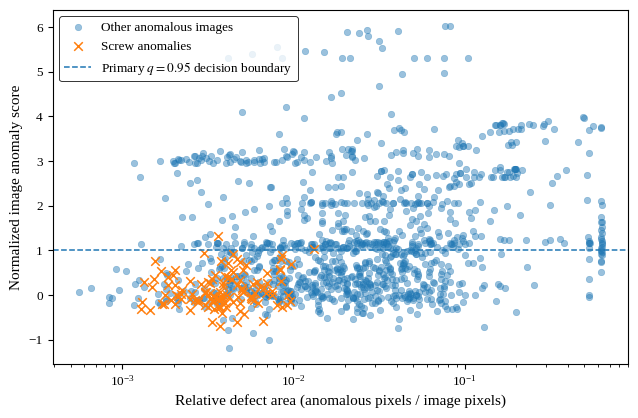


12B completed.
Zero-area masks are reported separately and are not used to define Tiny/Small/Medium/Large quartiles.

12C — INFERENCE LATENCY / THROUGHPUT / GPU MEMORY
GPU: NVIDIA A100-SXM4-80GB
CUDA runtime: 12.8
PyTorch: 2.11.0+cu128
Preprocessed benchmark images: 480


,seed,gpu,cuda_runtime,pytorch,measurement_scope,batch_size,warmup_batches,measured_passes,unique_preprocessed_images,timed_images_total,elapsed_seconds,latency_ms_per_image,throughput_images_per_second,peak_memory_allocated_mib,peak_memory_reserved_mib
0,2026,NVIDIA A100-SXM4-80GB,12.8,2.11.0+cu128,Preprocessed image tensor -> ViT blocks 6/9/12...,1,10,3,480,1440,16.290520,11.312861,88.394969,995.047852,1010.0
1,2026,NVIDIA A100-SXM4-80GB,12.8,2.11.0+cu128,Preprocessed image tensor -> ViT blocks 6/9/12...,32,10,3,480,1440,0.926553,0.643439,1554.147733,1188.128906,1206.0



FIGURE 6 — FINAL MANUSCRIPT VERSION

Preparing manuscript Figure 6: metal_nut


Extracting V5 global+multi-layer patch features:   0%|          | 0/4 [00:00<?, ?it/s]


Preparing manuscript Figure 6: grid


...


Figure 6 category-common scales:


,category,vmin_q01_raw_patch_distance,vmax_q99_raw_patch_distance,n_test_images_used_for_scale,n_raw_patch_values
0,metal_nut,0.048241,0.278409,115,22540
1,grid,0.115777,0.342226,78,15288
2,screw,0.052623,0.223038,160,31360
3,leather,0.085154,0.447832,124,24304



Figure 6 selected samples:


,category,defect_type,path,local_normalized_q095
0,metal_nut,bent,/root/.cache/kagglehub/datasets/ipythonx/mvtec...,3.397987
1,grid,thread,/root/.cache/kagglehub/datasets/ipythonx/mvtec...,3.682987
2,screw,manipulated_front,/root/.cache/kagglehub/datasets/ipythonx/mvtec...,1.314205
3,leather,glue,/root/.cache/kagglehub/datasets/ipythonx/mvtec...,3.270410


Saved PDF : /content/drive/MyDrive/MVTec_SimCLR_ViT_PATCH_PUBLICATION/v5p1_FINAL_FIXED_LOGSUMEXP_vit_base_patch16_224_pre0_industrial_preserving_v1_seed2026_5c952414f9/results/figures/reviewer_analyses/figure6_FINAL_category_common_scaling_seed2026.pdf
Saved SVG : /content/drive/MyDrive/MVTec_SimCLR_ViT_PATCH_PUBLICATION/v5p1_FINAL_FIXED_LOGSUMEXP_vit_base_patch16_224_pre0_industrial_preserving_v1_seed2026_5c952414f9/results/figures/reviewer_analyses/figure6_FINAL_category_common_scaling_seed2026.svg
Saved PNG : /content/drive/MyDrive/MVTec_SimCLR_ViT_PATCH_PUBLICATION/v5p1_FINAL_FIXED_LOGSUMEXP_vit_base_patch16_224_pre0_industrial_preserving_v1_seed2026_5c952414f9/results/figures/reviewer_analyses/figure6_FINAL_category_common_scaling_seed2026.png


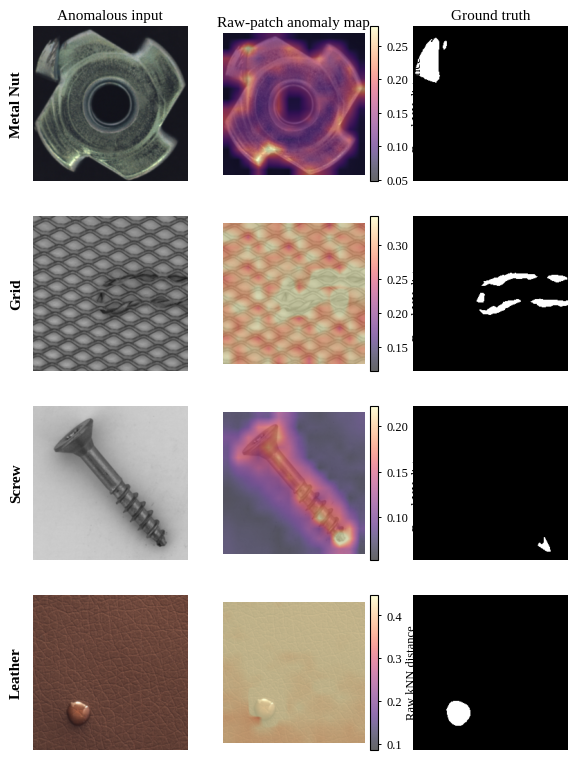


Figure 6 completed.
Outputs: PDF + SVG + 300-dpi PNG.
Localization map: RAW patch kNN distance.
Position calibration used for localization: NO.
Visualization scale: category-common q01/q99 from the complete official-test raw-patch score population of that category.
Displayed sample selection was not changed based on visual appearance.

11 — 2x2 RANDOM-vs-SimCLR / BLOCK12-vs-MULTILAYER ABLATION

--- Random_Block12 ---
   bottle
   cable
   capsule
   carpet
   grid
   hazelnut
   leather
   metal_nut
   pill
   screw
   tile
   toothbrush
   transistor
   wood
   zipper

--- Random_Blocks6_9_12 ---
   bottle
   cable
   capsule
   carpet
   grid
   hazelnut
   leather
   metal_nut
   pill
   screw
   tile
   toothbrush
   transistor
   wood
   zipper

--- SimCLR_Block12 ---
   bottle
   cable
   capsule
   carpet
   grid
   hazelnut
   leather
   metal_nut
   pill
   screw
   tile
   toothbrush
   transistor
   wood
   zipper

--- SimCLR_Blocks6_9_12 ---
   bottle
   cable
   capsule
 

,seed,variant,encoder,layers,balanced_accuracy,anomaly_precision,anomaly_recall,anomaly_f1,pooled_image_roc_auc,average_precision,mcc,macro_category_image_roc_auc,macro_category_anomaly_recall,macro_pixel_roc_auc,macro_pixel_average_precision,macro_aupro_0.30
0,2026,Random_Block12,Random ViT,12,0.587817,0.838828,0.364070,0.507761,0.631268,0.820865,0.167785,0.696923,0.429632,0.792717,0.206188,0.546050
1,2026,Random_Blocks6_9_12,Random ViT,6+9+12,0.583964,0.835185,0.358506,0.501669,0.632182,0.817383,0.160903,0.702600,0.420600,0.790919,0.208399,0.547648
2,2026,SimCLR_Block12,SimCLR ViT,12,0.648141,0.877013,0.476153,0.617208,0.707451,0.877530,0.269190,0.744994,0.499053,0.838554,0.228941,0.500702
3,2026,SimCLR_Blocks6_9_12,SimCLR ViT,6+9+12,0.667201,0.905573,0.465024,0.614496,0.722212,0.877275,0.307002,0.770223,0.510169,0.848286,0.270409,0.543148



ALL REVIEWER ANALYSES COMPLETED FOR SEED 2026
Output directory: /content/drive/MyDrive/MVTec_SimCLR_ViT_PATCH_PUBLICATION/v5p1_FINAL_FIXED_LOGSUMEXP_vit_base_patch16_224_pre0_industrial_preserving_v1_seed2026_5c952414f9/results/tables/reviewer_analyses
Figure directory: /content/drive/MyDrive/MVTec_SimCLR_ViT_PATCH_PUBLICATION/v5p1_FINAL_FIXED_LOGSUMEXP_vit_base_patch16_224_pre0_industrial_preserving_v1_seed2026_5c952414f9/results/figures/reviewer_analyses
Figure exports: PDF + SVG + 300-dpi PNG.
Figure typography: Times New Roman requested; Times-compatible serif fallback if unavailable.
No SSL retraining was performed.
q=.95 remains the primary configuration.
Do not select q or any 2x2 variant based on official-test performance.


In [9]:

# ============================================================
# 6A–6E. REVIEWER-REQUESTED ANALYSES
# Covers reviewer comments:
#   12A: q = 0.90 / 0.95 / 0.99 threshold sensitivity
#   12B: image detection versus relative defect area
#   12C: measured inference latency / throughput / peak GPU VRAM
#    7 : Figure 6 regenerated with category-common raw-score scaling
#   11 : 2x2 Random-vs-SimCLR / Block12-vs-Multilayer ablation
#
# IMPORTANT:
# - V5.1 primary method is NOT changed.
# - q=0.95 remains primary.
# - beta=4, k=3, M=1024 remain fixed.
# - No SSL retraining.
# - No official-test result is used for model/hyperparameter selection.
# ============================================================

import gc
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import roc_auc_score, average_precision_score

from IPython.display import display

# ============================================================
# MANUSCRIPT-COMPATIBLE FIGURE STYLE
# ============================================================

import matplotlib as mpl
from matplotlib import font_manager

# Full-width manuscript figure target.
MANUSCRIPT_FIG_WIDTH_IN = 6.30

# Use figure text close to the paper body size so it remains readable
# after insertion into the manuscript.
FIG_FONT_SIZE = 10.5
FIG_LABEL_SIZE = 11.0
FIG_TITLE_SIZE = 11.0
FIG_TICK_SIZE = 9.5
FIG_LEGEND_SIZE = 9.5
FIG_COLORBAR_SIZE = 9.0

_available_font_names = {f.name for f in font_manager.fontManager.ttflist}
if "Times New Roman" in _available_font_names:
    MANUSCRIPT_FONT_AVAILABLE = True
    print("Figure font: Times New Roman")
else:
    MANUSCRIPT_FONT_AVAILABLE = False
    print(
        "WARNING: Times New Roman is not installed in this runtime. "
        "The figures are configured to request Times New Roman first and "
        "will fall back to a Times-compatible serif font."
    )

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": [
        "Times New Roman",
        "Times",
        "Nimbus Roman",
        "Liberation Serif",
        "DejaVu Serif",
    ],
    "font.size": FIG_FONT_SIZE,
    "axes.titlesize": FIG_TITLE_SIZE,
    "axes.labelsize": FIG_LABEL_SIZE,
    "xtick.labelsize": FIG_TICK_SIZE,
    "ytick.labelsize": FIG_TICK_SIZE,
    "legend.fontsize": FIG_LEGEND_SIZE,
    "figure.titlesize": FIG_TITLE_SIZE,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.25,
    "lines.markersize": 5.0,
    "mathtext.fontset": "stix",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": False,
})

print("Manuscript figure style initialized.")


# ---------------- Safety checks ----------------
_REQUIRED_REVIEWER_OBJECTS = [
    "CFG", "DEVICE", "CATEGORIES", "TABLES_DIR", "FIGURES_DIR",
    "ssl_model", "ssl_train_df", "detector_calib_df", "official_test_df",
    "protocolA_validation_df", "protocolA_pred_df", "protocolA_metrics",
    "patch_prototype_banks", "validation_thresholds", "PathImageDataset",
    "eval_transform", "eval_geometry", "load_eval_mask", "autocast_context",
    "make_patch_projection", "fit_patch_position_calibrator",
    "PATCH_PROJECTION", "seed_everything", "patch_scores_to_maps",
    "score_patch_knn_raw", "extract_global_and_patch_features",
    "apply_patch_position_calibrator", "aggregate_patch_scores",
    "binary_metrics", "compute_aupro", "SimCLRv2ViT",
]
_missing = [x for x in _REQUIRED_REVIEWER_OBJECTS if x not in globals()]
if _missing:
    raise RuntimeError(
        "Reviewer-analysis section requires Protocol A (Cell 9) to be completed first.\n"
        "Missing: " + ", ".join(_missing)
    )

assert str(CFG.final_fixed_patch_aggregation) == "logsumexp_t4"
assert str(CFG.primary_detector) == "local_patch"
assert str(CFG.localization_map_mode) == "raw_patch_knn"
assert tuple(CFG.patch_layer_indices) == (5, 8, 11)
assert int(CFG.patch_projection_dim) == 256
assert int(CFG.patch_prototype_count) == 1024
assert int(CFG.patch_knn_k) == 3
assert np.isclose(float(CFG.threshold_quantile), 0.95)

REVIEWER_DIR = Path(TABLES_DIR) / "reviewer_analyses"
REVIEWER_FIG_DIR = Path(FIGURES_DIR) / "reviewer_analyses"
REVIEWER_DIR.mkdir(parents=True, exist_ok=True)
REVIEWER_FIG_DIR.mkdir(parents=True, exist_ok=True)

SEED_TAG = f"seed{int(CFG.seed)}"
PRIMARY_Q = 0.95


# ============================================================
# COMMON HELPERS
# ============================================================

def reviewer_fit_quantile_margin(normal_scores, q):
    """Same V5.1 quantile-margin logic, with q supplied locally."""
    scores = np.asarray(normal_scores, dtype=float).reshape(-1)
    if len(scores) == 0:
        raise ValueError("Empty calibration-normal score array.")
    if not np.all(np.isfinite(scores)):
        raise ValueError("Non-finite calibration-normal score found.")

    median = float(np.median(scores))
    threshold = float(np.quantile(scores, float(q)))
    scale = float(threshold - median)

    if not np.isfinite(scale) or scale < float(CFG.robust_scale_eps):
        scale = float(np.std(scores))
    if not np.isfinite(scale) or scale < float(CFG.robust_scale_eps):
        scale = 1.0

    return {
        "q": float(q),
        "median": median,
        "threshold": threshold,
        "scale": scale,
        "n": int(len(scores)),
    }


def reviewer_quantile_transform(scores, calibrator):
    return (
        np.asarray(scores, dtype=float) - float(calibrator["median"])
    ) / float(calibrator["scale"])


def reviewer_save_figure(fig, stem):
    """
    Save manuscript figures as vector PDF, editable SVG, and 300-dpi PNG.
    """
    pdf_path = REVIEWER_FIG_DIR / f"{stem}.pdf"
    svg_path = REVIEWER_FIG_DIR / f"{stem}.svg"
    png_path = REVIEWER_FIG_DIR / f"{stem}.png"

    save_kwargs = {
        "bbox_inches": "tight",
        "pad_inches": 0.03,
        "facecolor": "white",
    }

    fig.savefig(pdf_path, format="pdf", **save_kwargs)
    fig.savefig(svg_path, format="svg", **save_kwargs)
    fig.savefig(png_path, format="png", dpi=300, **save_kwargs)

    print("Saved PDF :", pdf_path)
    print("Saved SVG :", svg_path)
    print("Saved PNG :", png_path)

    return {
        "pdf": str(pdf_path),
        "svg": str(svg_path),
        "png": str(png_path),
    }


# ============================================================
# 12A. THRESHOLD SENSITIVITY
# ============================================================

print("\n" + "=" * 90)
print("12A — THRESHOLD SENSITIVITY")
print("=" * 90)

REVIEWER_Q_VALUES = (0.90, 0.95, 0.99)

q_overall_rows = []
q_category_rows = []
q_threshold_rows = []
q_prediction_frames = []

for q in REVIEWER_Q_VALUES:
    q_parts = []

    for category in sorted(CATEGORIES):
        cal = protocolA_validation_df[
            protocolA_validation_df["category"] == category
        ].copy()
        tst = protocolA_pred_df[
            protocolA_pred_df["category"] == category
        ].copy()

        calibrator = reviewer_fit_quantile_margin(
            cal["local_score"].to_numpy(dtype=float), q
        )

        norm = reviewer_quantile_transform(
            tst["local_score"].to_numpy(dtype=float), calibrator
        )
        pred = (norm > 1.0).astype(int)

        q_threshold_rows.append({
            "seed": int(CFG.seed),
            "q": float(q),
            "is_primary_q": bool(np.isclose(q, PRIMARY_Q)),
            "category": category,
            "n_calibration_normals": int(len(cal)),
            "median": float(calibrator["median"]),
            "q_threshold": float(calibrator["threshold"]),
            "scale": float(calibrator["scale"]),
        })

        tst["reviewer_q"] = float(q)
        tst["reviewer_local_normalized"] = norm
        tst["reviewer_prediction"] = pred
        q_parts.append(tst)

        y_cat = tst["binary_label"].to_numpy(dtype=int)
        m_cat = binary_metrics(y_cat, pred, norm)
        q_category_rows.append({
            "seed": int(CFG.seed),
            "q": float(q),
            "category": category,
            "n_test": int(len(tst)),
            "balanced_accuracy": float(m_cat["balanced_accuracy"]),
            "anomaly_precision": float(m_cat["anomaly_precision"]),
            "anomaly_recall": float(m_cat["anomaly_recall"]),
            "anomaly_f1": float(m_cat["anomaly_f1"]),
            "test_normal_fpr": float(m_cat["false_positive_rate"]),
            "TN": int(m_cat["TN"]),
            "FP": int(m_cat["FP"]),
            "FN": int(m_cat["FN"]),
            "TP": int(m_cat["TP"]),
        })

    q_df = pd.concat(q_parts, ignore_index=True)
    q_prediction_frames.append(q_df)

    y = q_df["binary_label"].to_numpy(dtype=int)
    yp = q_df["reviewer_prediction"].to_numpy(dtype=int)
    ys = q_df["reviewer_local_normalized"].to_numpy(dtype=float)
    m = binary_metrics(y, yp, ys)

    normal_mask = (y == 0)
    normal_fpr = float(((yp == 1) & normal_mask).sum() / normal_mask.sum())

    q_overall_rows.append({
        "seed": int(CFG.seed),
        "q": float(q),
        "is_primary_q": bool(np.isclose(q, PRIMARY_Q)),
        "balanced_accuracy": float(m["balanced_accuracy"]),
        "anomaly_precision": float(m["anomaly_precision"]),
        "anomaly_recall": float(m["anomaly_recall"]),
        "anomaly_f1": float(m["anomaly_f1"]),
        "test_normal_fpr": normal_fpr,
        "TN": int(m["TN"]),
        "FP": int(m["FP"]),
        "FN": int(m["FN"]),
        "TP": int(m["TP"]),
    })

reviewer_q_overall_df = pd.DataFrame(q_overall_rows)
reviewer_q_per_category_df = pd.DataFrame(q_category_rows)
reviewer_q_thresholds_df = pd.DataFrame(q_threshold_rows)
reviewer_q_predictions_df = pd.concat(q_prediction_frames, ignore_index=True)

# q=.95 must reproduce original fixed result exactly (within numeric tolerance).
q95 = reviewer_q_predictions_df[
    np.isclose(reviewer_q_predictions_df["reviewer_q"], PRIMARY_Q)
][["path", "category", "reviewer_local_normalized", "reviewer_prediction"]]

orig = protocolA_pred_df[
    ["path", "category", "local_normalized", "local_prediction"]
]

chk = orig.merge(q95, on=["path", "category"], how="inner", validate="one_to_one")
assert len(chk) == len(protocolA_pred_df)

pred_ok = np.array_equal(
    chk["local_prediction"].to_numpy(dtype=int),
    chk["reviewer_prediction"].to_numpy(dtype=int),
)
score_ok = np.allclose(
    chk["local_normalized"].to_numpy(dtype=float),
    chk["reviewer_local_normalized"].to_numpy(dtype=float),
    rtol=1e-10, atol=1e-10,
)
max_score_diff = float(np.max(np.abs(
    chk["local_normalized"].to_numpy(dtype=float)
    - chk["reviewer_local_normalized"].to_numpy(dtype=float)
)))

print("q=.95 predictions identical:", pred_ok)
print("q=.95 scores identical:", score_ok)
print("q=.95 max score difference:", max_score_diff)

if not (pred_ok and score_ok):
    raise AssertionError(
        "q=.95 did not reproduce the original primary detector. "
        "STOP before interpreting reviewer sensitivity results."
    )

reviewer_q_overall_df.to_csv(
    REVIEWER_DIR / f"reviewer_q_sensitivity_overall_{SEED_TAG}.csv", index=False
)
reviewer_q_per_category_df.to_csv(
    REVIEWER_DIR / f"reviewer_q_sensitivity_by_category_{SEED_TAG}.csv", index=False
)
reviewer_q_thresholds_df.to_csv(
    REVIEWER_DIR / f"reviewer_q_sensitivity_thresholds_{SEED_TAG}.csv", index=False
)
reviewer_q_predictions_df.to_csv(
    REVIEWER_DIR / f"reviewer_q_sensitivity_predictions_{SEED_TAG}.csv", index=False
)

q_show = reviewer_q_overall_df.copy()
for c in [
    "balanced_accuracy", "anomaly_precision", "anomaly_recall",
    "anomaly_f1", "test_normal_fpr"
]:
    q_show[c] *= 100.0
display(q_show.round(3))


# ============================================================
# 12B. IMAGE DETECTION VERSUS DEFECT AREA — CORRECTED
# ============================================================

print("\n" + "=" * 90)
print("12B — IMAGE DETECTION VERSUS DEFECT AREA")
print("=" * 90)

area_rows = []

for _, row in protocolA_pred_df.iterrows():
    if int(row["binary_label"]) != 1:
        continue

    mask_path_str = str(row.get("mask_path", "")).strip()
    if not mask_path_str:
        raise RuntimeError(f"Anomalous image has no mask_path:\n{row['path']}")

    mask_path = Path(mask_path_str)
    if not mask_path.is_file():
        raise RuntimeError(
            "Ground-truth mask file does not exist:\n"
            f"Image: {row['path']}\nMask : {mask_path}"
        )

    with Image.open(mask_path) as original_mask_img:
        original_mask_arr = np.asarray(
            original_mask_img.convert("L"),
            dtype=np.uint8,
        )

    original_defect_pixels = int((original_mask_arr > 0).sum())
    if original_defect_pixels <= 0:
        raise RuntimeError(
            "Original GT mask is empty for anomalous image:\n"
            f"Image: {row['path']}\nMask : {mask_path}"
        )

    # Exact fixed 224x224 evaluation geometry used by the primary method.
    processed_mask = load_eval_mask(row)
    processed_defect_pixels = int(processed_mask.sum())
    total_pixels = int(processed_mask.size)
    area_fraction = float(processed_defect_pixels / total_pixels)
    zero_after_preprocessing = bool(processed_defect_pixels == 0)

    area_rows.append({
        "seed": int(CFG.seed),
        "path": str(row["path"]),
        "category": str(row["category"]),
        "defect_type": str(row["defect_type"]),
        "mask_path": str(mask_path),
        "original_defect_pixels": original_defect_pixels,
        "processed_defect_pixels": processed_defect_pixels,
        "total_pixels": total_pixels,
        "relative_defect_area": area_fraction,
        "zero_area_after_preprocessing": zero_after_preprocessing,
        "local_score": float(row["local_score"]),
        "local_normalized_q095": float(row["local_normalized"]),
        "detected_q095": int(row["local_prediction"]),
    })

reviewer_area_df = pd.DataFrame(area_rows)
if reviewer_area_df.empty:
    raise RuntimeError("No anomalous official-test images found for defect-area analysis.")

zero_area_df = reviewer_area_df[
    reviewer_area_df["zero_area_after_preprocessing"]
].copy()
positive_area_df = reviewer_area_df[
    reviewer_area_df["relative_defect_area"] > 0
].copy()

print("\nDefect-area audit")
print("-----------------")
print("Total anomalous images:", len(reviewer_area_df))
print("Positive-area anomalies after preprocessing:", len(positive_area_df))
print("Zero-area anomalies after preprocessing:", len(zero_area_df))

if not zero_area_df.empty:
    print("\nZero-area cases after evaluation preprocessing:")
    display(
        zero_area_df[
            [
                "category", "defect_type", "path", "mask_path",
                "original_defect_pixels", "processed_defect_pixels",
            ]
        ]
    )

if len(positive_area_df) < 4:
    raise RuntimeError("Too few positive-area anomalous images for quartile analysis.")

positive_areas = positive_area_df["relative_defect_area"].to_numpy(dtype=float)
q1, q2, q3 = np.quantile(positive_areas, [0.25, 0.50, 0.75])

if not (q1 < q2 < q3):
    raise RuntimeError(
        "Defect-area quartile boundaries are not strictly increasing: "
        f"{q1}, {q2}, {q3}"
    )

AREA_LABELS = ["Tiny", "Small", "Medium", "Large"]
reviewer_area_df["area_bin"] = "Zero_after_preprocessing"

positive_bins = pd.cut(
    positive_area_df["relative_defect_area"],
    bins=[-np.inf, q1, q2, q3, np.inf],
    labels=AREA_LABELS,
    include_lowest=True,
    right=True,
)

reviewer_area_df.loc[
    positive_area_df.index,
    "area_bin",
] = positive_bins.astype(str)

area_boundaries = {
    "seed": int(CFG.seed),
    "definition": (
        "relative defect area = positive GT-mask pixels / "
        "224x224 evaluation pixels"
    ),
    "binning_rule": (
        "Tiny/Small/Medium/Large quartiles are computed only from "
        "anomalous images with positive visible GT-mask area after "
        "the fixed evaluation preprocessing."
    ),
    "zero_area_rule": (
        "Anomalous images whose valid original GT mask becomes empty "
        "after evaluation preprocessing are retained as "
        "'Zero_after_preprocessing' and excluded from quartile "
        "boundary estimation and size-stratified metrics."
    ),
    "q25": float(q1),
    "q50": float(q2),
    "q75": float(q3),
    "n_anomalous_images_total": int(len(reviewer_area_df)),
    "n_positive_area_anomalies": int(len(positive_area_df)),
    "n_zero_area_after_preprocessing": int(len(zero_area_df)),
}

with open(
    REVIEWER_DIR / f"reviewer_defect_area_boundaries_{SEED_TAG}.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(area_boundaries, f, indent=2)

normal_test = protocolA_pred_df[
    protocolA_pred_df["binary_label"] == 0
].copy()

area_summary_rows = []

for label in AREA_LABELS:
    pos = reviewer_area_df[
        reviewer_area_df["area_bin"] == label
    ].copy()

    if pos.empty:
        continue

    y_bin = np.concatenate([
        np.ones(len(pos), dtype=int),
        np.zeros(len(normal_test), dtype=int),
    ])
    s_bin = np.concatenate([
        pos["local_normalized_q095"].to_numpy(dtype=float),
        normal_test["local_normalized"].to_numpy(dtype=float),
    ])
    bin_auc = float(roc_auc_score(y_bin, s_bin))

    area_summary_rows.append({
        "seed": int(CFG.seed),
        "area_bin": label,
        "n_anomalous_images": int(len(pos)),
        "min_relative_area": float(pos["relative_defect_area"].min()),
        "median_relative_area": float(pos["relative_defect_area"].median()),
        "max_relative_area": float(pos["relative_defect_area"].max()),
        "median_image_score_q095": float(pos["local_normalized_q095"].median()),
        "mean_image_score_q095": float(pos["local_normalized_q095"].mean()),
        "anomaly_recall_q095": float(pos["detected_q095"].mean()),
        "image_roc_auc_vs_same_test_normals": bin_auc,
    })

reviewer_area_summary_df = pd.DataFrame(area_summary_rows)

# Screw-specific supporting analysis; the bin boundaries remain dataset-wide.
screw_area_df = reviewer_area_df[
    (reviewer_area_df["category"] == "screw")
    & (reviewer_area_df["relative_defect_area"] > 0)
].copy()

screw_area_summary_rows = []
for label in AREA_LABELS:
    screw_bin = screw_area_df[screw_area_df["area_bin"] == label]
    if screw_bin.empty:
        continue

    screw_area_summary_rows.append({
        "seed": int(CFG.seed),
        "area_bin": label,
        "n_screw_anomalies": int(len(screw_bin)),
        "median_relative_area": float(screw_bin["relative_defect_area"].median()),
        "median_image_score_q095": float(
            screw_bin["local_normalized_q095"].median()
        ),
        "anomaly_recall_q095": float(screw_bin["detected_q095"].mean()),
    })

reviewer_screw_area_summary_df = pd.DataFrame(screw_area_summary_rows)

reviewer_area_df.to_csv(
    REVIEWER_DIR / f"reviewer_defect_area_per_image_{SEED_TAG}.csv",
    index=False,
)
reviewer_area_summary_df.to_csv(
    REVIEWER_DIR / f"reviewer_defect_area_summary_{SEED_TAG}.csv",
    index=False,
)
zero_area_df.to_csv(
    REVIEWER_DIR / f"reviewer_defect_area_zero_after_preprocessing_{SEED_TAG}.csv",
    index=False,
)
reviewer_screw_area_summary_df.to_csv(
    REVIEWER_DIR / f"reviewer_screw_defect_area_summary_{SEED_TAG}.csv",
    index=False,
)

print("\nDefect-area bin boundaries:")
print(f"Q25 = {q1:.8f}")
print(f"Q50 = {q2:.8f}")
print(f"Q75 = {q3:.8f}")

print("\nDefect-area summary:")
display(reviewer_area_summary_df.round(6))

print("\nScrew defect-area summary:")
display(reviewer_screw_area_summary_df.round(6))

# ============================================================
# 12B FIGURE — MANUSCRIPT-READY
# ============================================================

other = positive_area_df[
    positive_area_df["category"] != "screw"
].copy()
screw = positive_area_df[
    positive_area_df["category"] == "screw"
].copy()

fig, ax = plt.subplots(
    figsize=(MANUSCRIPT_FIG_WIDTH_IN, 4.10)
)

ax.scatter(
    other["relative_defect_area"],
    other["local_normalized_q095"],
    s=22,
    alpha=0.45,
    marker="o",
    linewidths=0.4,
    label="Other anomalous images",
)

ax.scatter(
    screw["relative_defect_area"],
    screw["local_normalized_q095"],
    s=38,
    marker="x",
    linewidths=1.1,
    label="Screw anomalies",
)

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1.1,
    label=r"Primary $q=0.95$ decision boundary",
)

ax.set_xscale("log")
ax.set_xlabel(
    "Relative defect area (anomalous pixels / image pixels)",
    fontsize=FIG_LABEL_SIZE,
)
ax.set_ylabel(
    "Normalized image anomaly score",
    fontsize=FIG_LABEL_SIZE,
)
ax.tick_params(axis="both", which="major", labelsize=FIG_TICK_SIZE)
ax.tick_params(axis="both", which="minor", labelsize=FIG_TICK_SIZE)
ax.grid(False)

legend = ax.legend(
    loc="best",
    fontsize=FIG_LEGEND_SIZE,
    frameon=True,
    edgecolor="black",
)
legend.get_frame().set_linewidth(0.7)

for spine in ax.spines.values():
    spine.set_linewidth(0.8)

fig.tight_layout(pad=0.4)

reviewer_save_figure(
    fig,
    f"reviewer_defect_area_vs_image_score_{SEED_TAG}",
)
plt.show()

print("\n12B completed.")
print(
    "Zero-area masks are reported separately and are not used "
    "to define Tiny/Small/Medium/Large quartiles."
)


# ============================================================
# 12C. INFERENCE LATENCY / THROUGHPUT / VRAM
# ============================================================

print("\n" + "=" * 90)
print("12C — INFERENCE LATENCY / THROUGHPUT / GPU MEMORY")
print("=" * 90)

if DEVICE.type != "cuda":
    raise RuntimeError("Reviewer runtime benchmark must be executed on CUDA/A100.")

print("GPU:", torch.cuda.get_device_name(0))
print("CUDA runtime:", torch.version.cuda)
print("PyTorch:", torch.__version__)

# Preload a deterministic balanced subset so disk I/O and PIL preprocessing
# are excluded from the timed region.
BENCH_IMAGES_PER_CATEGORY = 32
bench_cache = {}

for category in sorted(CATEGORIES):
    cat_df = (
        official_test_df[official_test_df["category"] == category]
        .sort_values("path")
        .head(BENCH_IMAGES_PER_CATEGORY)
        .reset_index(drop=True)
    )
    ds = PathImageDataset(cat_df, eval_transform)
    tensors = [ds[i][0] for i in range(len(ds))]
    if tensors:
        bench_cache[category] = torch.stack(tensors, dim=0)

benchmark_image_count = int(sum(len(x) for x in bench_cache.values()))
print("Preprocessed benchmark images:", benchmark_image_count)

projection_gpu = PATCH_PROJECTION.to(DEVICE)

@torch.no_grad()
def reviewer_primary_detector_tensor_batch(images_cpu, category):
    """Current V5.1 primary local detector, excluding disk/PIL preprocessing."""
    images = images_cpu.to(DEVICE, non_blocking=True)

    with autocast_context():
        _, layers = ssl_model.encode_global_and_multilayer_patches(
            images, CFG.patch_layer_indices
        )

    layers = [F.normalize(x.float(), dim=2) for x in layers]
    patches = torch.cat(layers, dim=2)
    patches = F.normalize(patches @ projection_gpu, dim=2).cpu()

    raw_patch = score_patch_knn_raw(
        patches,
        patch_prototype_banks[category],
        spatial_penalty=0.0,
    )

    params = validation_thresholds[category]
    patch_z = apply_patch_position_calibrator(
        raw_patch, params["position_calibrator"]
    )
    image_raw = aggregate_patch_scores(
        patch_z, "logsumexp_t4"
    )
    image_norm = reviewer_quantile_transform(
        image_raw, params["local_image_calibrator"]
    )
    return image_norm


def run_runtime_benchmark(batch_size, warmup_batches=10, measured_passes=3):
    # Warm-up on the first available category.
    first_cat = next(iter(sorted(bench_cache)))
    first_tensor = bench_cache[first_cat]
    warm_tensor = first_tensor[:min(batch_size, len(first_tensor))]

    for _ in range(warmup_batches):
        reviewer_primary_detector_tensor_batch(warm_tensor, first_cat)

    torch.cuda.synchronize()
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

    total_images = 0
    t0 = time.perf_counter()

    for _ in range(measured_passes):
        for category in sorted(bench_cache):
            x = bench_cache[category]
            for start in range(0, len(x), batch_size):
                xb = x[start:start + batch_size]
                reviewer_primary_detector_tensor_batch(xb, category)
                total_images += int(len(xb))

    torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0

    return {
        "seed": int(CFG.seed),
        "gpu": torch.cuda.get_device_name(0),
        "cuda_runtime": str(torch.version.cuda),
        "pytorch": str(torch.__version__),
        "measurement_scope": (
            "Preprocessed image tensor -> ViT blocks 6/9/12 -> 2304-to-256 "
            "projection -> kNN prototypes -> position calibration -> "
            "log-mean-exp beta=4 -> q=.95 image calibration; disk/PIL excluded"
        ),
        "batch_size": int(batch_size),
        "warmup_batches": int(warmup_batches),
        "measured_passes": int(measured_passes),
        "unique_preprocessed_images": int(benchmark_image_count),
        "timed_images_total": int(total_images),
        "elapsed_seconds": float(elapsed),
        "latency_ms_per_image": float(1000.0 * elapsed / total_images),
        "throughput_images_per_second": float(total_images / elapsed),
        "peak_memory_allocated_mib": float(torch.cuda.max_memory_allocated() / 1024**2),
        "peak_memory_reserved_mib": float(torch.cuda.max_memory_reserved() / 1024**2),
    }

runtime_rows = [
    run_runtime_benchmark(batch_size=1),
    run_runtime_benchmark(batch_size=int(CFG.eval_batch_size)),
]

reviewer_runtime_df = pd.DataFrame(runtime_rows)
reviewer_runtime_df.to_csv(
    REVIEWER_DIR / f"reviewer_runtime_benchmark_{SEED_TAG}.csv", index=False
)
display(reviewer_runtime_df)


# ============================================================
# REVIEWER COMMENT 7 — FINAL MANUSCRIPT FIGURE 6
#
# Reviewer requirements:
# - enlarge qualitative visualization
# - common heatmap normalization within each category
# - do not independently autoscale displayed images
#
# Methodological safeguards:
# - RAW patch kNN distances only for localization
# - no position calibration for localization
# - no image-score calibration for localization
# - category-common limits from ALL official-test raw patch
#   scores in that category (1st/99th percentiles)
# - original anomalous-example selection rule preserved
#
# Output:
# - PDF vector
# - editable SVG
# - 300-dpi PNG
# - Times New Roman requested, Times-compatible serif fallback
# ============================================================

print("\n" + "=" * 90)
print("FIGURE 6 — FINAL MANUSCRIPT VERSION")
print("=" * 90)

# Preserve original Figure-6 category order.
FIG6_CATEGORIES = [
    c
    for c in ["metal_nut", "grid", "screw", "leather"]
    if c in CATEGORIES
]

fig6_scale_rows = []
fig6_selection_rows = []
fig6_payload = {}


def load_display_image(path):
    with Image.open(path) as im:
        im = im.convert("RGB")
        im = eval_geometry(im)
        return np.asarray(im)


for category in FIG6_CATEGORIES:
    print(f"\nPreparing manuscript Figure 6: {category}")

    cat_df = (
        official_test_df[
            official_test_df["category"] == category
        ]
        .reset_index(drop=True)
    )

    if cat_df.empty:
        raise RuntimeError(
            f"No official-test samples found for category: {category}"
        )

    # Frozen primary SimCLR multilayer features.
    _, cat_patches = extract_global_and_patch_features(cat_df)

    # RAW patch kNN distances: fixed localization branch.
    # Position calibration is intentionally NOT applied.
    raw_patch_all = score_patch_knn_raw(
        cat_patches,
        patch_prototype_banks[category],
        spatial_penalty=0.0,
    )

    raw_values = (
        raw_patch_all
        .detach()
        .cpu()
        .numpy()
        .reshape(-1)
        .astype(float)
    )

    if raw_values.size == 0:
        raise RuntimeError(
            f"No raw patch scores for category: {category}"
        )
    if not np.all(np.isfinite(raw_values)):
        raise RuntimeError(
            f"Non-finite raw patch scores for category: {category}"
        )

    # Common category-level scale from the COMPLETE official-test
    # raw patch-score population.
    vmin_c = float(np.quantile(raw_values, 0.01))
    vmax_c = float(np.quantile(raw_values, 0.99))

    if not (
        np.isfinite(vmin_c)
        and np.isfinite(vmax_c)
        and vmax_c > vmin_c
    ):
        raise RuntimeError(
            f"Invalid Figure-6 range for {category}: "
            f"{vmin_c}, {vmax_c}"
        )

    maps_all = patch_scores_to_maps(raw_patch_all)

    fig6_scale_rows.append({
        "seed": int(CFG.seed),
        "category": category,
        "scaling_source": (
            "complete official-test category raw patch kNN score population"
        ),
        "low_quantile": 0.01,
        "high_quantile": 0.99,
        "vmin_q01_raw_patch_distance": vmin_c,
        "vmax_q99_raw_patch_distance": vmax_c,
        "n_test_images_used_for_scale": int(len(cat_df)),
        "patches_per_image": int(raw_patch_all.shape[1]),
        "n_raw_patch_values": int(raw_values.size),
        "localization_uses_position_calibration": False,
    })

    pred_cat = protocolA_pred_df[
        protocolA_pred_df["category"] == category
    ].copy()

    anomaly_candidates = pred_cat[
        pred_cat["binary_label"] == 1
    ].copy()

    if anomaly_candidates.empty:
        raise RuntimeError(
            f"No anomalous sample for category: {category}"
        )

    # Preserve the original notebook selection rule exactly:
    # highest fixed q=.95 local image anomaly score.
    selected = (
        anomaly_candidates
        .sort_values(
            "local_normalized",
            ascending=False,
        )
        .iloc[0]
    )

    selected_path = str(selected["path"])
    path_array = cat_df["path"].astype(str).to_numpy()
    matches = np.flatnonzero(path_array == selected_path)

    if len(matches) != 1:
        raise RuntimeError(
            "Could not uniquely find selected Figure-6 sample.\n"
            f"Category: {category}\n"
            f"Path: {selected_path}"
        )

    selected_index = int(matches[0])
    selected_row = cat_df.iloc[selected_index]

    image_rgb = load_display_image(selected_path)
    raw_map = maps_all[selected_index]
    gt_mask = load_eval_mask(selected_row)

    fig6_payload[category] = {
        "image": image_rgb,
        "raw_map": raw_map,
        "ground_truth": gt_mask,
        "vmin": vmin_c,
        "vmax": vmax_c,
        "path": selected_path,
        "defect_type": str(selected["defect_type"]),
        "local_normalized": float(selected["local_normalized"]),
    }

    fig6_selection_rows.append({
        "seed": int(CFG.seed),
        "category": category,
        "selection_rule": (
            "highest fixed-q=.95 local_normalized score among "
            "true anomalous official-test images"
        ),
        "path": selected_path,
        "defect_type": str(selected["defect_type"]),
        "local_normalized_q095": float(selected["local_normalized"]),
        "vmin_category_q01": vmin_c,
        "vmax_category_q99": vmax_c,
        "raw_localization_map": True,
        "position_calibration_used": False,
    })

fig6_scale_df = pd.DataFrame(fig6_scale_rows)
fig6_selection_df = pd.DataFrame(fig6_selection_rows)

fig6_scale_df.to_csv(
    REVIEWER_DIR / f"figure6_category_common_scales_{SEED_TAG}.csv",
    index=False,
)
fig6_selection_df.to_csv(
    REVIEWER_DIR / f"figure6_selected_samples_{SEED_TAG}.csv",
    index=False,
)

print("\nFigure 6 category-common scales:")
display(
    fig6_scale_df[
        [
            "category",
            "vmin_q01_raw_patch_distance",
            "vmax_q99_raw_patch_distance",
            "n_test_images_used_for_scale",
            "n_raw_patch_values",
        ]
    ].round(6)
)

print("\nFigure 6 selected samples:")
display(
    fig6_selection_df[
        [
            "category",
            "defect_type",
            "path",
            "local_normalized_q095",
        ]
    ]
)

# ============================================================
# FINAL FIGURE 6 — 4 rows x 3 columns
#
# Anomalous input | raw-distance overlay | GT mask
# ============================================================

n_rows = len(FIG6_CATEGORIES)

fig, axes = plt.subplots(
    n_rows,
    3,
    figsize=(MANUSCRIPT_FIG_WIDTH_IN, 7.85),
)

if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

column_titles = [
    "Anomalous input",
    "Raw-patch anomaly map",
    "Ground truth",
]

for col_idx, title in enumerate(column_titles):
    axes[0, col_idx].set_title(
        title,
        fontsize=FIG_TITLE_SIZE,
        fontweight="normal",
        pad=5,
    )

for row_idx, category in enumerate(FIG6_CATEGORIES):
    payload = fig6_payload[category]

    image_rgb = payload["image"]
    anomaly_map = payload["raw_map"]
    gt_mask = payload["ground_truth"]
    vmin_c = payload["vmin"]
    vmax_c = payload["vmax"]

    axes[row_idx, 0].imshow(image_rgb)

    # Overlay raw patch kNN distance on the same anomalous input.
    axes[row_idx, 1].imshow(image_rgb)
    heat = axes[row_idx, 1].imshow(
        anomaly_map,
        cmap="magma",
        alpha=0.60,
        vmin=vmin_c,
        vmax=vmax_c,
    )

    axes[row_idx, 2].imshow(
        gt_mask,
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    axes[row_idx, 0].set_ylabel(
        category.replace("_", " ").title(),
        fontsize=FIG_LABEL_SIZE,
        fontweight="bold",
        rotation=90,
        labelpad=7,
    )

    colorbar = fig.colorbar(
        heat,
        ax=axes[row_idx, 1],
        fraction=0.050,
        pad=0.035,
    )
    colorbar.set_label(
        "Raw kNN distance",
        fontsize=FIG_COLORBAR_SIZE,
        labelpad=3,
    )
    colorbar.ax.tick_params(
        labelsize=FIG_COLORBAR_SIZE,
        width=0.7,
        length=2.5,
    )

    for col_idx in range(3):
        ax = axes[row_idx, col_idx]
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

# No large internal title; the manuscript caption carries the explanation.
fig.subplots_adjust(
    left=0.105,
    right=0.955,
    top=0.965,
    bottom=0.025,
    wspace=0.23,
    hspace=0.12,
)

figure6_paths = reviewer_save_figure(
    fig,
    f"figure6_FINAL_category_common_scaling_{SEED_TAG}",
)
plt.show()

print("\nFigure 6 completed.")
print("Outputs: PDF + SVG + 300-dpi PNG.")
print("Localization map: RAW patch kNN distance.")
print("Position calibration used for localization: NO.")
print(
    "Visualization scale: category-common q01/q99 from the complete "
    "official-test raw-patch score population of that category."
)
print(
    "Displayed sample selection was not changed based on visual appearance."
)


# ============================================================
# 11. 2x2 REPRESENTATION ABLATION
# Random vs SimCLR x Block12 vs Blocks6+9+12
# ============================================================

print("\n" + "=" * 90)
print("11 — 2x2 RANDOM-vs-SimCLR / BLOCK12-vs-MULTILAYER ABLATION")
print("=" * 90)

# Generic reviewer-only extraction; does NOT mutate CFG.patch_layer_indices.
@torch.no_grad()
def reviewer_extract_patch_features(
    model,
    dataframe,
    layer_indices,
    projection_cpu,
    batch_size=None,
):
    model.eval()
    loader = DataLoader(
        PathImageDataset(dataframe, eval_transform),
        batch_size=batch_size or int(CFG.eval_batch_size),
        shuffle=False,
        num_workers=int(CFG.eval_num_workers),
        pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=False,
    )

    projection = projection_cpu.to(DEVICE)
    batches = []

    for images, _ in loader:
        images = images.to(DEVICE, non_blocking=True)

        with autocast_context():
            _, patch_layers = model.encode_global_and_multilayer_patches(
                images, layer_indices
            )

        patch_layers = [
            F.normalize(layer.float(), dim=2)
            for layer in patch_layers
        ]
        patches = torch.cat(patch_layers, dim=2)
        patches = F.normalize(patches @ projection, dim=2)
        batches.append(patches.cpu())

    return torch.cat(batches, dim=0)


def reviewer_build_prototype_bank(train_patch_features, category):
    """Same M=1024 MiniBatchKMeans construction, no cross-variant cache reuse."""
    n_images, n_patches, dim = train_patch_features.shape
    flat = train_patch_features.reshape(-1, dim).float()

    if len(flat) > int(CFG.patch_candidate_max_per_category):
        g = torch.Generator(device="cpu")
        g.manual_seed(int(CFG.seed) + sum(ord(ch) for ch in category))
        indices = torch.randperm(len(flat), generator=g)[
            :int(CFG.patch_candidate_max_per_category)
        ]
        flat = flat[indices]

    n_clusters = min(int(CFG.patch_prototype_count), len(flat))

    if n_clusters < 2:
        prototypes = F.normalize(flat.clone(), dim=1)
    else:
        kmeans = MiniBatchKMeans(
            n_clusters=n_clusters,
            random_state=int(CFG.seed),
            batch_size=min(int(CFG.patch_kmeans_batch_size), len(flat)),
            max_iter=int(CFG.patch_kmeans_max_iter),
            n_init=1,
            reassignment_ratio=0.01,
        )
        kmeans.fit(flat.numpy())
        prototypes = torch.tensor(
            kmeans.cluster_centers_,
            dtype=torch.float32,
        )
        prototypes = F.normalize(prototypes, dim=1)

    return {"prototypes": prototypes}


@torch.no_grad()
def reviewer_score_raw_patch_knn(patch_features, prototype_bank):
    prototypes = prototype_bank["prototypes"].to(DEVICE)
    outputs = []

    for start in range(0, len(patch_features), int(CFG.eval_batch_size)):
        batch = patch_features[
            start:start + int(CFG.eval_batch_size)
        ].to(DEVICE)

        b = batch.shape[0]
        flat = batch.reshape(-1, batch.shape[-1])

        distances = torch.cdist(
            flat.float(),
            prototypes.float(),
            p=2,
        )

        k = min(int(CFG.patch_knn_k), prototypes.shape[0])
        nearest = torch.topk(
            distances, k=k, largest=False, dim=1
        ).values.mean(dim=1)

        outputs.append(nearest.reshape(b, -1).cpu())

    return torch.cat(outputs, dim=0)


def reviewer_maps_from_patch_scores(patch_scores):
    h, w = ssl_model.patch_grid
    maps = patch_scores.reshape(-1, 1, h, w).float()
    maps = F.interpolate(
        maps,
        size=(int(CFG.image_size), int(CFG.image_size)),
        mode="bilinear",
        align_corners=False,
    )
    return maps[:, 0].numpy()


def reviewer_evaluate_2x2_variant(
    variant_name,
    encoder_kind,
    model,
    layer_indices,
    projection_cpu,
):
    print("\n---", variant_name, "---")

    all_image_rows = []
    per_category_rows = []

    for category in sorted(CATEGORIES):
        print("  ", category)

        train_cat = (
            ssl_train_df[ssl_train_df["category"] == category]
            .reset_index(drop=True)
        )
        calib_cat = (
            detector_calib_df[detector_calib_df["category"] == category]
            .reset_index(drop=True)
        )
        test_cat = (
            official_test_df[official_test_df["category"] == category]
            .reset_index(drop=True)
        )

        # Normal-only memory construction.
        train_patch = reviewer_extract_patch_features(
            model, train_cat, layer_indices, projection_cpu
        )
        bank = reviewer_build_prototype_bank(train_patch, category)

        # Normal-only calibration.
        calib_patch = reviewer_extract_patch_features(
            model, calib_cat, layer_indices, projection_cpu
        )
        calib_raw_patch = reviewer_score_raw_patch_knn(
            calib_patch, bank
        )
        position_cal = fit_patch_position_calibrator(
            calib_raw_patch
        )
        calib_z = apply_patch_position_calibrator(
            calib_raw_patch, position_cal
        )
        calib_image_raw = aggregate_patch_scores(
            calib_z, "logsumexp_t4"
        )
        image_cal = reviewer_fit_quantile_margin(
            calib_image_raw, PRIMARY_Q
        )

        # Official-test evaluation only.
        test_patch = reviewer_extract_patch_features(
            model, test_cat, layer_indices, projection_cpu
        )
        test_raw_patch = reviewer_score_raw_patch_knn(
            test_patch, bank
        )
        test_z = apply_patch_position_calibrator(
            test_raw_patch, position_cal
        )
        test_image_raw = aggregate_patch_scores(
            test_z, "logsumexp_t4"
        )
        test_norm = reviewer_quantile_transform(
            test_image_raw, image_cal
        )
        test_pred = (test_norm > 1.0).astype(int)

        y_cat = test_cat["binary_label"].to_numpy(dtype=int)
        m_cat = binary_metrics(
            y_cat, test_pred, test_norm
        )

        # Localization remains RAW patch distance, exactly as primary method.
        maps = reviewer_maps_from_patch_scores(
            test_raw_patch
        )
        masks = np.stack([
            load_eval_mask(test_cat.iloc[i])
            for i in range(len(test_cat))
        ])

        flat_y = masks.reshape(-1).astype(np.uint8)
        flat_s = maps.reshape(-1).astype(np.float32)

        if len(np.unique(flat_y)) == 2:
            pixel_auc = float(roc_auc_score(flat_y, flat_s))
            pixel_ap = float(average_precision_score(flat_y, flat_s))
            pixel_aupro = float(compute_aupro(
                maps,
                masks,
                max_fpr=float(CFG.pixel_aupro_max_fpr),
                num_thresholds=int(CFG.pixel_aupro_thresholds),
            ))
        else:
            pixel_auc = pixel_ap = pixel_aupro = float("nan")

        per_category_rows.append({
            "seed": int(CFG.seed),
            "variant": variant_name,
            "encoder": encoder_kind,
            "layers": "+".join(str(i + 1) for i in layer_indices),
            "balanced_accuracy": float(m_cat["balanced_accuracy"]),
            "anomaly_precision": float(m_cat["anomaly_precision"]),
            "anomaly_recall": float(m_cat["anomaly_recall"]),
            "anomaly_f1": float(m_cat["anomaly_f1"]),
            "roc_auc": float(m_cat["roc_auc"]),
            "average_precision": float(m_cat["average_precision"]),
            "mcc": float(m_cat["mcc"]),
            "pixel_roc_auc": pixel_auc,
            "pixel_average_precision": pixel_ap,
            "pixel_aupro_0.30": pixel_aupro,
            "n_test": int(len(test_cat)),
        })

        for i, row in test_cat.iterrows():
            all_image_rows.append({
                "seed": int(CFG.seed),
                "variant": variant_name,
                "encoder": encoder_kind,
                "layers": "+".join(str(j + 1) for j in layer_indices),
                "path": str(row["path"]),
                "category": category,
                "binary_label": int(row["binary_label"]),
                "image_score": float(test_norm[i]),
                "prediction": int(test_pred[i]),
            })

        del (
            train_patch, bank, calib_patch, calib_raw_patch,
            calib_z, test_patch, test_raw_patch, test_z,
            maps, masks
        )
        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    image_df = pd.DataFrame(all_image_rows)
    category_df = pd.DataFrame(per_category_rows)

    overall = binary_metrics(
        image_df["binary_label"].to_numpy(dtype=int),
        image_df["prediction"].to_numpy(dtype=int),
        image_df["image_score"].to_numpy(dtype=float),
    )

    summary = {
        "seed": int(CFG.seed),
        "variant": variant_name,
        "encoder": encoder_kind,
        "layers": "+".join(str(i + 1) for i in layer_indices),
        "balanced_accuracy": float(overall["balanced_accuracy"]),
        "anomaly_precision": float(overall["anomaly_precision"]),
        "anomaly_recall": float(overall["anomaly_recall"]),
        "anomaly_f1": float(overall["anomaly_f1"]),
        "pooled_image_roc_auc": float(overall["roc_auc"]),
        "average_precision": float(overall["average_precision"]),
        "mcc": float(overall["mcc"]),
        "macro_category_image_roc_auc": float(category_df["roc_auc"].mean()),
        "macro_category_anomaly_recall": float(category_df["anomaly_recall"].mean()),
        "macro_pixel_roc_auc": float(category_df["pixel_roc_auc"].mean()),
        "macro_pixel_average_precision": float(category_df["pixel_average_precision"].mean()),
        "macro_aupro_0.30": float(category_df["pixel_aupro_0.30"].mean()),
    }

    return summary, category_df, image_df


# Same deterministic projection procedure for both encoder conditions.
B12_LAYERS = (11,)
MULTI_LAYERS = (5, 8, 11)

PROJ_B12 = make_patch_projection(
    ssl_model.feature_dim * len(B12_LAYERS),
    int(CFG.patch_projection_dim),
    int(CFG.seed),
)
PROJ_MULTI = make_patch_projection(
    ssl_model.feature_dim * len(MULTI_LAYERS),
    int(CFG.patch_projection_dim),
    int(CFG.seed),
)

# Create ONE random encoder per seed and reuse it for both layer conditions.
# No training, no checkpoint load.
seed_everything(int(CFG.seed))
random_model = SimCLRv2ViT(
    backbone=CFG.backbone,
    proj_hidden=int(CFG.projection_hidden_dim),
    proj_dim=int(CFG.projection_dim),
    pretrained=False,
).to(DEVICE)

for p in random_model.parameters():
    p.requires_grad = False
random_model.eval()

ssl_model.eval()

variants = [
    ("Random_Block12", "Random ViT", random_model, B12_LAYERS, PROJ_B12),
    ("Random_Blocks6_9_12", "Random ViT", random_model, MULTI_LAYERS, PROJ_MULTI),
    ("SimCLR_Block12", "SimCLR ViT", ssl_model, B12_LAYERS, PROJ_B12),
    ("SimCLR_Blocks6_9_12", "SimCLR ViT", ssl_model, MULTI_LAYERS, PROJ_MULTI),
]

ablation_summaries = []
ablation_category_frames = []
ablation_image_frames = []

for args in variants:
    summary, cat_df, img_df = reviewer_evaluate_2x2_variant(*args)
    ablation_summaries.append(summary)
    ablation_category_frames.append(cat_df)
    ablation_image_frames.append(img_df)

reviewer_2x2_summary_df = pd.DataFrame(ablation_summaries)
reviewer_2x2_category_df = pd.concat(ablation_category_frames, ignore_index=True)
reviewer_2x2_image_df = pd.concat(ablation_image_frames, ignore_index=True)

reviewer_2x2_summary_df.to_csv(
    REVIEWER_DIR / f"reviewer_2x2_summary_{SEED_TAG}.csv", index=False
)
reviewer_2x2_category_df.to_csv(
    REVIEWER_DIR / f"reviewer_2x2_per_category_{SEED_TAG}.csv", index=False
)
reviewer_2x2_image_df.to_csv(
    REVIEWER_DIR / f"reviewer_2x2_per_image_{SEED_TAG}.csv", index=False
)

# Critical unit test: SimCLR + 6/9/12 should reproduce existing primary image metrics.
baseline = reviewer_2x2_summary_df[
    reviewer_2x2_summary_df["variant"] == "SimCLR_Blocks6_9_12"
].iloc[0]

baseline_checks = {
    "balanced_accuracy": (
        float(baseline["balanced_accuracy"]),
        float(protocolA_metrics["balanced_accuracy"]),
    ),
    "anomaly_precision": (
        float(baseline["anomaly_precision"]),
        float(protocolA_metrics["anomaly_precision"]),
    ),
    "anomaly_recall": (
        float(baseline["anomaly_recall"]),
        float(protocolA_metrics["anomaly_recall"]),
    ),
    "anomaly_f1": (
        float(baseline["anomaly_f1"]),
        float(protocolA_metrics["anomaly_f1"]),
    ),
    "pooled_image_roc_auc": (
        float(baseline["pooled_image_roc_auc"]),
        float(protocolA_metrics["roc_auc"]),
    ),
    "average_precision": (
        float(baseline["average_precision"]),
        float(protocolA_metrics["average_precision"]),
    ),
    "mcc": (
        float(baseline["mcc"]),
        float(protocolA_metrics["mcc"]),
    ),
}

print("\nSimCLR multilayer reproduction check:")
all_close = True
for name, (new_value, old_value) in baseline_checks.items():
    diff = abs(new_value - old_value)
    ok = np.isclose(new_value, old_value, rtol=1e-5, atol=1e-6)
    all_close = all_close and bool(ok)
    print(
        f"{name:28s} new={new_value:.9f} "
        f"old={old_value:.9f} diff={diff:.3e} pass={ok}"
    )

if not all_close:
    raise AssertionError(
        "The reviewer 2x2 SimCLR+6/9/12 condition does not reproduce "
        "the existing primary result closely enough. STOP and inspect before "
        "using the 2x2 ablation."
    )

print("\n2x2 SUMMARY — SEED", CFG.seed)
display(reviewer_2x2_summary_df.round(6))

# Clean up random model after all four conditions.
del random_model
gc.collect()
torch.cuda.empty_cache()


# ============================================================
# FINAL REVIEWER-ANALYSIS MANIFEST — PUBLICATION VERSION
# ============================================================

manifest = {
    "seed": int(CFG.seed),

    # Primary fixed method
    "primary_method_unchanged": True,
    "primary_detector": "local_patch",
    "primary_q": 0.95,
    "patch_aggregation": "logsumexp_t4",
    "patch_knn_k": int(CFG.patch_knn_k),
    "patch_prototype_count": int(CFG.patch_prototype_count),
    "patch_layers": [6, 9, 12],
    "projection_dim": int(CFG.patch_projection_dim),
    "localization_map": "raw_patch_knn",

    # Reviewer 12A
    "threshold_sensitivity_q_values": list(REVIEWER_Q_VALUES),
    "threshold_sensitivity_status": (
        "post-hoc sensitivity analysis; q=.95 remains primary"
    ),
    "threshold_calibration_source": "detector-calibration normal images only",
    "official_test_used_to_select_q": False,

    # Reviewer 12B
    "defect_area_definition": (
        "positive GT-mask pixels after fixed 224x224 evaluation "
        "preprocessing divided by total evaluation-image pixels"
    ),
    "defect_area_bins": {
        "Tiny": f"(0, {q1}]",
        "Small": f"({q1}, {q2}]",
        "Medium": f"({q2}, {q3}]",
        "Large": f"> {q3}",
    },
    "defect_area_boundaries": {
        "q25": float(q1),
        "q50": float(q2),
        "q75": float(q3),
    },
    "defect_area_zero_area_rule": (
        "Valid anomalous GT masks that become zero-area after fixed "
        "evaluation preprocessing are retained for audit as "
        "Zero_after_preprocessing but excluded from defect-size quartile "
        "estimation and size-stratified metrics."
    ),
    "n_anomalous_images_for_area_audit": int(len(reviewer_area_df)),
    "n_positive_area_anomalies": int(len(positive_area_df)),
    "n_zero_area_after_preprocessing": int(len(zero_area_df)),

    # Reviewer 12C
    "runtime_gpu": torch.cuda.get_device_name(0),
    "runtime_scope": (
        "preprocessed tensor -> frozen ViT blocks 6/9/12 -> projection -> "
        "prototype kNN -> position calibration -> log-mean-exp beta=4 -> "
        "q=.95 image calibration; disk/PIL preprocessing excluded"
    ),

    # Reviewer comment 7 / Figure 6
    "figure6_categories": list(FIG6_CATEGORIES),
    "figure6_layout": (
        "three columns: anomalous input, raw-patch anomaly overlay, "
        "ground-truth mask"
    ),
    "figure6_scaling": (
        "category-common 1st-99th percentile limits computed from the "
        "complete official-test raw patch kNN distance population "
        "for each category"
    ),
    "figure6_map_source": "raw patch kNN distances",
    "figure6_position_calibration_used": False,
    "figure6_selection_rule": (
        "highest fixed-q=.95 local_normalized score among true anomalous "
        "official-test images within each predetermined category"
    ),
    "figure6_sample_paths": {
        row["category"]: row["path"]
        for _, row in fig6_selection_df.iterrows()
    },

    # Publication figure formatting
    "figure_requested_font_family": "Times New Roman",
    "times_new_roman_detected_in_runtime": bool(MANUSCRIPT_FONT_AVAILABLE),
    "figure_serif_fallbacks": [
        "Times", "Nimbus Roman", "Liberation Serif", "DejaVu Serif"
    ],
    "figure_base_font_size_pt": float(FIG_FONT_SIZE),
    "figure_label_font_size_pt": float(FIG_LABEL_SIZE),
    "figure_tick_font_size_pt": float(FIG_TICK_SIZE),
    "figure_legend_font_size_pt": float(FIG_LEGEND_SIZE),
    "figure_colorbar_font_size_pt": float(FIG_COLORBAR_SIZE),
    "figure_manuscript_width_in": float(MANUSCRIPT_FIG_WIDTH_IN),
    "figure_export_formats": ["PDF", "SVG", "PNG 300 dpi"],

    # Reviewer comment 11
    "ablation_conditions": [
        "Random ViT + Block 12",
        "Random ViT + Blocks 6+9+12",
        "SimCLR ViT + Block 12",
        "SimCLR ViT + Blocks 6+9+12",
    ],
    "ablation_primary_reproduction_passed": bool(all_close),

    # Leakage / retuning audit
    "ssl_retraining_performed": False,
    "test_used_for_model_selection": False,
    "test_used_for_threshold_selection": False,
    "test_used_for_layer_selection": False,
    "test_used_for_aggregation_selection": False,
}

with open(
    REVIEWER_DIR / f"reviewer_analysis_manifest_{SEED_TAG}.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(manifest, f, indent=2)

print("\n" + "=" * 90)
print("ALL REVIEWER ANALYSES COMPLETED FOR SEED", CFG.seed)
print("=" * 90)
print("Output directory:", REVIEWER_DIR)
print("Figure directory:", REVIEWER_FIG_DIR)
print("Figure exports: PDF + SVG + 300-dpi PNG.")
print(
    "Figure typography: Times New Roman requested; "
    "Times-compatible serif fallback if unavailable."
)
print("No SSL retraining was performed.")
print("q=.95 remains the primary configuration.")
print(
    "Do not select q or any 2x2 variant based on official-test performance."
)


## 7. Protocol B — Supervised downstream split for category + defect-type classification

MVTec AD does not provide labeled defect images in the official training split; the real defects are located in the official test split. Therefore, exact supervised defect-type classification requires a **separate downstream protocol**.

The next cell splits each `category::defect_type` group inside the official test set into downstream train/validation/test subsets. This prevents the linear classifier from being evaluated on images it was trained on.

The ViT encoder remains **frozen**. Only linear heads are trained, matching the thesis description of self-supervised representation learning followed by a frozen-encoder linear classifier.

The updated notebook optionally augments the frozen global ViT representation with simple pooled statistics of frozen local patch tokens; the encoder itself remains frozen.


In [ ]:
# ============================================================
# 7. BUILD DOWNSTREAM SUPERVISED TRAIN / VAL / TEST SPLITS
# ============================================================

fractions_sum = (
    CFG.downstream_train_fraction
    + CFG.downstream_val_fraction
    + CFG.downstream_test_fraction
)
if not np.isclose(fractions_sum, 1.0):
    raise ValueError("Downstream split fractions must sum to 1.0.")


def split_one_stratum(group: pd.DataFrame, seed: int):
    """Deterministic 3-way split with at least one sample per split when n >= 3."""
    rng = np.random.default_rng(seed)
    idx = group.index.to_numpy().copy()
    rng.shuffle(idx)
    n = len(idx)

    if n < 3:
        # Extremely small strata cannot support a meaningful 3-way evaluation.
        # Put them in training and report the limitation.
        return idx, np.array([], dtype=int), np.array([], dtype=int)

    n_train = max(1, int(round(n * CFG.downstream_train_fraction)))
    n_val = max(1, int(round(n * CFG.downstream_val_fraction)))

    # Reserve at least one sample for final test.
    while n_train + n_val > n - 1:
        if n_train >= n_val and n_train > 1:
            n_train -= 1
        elif n_val > 1:
            n_val -= 1
        else:
            break

    n_test = n - n_train - n_val
    if n_test < 1:
        raise RuntimeError(f"Could not create a test sample for stratum size {n}.")

    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]
    return train_idx, val_idx, test_idx


train_parts, val_parts, test_parts = [], [], []
small_strata = []

for stratum_id, (joint_class, group) in enumerate(
    official_test_df.groupby("joint_class", sort=True)
):
    tr_idx, va_idx, te_idx = split_one_stratum(group, CFG.seed + stratum_id)
    train_parts.append(official_test_df.loc[tr_idx])
    if len(va_idx):
        val_parts.append(official_test_df.loc[va_idx])
    if len(te_idx):
        test_parts.append(official_test_df.loc[te_idx])
    if len(group) < 3:
        small_strata.append((joint_class, len(group)))


downstream_train_df = pd.concat(train_parts, ignore_index=True).sample(
    frac=1, random_state=CFG.seed
).reset_index(drop=True)
downstream_val_df = pd.concat(val_parts, ignore_index=True).sample(
    frac=1, random_state=CFG.seed
).reset_index(drop=True)
downstream_test_df = pd.concat(test_parts, ignore_index=True).sample(
    frac=1, random_state=CFG.seed
).reset_index(drop=True)

# No image overlap inside Protocol B.
train_paths_B = set(downstream_train_df["path"])
val_paths_B = set(downstream_val_df["path"])
test_paths_B = set(downstream_test_df["path"])
assert train_paths_B.isdisjoint(val_paths_B)
assert train_paths_B.isdisjoint(test_paths_B)
assert val_paths_B.isdisjoint(test_paths_B)

if small_strata:
    print("WARNING: strata with <3 images were assigned only to training:")
    print(small_strata)

# ---------------- Label maps ----------------
category_names = sorted(CATEGORIES)
category_to_idx = {name: i for i, name in enumerate(category_names)}
idx_to_category = {i: name for name, i in category_to_idx.items()}

# Defect classifier is trained only on anomalous samples.
# Joint labels preserve the category-specific MVTec defect taxonomy.
defect_class_names = sorted(
    official_test_df.loc[official_test_df["binary_label"] == 1, "joint_class"].unique().tolist()
)
defect_to_idx = {name: i for i, name in enumerate(defect_class_names)}
idx_to_defect = {i: name for name, i in defect_to_idx.items()}


def encode_labels(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["category_label"] = out["category"].map(category_to_idx).astype(int)
    out["anomaly_label"] = out["binary_label"].astype(int)
    out["defect_label"] = -100
    anomaly_mask = out["anomaly_label"] == 1
    out.loc[anomaly_mask, "defect_label"] = (
        out.loc[anomaly_mask, "joint_class"].map(defect_to_idx).astype(int)
    )
    return out


downstream_train_df = encode_labels(downstream_train_df)
downstream_val_df = encode_labels(downstream_val_df)
downstream_test_df = encode_labels(downstream_test_df)

# Confirm all final-test classes are represented in training when possible.
train_defects = set(downstream_train_df.loc[downstream_train_df["anomaly_label"] == 1, "joint_class"])
test_defects = set(downstream_test_df.loc[downstream_test_df["anomaly_label"] == 1, "joint_class"])
missing_from_train = sorted(test_defects - train_defects)
if missing_from_train:
    raise RuntimeError(f"Defect classes present in downstream test but absent from training: {missing_from_train}")

# Save the exact downstream protocol.
downstream_train_df.to_csv(METADATA_DIR / "downstream_train.csv", index=False)
downstream_val_df.to_csv(METADATA_DIR / "downstream_val.csv", index=False)
downstream_test_df.to_csv(METADATA_DIR / "downstream_test.csv", index=False)

with open(METADATA_DIR / "label_maps.json", "w", encoding="utf-8") as f:
    json.dump({
        "category_to_idx": category_to_idx,
        "defect_to_idx": defect_to_idx,
        "defect_label_note": "joint category::defect classes; good is handled by anomaly head",
    }, f, indent=2)

print("Downstream train:", len(downstream_train_df))
print("Downstream validation:", len(downstream_val_df))
print("Downstream final test:", len(downstream_test_df))
print("Category classes:", len(category_names))
print("Anomaly classes: 2 (good/anomaly)")
print("Category-specific defect classes:", len(defect_class_names))

print("\nDownstream split counts by anomaly label:")
print(pd.DataFrame({
    "train": downstream_train_df["anomaly_label"].value_counts().sort_index(),
    "val": downstream_val_df["anomaly_label"].value_counts().sort_index(),
    "test": downstream_test_df["anomaly_label"].value_counts().sort_index(),
}).fillna(0).astype(int))


Downstream train: 1036
Downstream validation: 343
Downstream final test: 346
Category classes: 15
Anomaly classes: 2 (good/anomaly)
Category-specific defect classes: 73

Downstream split counts by anomaly label:
               train  val  test
anomaly_label                  
0                281   93    93
1                755  250   253


In [ ]:
# ============================================================
# 8. FREEZE ENCODER, EXTRACT EMBEDDINGS, TRAIN LINEAR HEADS
# ============================================================
# The encoder is frozen. Each image embedding is extracted once.
#
# Important robustness fixes:
# 1. Embedding caches carry a strict signature tied to:
#    - encoder state
#    - image paths/order
#    - split labels
#    - key preprocessing/model settings
# 2. Validation defect prediction uses the SAME hierarchical
#    category-constrained rule used later in final testing.
# ============================================================


for parameter in ssl_model.encoder.parameters():
    parameter.requires_grad = False

ssl_model.encoder.eval()


def _update_hash_with_tensor_sample(hasher, name: str, tensor: torch.Tensor):
    """
    Lightweight deterministic encoder fingerprint.
    It avoids hashing hundreds of MB while still changing when
    model weights, tensor shapes, or parameter names change.
    """
    original_shape = tuple(tensor.shape)
    tensor = tensor.detach().cpu().float().reshape(-1)

    hasher.update(name.encode("utf-8"))
    hasher.update(str(original_shape).encode("utf-8"))

    if tensor.numel() == 0:
        return

    sample_n = min(32, tensor.numel())

    sample = torch.cat([
        tensor[:sample_n],
        tensor[-sample_n:],
    ]).numpy()

    hasher.update(sample.tobytes())


def encoder_fingerprint(model: nn.Module) -> str:
    hasher = hashlib.sha256()

    for name, tensor in model.encoder.state_dict().items():
        _update_hash_with_tensor_sample(
            hasher,
            name,
            tensor,
        )

    hasher.update(
        json.dumps(
            {
                "backbone": CFG.backbone,
                "pretrained": CFG.pretrained,
                "image_size": CFG.image_size,
                "normalize_encoder_features": CFG.normalize_encoder_features,
                "seed": CFG.seed,
            },
            sort_keys=True,
        ).encode("utf-8")
    )

    return hasher.hexdigest()


ENCODER_SIGNATURE = encoder_fingerprint(ssl_model)

print(
    "Frozen encoder signature:",
    ENCODER_SIGNATURE[:16] + "...",
)


def dataframe_signature(df: pd.DataFrame) -> str:
    """
    Exact signature for the downstream split being embedded.
    Path order and labels are intentionally included.
    """
    payload = df[
        [
            "path",
            "category_label",
            "anomaly_label",
            "defect_label",
        ]
    ].astype(str).to_csv(
        index=False
    )

    return hashlib.sha256(
        payload.encode("utf-8")
    ).hexdigest()


def expected_cache_metadata(
    df: pd.DataFrame,
) -> Dict[str, object]:
    return {
        "encoder_signature": ENCODER_SIGNATURE,
        "dataframe_signature": dataframe_signature(df),
        "n_rows": int(len(df)),
        "backbone": CFG.backbone,
        "image_size": int(CFG.image_size),
        "normalize_encoder_features": bool(
            CFG.normalize_encoder_features
        ),
        "seed": int(CFG.seed),
        "imagenet_mean": tuple(float(x) for x in IMAGENET_MEAN),
        "imagenet_std": tuple(float(x) for x in IMAGENET_STD),
        "eval_resize": 256,
        "eval_center_crop": int(CFG.image_size),
    }


def cache_metadata_matches(
    cached_meta: Dict[str, object],
    expected_meta: Dict[str, object],
) -> bool:
    return all(
        cached_meta.get(key) == value
        for key, value in expected_meta.items()
    )



def build_probe_features(df: pd.DataFrame):
    """
    Frozen downstream representation.
    global_only: pooled ViT representation.
    global_plus_patch_stats: global representation + mean/std/max of projected
    local patch tokens. This preserves local defect evidence without fine-tuning
    the encoder on Protocol-B labels.
    """
    global_features, patch_features = extract_global_and_patch_features(
        df,
        batch_size=CFG.eval_batch_size,
    )

    if CFG.probe_feature_mode == "global_only":
        features = global_features.float()
    elif CFG.probe_feature_mode == "global_plus_patch_stats":
        patch_mean = patch_features.mean(dim=1)
        patch_std = patch_features.std(dim=1, unbiased=False)
        patch_max = patch_features.max(dim=1).values
        features = torch.cat(
            [global_features.float(), patch_mean, patch_std, patch_max],
            dim=1,
        )
        features = F.normalize(features.float(), dim=1)
    else:
        raise ValueError(f"Unknown probe_feature_mode: {CFG.probe_feature_mode}")

    return features.cpu()


def extract_labeled_embeddings(
    df: pd.DataFrame,
    cache_name: str,
):
    cache_path = CACHE_DIR / cache_name
    expected_meta = expected_cache_metadata(df)
    expected_meta["probe_feature_mode"] = CFG.probe_feature_mode
    expected_meta["patch_projection_dim"] = int(CFG.patch_projection_dim)
    expected_meta["patch_layer_indices"] = tuple(int(i) for i in CFG.patch_layer_indices)
    expected_meta["feature_pipeline_version"] = "global_multilayer_patch_stats_v4"

    if cache_path.exists() and not CFG.quick_test:
        cached = torch.load(
            cache_path,
            map_location="cpu",
            weights_only=False,
        )
        cached_meta = cached.get("cache_metadata", {})
        valid_cache = (
            len(cached.get("features", [])) == len(df)
            and cache_metadata_matches(cached_meta, expected_meta)
        )
        if valid_cache:
            print("Loaded VALID embedding cache:", cache_path)
            return cached
        print("Ignoring STALE embedding cache:", cache_path)

    features = build_probe_features(df)

    payload = {
        "features": features.float().cpu(),
        "category_labels": torch.tensor(df["category_label"].to_numpy(), dtype=torch.long),
        "anomaly_labels": torch.tensor(df["anomaly_label"].to_numpy(), dtype=torch.long),
        "defect_labels": torch.tensor(df["defect_label"].to_numpy(), dtype=torch.long),
        "paths": df["path"].tolist(),
        "cache_metadata": expected_meta,
    }

    torch.save(payload, cache_path)
    print("Saved embedding cache:", cache_path)
    return payload


train_emb = extract_labeled_embeddings(
    downstream_train_df,
    "downstream_train_embeddings.pt",
)

val_emb = extract_labeled_embeddings(
    downstream_val_df,
    "downstream_val_embeddings.pt",
)

test_emb = extract_labeled_embeddings(
    downstream_test_df,
    "downstream_test_embeddings.pt",
)


def make_embedding_loader(
    payload,
    batch_size,
    shuffle,
):
    dataset = TensorDataset(
        payload["features"],
        payload["category_labels"],
        payload["anomaly_labels"],
        payload["defect_labels"],
    )

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
    )


probe_train_loader = make_embedding_loader(
    train_emb,
    CFG.probe_batch_size,
    True,
)

probe_val_loader = make_embedding_loader(
    val_emb,
    CFG.probe_batch_size,
    False,
)

probe_test_loader = make_embedding_loader(
    test_emb,
    CFG.probe_batch_size,
    False,
)


class MultiTaskLinearProbe(nn.Module):
    def __init__(
        self,
        feature_dim: int,
        num_categories: int,
        num_defects: int,
    ):
        super().__init__()

        self.category_head = nn.Linear(
            feature_dim,
            num_categories,
        )

        self.anomaly_head = nn.Linear(
            feature_dim,
            2,
        )

        self.defect_head = nn.Linear(
            feature_dim,
            num_defects,
        )

    def forward(self, features):
        return (
            self.category_head(features),
            self.anomaly_head(features),
            self.defect_head(features),
        )


probe = MultiTaskLinearProbe(
    feature_dim=int(train_emb["features"].shape[1]),
    num_categories=len(category_names),
    num_defects=len(defect_class_names),
).to(DEVICE)

print("Protocol-B feature mode:", CFG.probe_feature_mode)
print("Protocol-B feature dimension:", int(train_emb["features"].shape[1]))


def allowed_defect_indices_by_category():
    mapping = {}

    for category in category_names:
        prefix = category + "::"
        category_id = category_to_idx[category]

        mapping[category_id] = [
            i
            for i, name in enumerate(defect_class_names)
            if name.startswith(prefix)
        ]

    return mapping


ALLOWED_DEFECTS = allowed_defect_indices_by_category()


def hierarchical_defect_argmax(
    defect_logits: torch.Tensor,
    predicted_category: torch.Tensor,
):
    """
    Apply the same category-constrained defect decision rule
    during validation and final test.
    """
    predictions = []

    for i in range(defect_logits.size(0)):
        cat_id = int(
            predicted_category[i].item()
        )

        allowed = ALLOWED_DEFECTS.get(
            cat_id,
            [],
        )

        if not allowed:
            predictions.append(
                int(
                    defect_logits[i]
                    .argmax()
                    .item()
                )
            )
            continue

        allowed_tensor = torch.tensor(
            allowed,
            dtype=torch.long,
            device=defect_logits.device,
        )

        local_logits = defect_logits[
            i,
            allowed_tensor,
        ]

        local_choice = int(
            local_logits.argmax().item()
        )

        predictions.append(
            allowed[local_choice]
        )

    return torch.tensor(
        predictions,
        dtype=torch.long,
        device=defect_logits.device,
    )


def inverse_frequency_weights(
    labels: torch.Tensor,
    num_classes: int,
):
    labels = labels[
        labels >= 0
    ]

    counts = torch.bincount(
        labels,
        minlength=num_classes,
    ).float()

    if (
        counts == 0
    ).any():
        missing = torch.where(
            counts == 0
        )[0].tolist()

        raise RuntimeError(
            f"Training split is missing classes: {missing}"
        )

    weights = (
        counts.sum()
        / (
            num_classes
            * counts
        )
    )

    return weights


category_class_weights = (
    inverse_frequency_weights(
        train_emb["category_labels"],
        len(category_names),
    )
    .to(DEVICE)
)

anomaly_class_weights = (
    inverse_frequency_weights(
        train_emb["anomaly_labels"],
        2,
    )
    .to(DEVICE)
)

defect_class_weights = (
    inverse_frequency_weights(
        train_emb["defect_labels"],
        len(defect_class_names),
    )
    .to(DEVICE)
)


category_criterion = nn.CrossEntropyLoss(
    weight=category_class_weights
)

anomaly_criterion = nn.CrossEntropyLoss(
    weight=anomaly_class_weights
)

defect_criterion = nn.CrossEntropyLoss(
    weight=defect_class_weights
)


probe_optimizer = torch.optim.AdamW(
    probe.parameters(),
    lr=CFG.probe_lr,
    weight_decay=CFG.probe_weight_decay,
)

probe_scheduler = (
    torch.optim.lr_scheduler.CosineAnnealingLR(
        probe_optimizer,
        T_max=max(
            1,
            CFG.probe_epochs,
        ),
    )
)


PROBE_BEST_CKPT = (
    MODELS_DIR
    / "linear_probe_best.pt"
)

PROBE_LAST_CKPT = (
    MODELS_DIR
    / "linear_probe_last.pt"
)

PROBE_HISTORY_CSV = (
    TABLES_DIR
    / "linear_probe_history.csv"
)


def run_probe(
    loader,
    training: bool,
):
    probe.train(training)

    total_loss = 0.0
    total_count = 0

    all_cat_true = []
    all_cat_pred = []

    all_anom_true = []
    all_anom_pred = []

    all_def_true = []
    all_def_pred = []

    context = (
        torch.enable_grad()
        if training
        else torch.no_grad()
    )

    with context:
        for (
            features,
            cat_y,
            anom_y,
            defect_y,
        ) in loader:

            features = features.to(DEVICE)
            cat_y = cat_y.to(DEVICE)
            anom_y = anom_y.to(DEVICE)
            defect_y = defect_y.to(DEVICE)

            if training:
                probe_optimizer.zero_grad(
                    set_to_none=True
                )

            (
                cat_logits,
                anom_logits,
                defect_logits,
            ) = probe(features)

            cat_loss = category_criterion(
                cat_logits,
                cat_y,
            )

            anom_loss = anomaly_criterion(
                anom_logits,
                anom_y,
            )

            anomaly_mask = (
                defect_y >= 0
            )

            if anomaly_mask.any():
                defect_loss = defect_criterion(
                    defect_logits[
                        anomaly_mask
                    ],
                    defect_y[
                        anomaly_mask
                    ],
                )
            else:
                defect_loss = torch.zeros(
                    (),
                    device=DEVICE,
                )

            loss = (
                CFG.category_loss_weight
                * cat_loss
                + CFG.anomaly_loss_weight
                * anom_loss
                + CFG.defect_loss_weight
                * defect_loss
            )

            if training:
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    probe.parameters(),
                    CFG.max_grad_norm,
                )

                probe_optimizer.step()

            batch_size = features.size(0)

            total_loss += (
                float(
                    loss.detach().cpu()
                )
                * batch_size
            )

            total_count += batch_size

            cat_pred_batch = (
                cat_logits.argmax(1)
            )

            anom_pred_batch = (
                anom_logits.argmax(1)
            )

            # Same hierarchical rule for validation and final test.
            defect_pred_batch = (
                hierarchical_defect_argmax(
                    defect_logits,
                    cat_pred_batch,
                )
            )

            all_cat_true.extend(
                cat_y.cpu().tolist()
            )

            all_cat_pred.extend(
                cat_pred_batch
                .cpu()
                .tolist()
            )

            all_anom_true.extend(
                anom_y.cpu().tolist()
            )

            all_anom_pred.extend(
                anom_pred_batch
                .cpu()
                .tolist()
            )

            if anomaly_mask.any():
                all_def_true.extend(
                    defect_y[
                        anomaly_mask
                    ]
                    .cpu()
                    .tolist()
                )

                all_def_pred.extend(
                    defect_pred_batch[
                        anomaly_mask
                    ]
                    .cpu()
                    .tolist()
                )

    metrics = {
        "loss":
            total_loss
            / max(
                1,
                total_count,
            ),

        "category_accuracy":
            accuracy_score(
                all_cat_true,
                all_cat_pred,
            ),

        "category_macro_f1":
            f1_score(
                all_cat_true,
                all_cat_pred,
                average="macro",
                zero_division=0,
            ),

        "anomaly_accuracy":
            accuracy_score(
                all_anom_true,
                all_anom_pred,
            ),

        "anomaly_macro_f1":
            f1_score(
                all_anom_true,
                all_anom_pred,
                average="macro",
                zero_division=0,
            ),

        "defect_accuracy":
            (
                accuracy_score(
                    all_def_true,
                    all_def_pred,
                )
                if all_def_true
                else float("nan")
            ),

        "defect_macro_f1":
            (
                f1_score(
                    all_def_true,
                    all_def_pred,
                    average="macro",
                    zero_division=0,
                )
                if all_def_true
                else float("nan")
            ),
    }

    return metrics


probe_start_epoch = 0
probe_best_score = -float("inf")
probe_best_epoch = -1
probe_patience = 0
probe_history = []


if (
    CFG.resume_probe
    and PROBE_LAST_CKPT.exists()
):
    checkpoint = torch.load(
        PROBE_LAST_CKPT,
        map_location=DEVICE,
        weights_only=False,
    )

    probe.load_state_dict(
        checkpoint["probe_state"]
    )

    probe_optimizer.load_state_dict(
        checkpoint["optimizer_state"]
    )

    probe_scheduler.load_state_dict(
        checkpoint["scheduler_state"]
    )

    probe_start_epoch = int(
        checkpoint["epoch"]
    ) + 1

    probe_best_score = float(
        checkpoint.get(
            "best_score",
            probe_best_score,
        )
    )

    probe_best_epoch = int(
        checkpoint.get(
            "best_epoch",
            probe_best_epoch,
        )
    )

    probe_patience = int(
        checkpoint.get(
            "patience",
            0,
        )
    )

    probe_history = checkpoint.get(
        "history",
        [],
    )

    print(
        "Resuming linear probe from epoch "
        f"{probe_start_epoch + 1}."
    )


for epoch in range(
    probe_start_epoch,
    CFG.probe_epochs,
):
    train_metrics = run_probe(
        probe_train_loader,
        training=True,
    )

    val_metrics = run_probe(
        probe_val_loader,
        training=False,
    )

    probe_scheduler.step()

    # Balanced validation selection.
    # Crucially, val defect-F1 now uses the SAME hierarchical
    # defect inference rule as final testing.
    val_score = np.nanmean([
        val_metrics[
            "category_macro_f1"
        ],
        val_metrics[
            "anomaly_macro_f1"
        ],
        val_metrics[
            "defect_macro_f1"
        ],
    ])

    row = {
        "epoch": epoch + 1,

        **{
            f"train_{k}": v
            for k, v
            in train_metrics.items()
        },

        **{
            f"val_{k}": v
            for k, v
            in val_metrics.items()
        },

        "val_selection_score":
            float(
                val_score
            ),

        "lr":
            probe_optimizer
            .param_groups[0]["lr"],
    }

    probe_history.append(
        row
    )

    if (
        val_score
        > probe_best_score
    ):
        probe_best_score = float(
            val_score
        )

        probe_best_epoch = (
            epoch + 1
        )

        probe_patience = 0

        torch.save(
            {
                "probe_state":
                    probe.state_dict(),

                "epoch":
                    epoch,

                "best_score":
                    probe_best_score,

                "category_names":
                    category_names,

                "defect_class_names":
                    defect_class_names,

                "encoder_signature":
                    ENCODER_SIGNATURE,

                "config":
                    asdict(CFG),
            },
            PROBE_BEST_CKPT,
        )

    else:
        probe_patience += 1

    torch.save(
        {
            "probe_state":
                probe.state_dict(),

            "optimizer_state":
                probe_optimizer.state_dict(),

            "scheduler_state":
                probe_scheduler.state_dict(),

            "epoch":
                epoch,

            "best_score":
                probe_best_score,

            "best_epoch":
                probe_best_epoch,

            "patience":
                probe_patience,

            "history":
                probe_history,

            "encoder_signature":
                ENCODER_SIGNATURE,

            "config":
                asdict(CFG),
        },
        PROBE_LAST_CKPT,
    )

    pd.DataFrame(
        probe_history
    ).to_csv(
        PROBE_HISTORY_CSV,
        index=False,
    )

    print(
        f"Probe {epoch + 1:03d}/{CFG.probe_epochs} | "
        f"train loss={train_metrics['loss']:.4f} | "
        f"val cat-F1={val_metrics['category_macro_f1']:.4f} | "
        f"val anom-F1={val_metrics['anomaly_macro_f1']:.4f} | "
        f"val defect-F1={val_metrics['defect_macro_f1']:.4f} | "
        f"selection={val_score:.4f}"
    )

    if (
        probe_patience
        >= CFG.probe_early_stopping_patience
    ):
        print(
            "Linear-probe early stopping triggered."
        )
        break


if not PROBE_BEST_CKPT.exists():
    raise FileNotFoundError(
        "No best linear-probe checkpoint was created."
    )


best_probe = torch.load(
    PROBE_BEST_CKPT,
    map_location=DEVICE,
    weights_only=False,
)

if (
    best_probe.get("encoder_signature")
    not in (
        None,
        ENCODER_SIGNATURE,
    )
):
    raise RuntimeError(
        "Best linear-probe checkpoint belongs to a "
        "different frozen encoder. Use a fresh Drive "
        "folder or delete the old probe checkpoints."
    )


probe.load_state_dict(
    best_probe[
        "probe_state"
    ]
)

probe.eval()

print(
    "Loaded best linear probe from epoch",
    best_probe["epoch"] + 1,
)


Frozen encoder signature: 2824beab8511b59c...


Extracting V5 global+multi-layer patch features:   0%|          | 0/33 [00:00<?, ?it/s]

Saved embedding cache: /content/drive/MyDrive/MVTec_SimCLR_ViT_PATCH_PUBLICATION/v5p1_FINAL_FIXED_LOGSUMEXP_vit_base_patch16_224_pre0_industrial_preserving_v1_seed2026_5c952414f9/cache/downstream_train_embeddings.pt


Extracting V5 global+multi-layer patch features:   0%|          | 0/11 [00:00<?, ?it/s]

Saved embedding cache: /content/drive/MyDrive/MVTec_SimCLR_ViT_PATCH_PUBLICATION/v5p1_FINAL_FIXED_LOGSUMEXP_vit_base_patch16_224_pre0_industrial_preserving_v1_seed2026_5c952414f9/cache/downstream_val_embeddings.pt


Extracting V5 global+multi-layer patch features:   0%|          | 0/11 [00:00<?, ?it/s]

Saved embedding cache: /content/drive/MyDrive/MVTec_SimCLR_ViT_PATCH_PUBLICATION/v5p1_FINAL_FIXED_LOGSUMEXP_vit_base_patch16_224_pre0_industrial_preserving_v1_seed2026_5c952414f9/cache/downstream_test_embeddings.pt
Protocol-B feature mode: global_plus_patch_stats
Protocol-B feature dimension: 1536
Probe 001/200 | train loss=7.6626 | val cat-F1=0.5291 | val anom-F1=0.5289 | val defect-F1=0.0545 | selection=0.3709
Probe 002/200 | train loss=7.5418 | val cat-F1=0.9063 | val anom-F1=0.2310 | val defect-F1=0.1309 | selection=0.4227
Probe 003/200 | train loss=7.4349 | val cat-F1=0.8829 | val anom-F1=0.5399 | val defect-F1=0.1132 | selection=0.5120
Probe 004/200 | train loss=7.3318 | val cat-F1=0.9418 | val anom-F1=0.5370 | val defect-F1=0.0933 | selection=0.5240
Probe 005/200 | train loss=7.2333 | val cat-F1=0.9506 | val anom-F1=0.5850 | val defect-F1=0.1109 | selection=0.5488
Probe 006/200 | train loss=7.1359 | val cat-F1=0.9472 | val anom-F1=0.6065 | val defect-F1=0.1041 | selection=0.5526

In [ ]:
# ============================================================
# 9. PROTOCOL B — FINAL MULTI-CLASS TEST EVALUATION
# ============================================================
#
# Protocol B is a SUPERVISED downstream experiment.
# It must be reported separately from the standard Protocol A
# MVTec anomaly-detection benchmark.
#
# Final inference uses the same hierarchical category-constrained
# defect rule used during validation model selection.
# ============================================================


# ============================================================
# RUNTIME-SAFE IMPORTS + SECTION 9 PRE-FLIGHT
# ============================================================
# Section 9 is intentionally independent of the Protocol-A metric helper.
# It defines its own complete binary metric function below so that
# `compute_binary_metrics_full` is always available when this section runs.

import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from IPython.display import display

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
)


# ---------------- Required upstream Protocol-B runtime state ----------------
_REQUIRED_PROTOCOL_B_OBJECTS = [
    "DEVICE",
    "TABLES_DIR",
    "probe",
    "probe_test_loader",
    "downstream_test_df",
    "category_names",
    "defect_class_names",
    "idx_to_category",
    "idx_to_defect",
    "hierarchical_defect_argmax",
]

_missing_protocol_b = [
    name for name in _REQUIRED_PROTOCOL_B_OBJECTS
    if name not in globals()
]

if _missing_protocol_b:
    raise RuntimeError(
        "\nSection 9 cannot run because Protocol-B state is missing.\n\n"
        "Missing objects:\n  - "
        + "\n  - ".join(_missing_protocol_b)
        + "\n\nRun the Protocol-B preparation/training sections immediately before "
          "Section 9 (the sections that create the downstream split, embedding "
          "loaders, linear probe, and hierarchical defect rule), then rerun Section 9."
    )


# ---------------- Complete binary metrics helper ----------------
def compute_binary_metrics_full(y_true, y_pred, y_score):
    """
    Complete publication-oriented binary metrics.

    Positive class:
        1 = Anomaly
    Negative class:
        0 = Normal

    ROC-AUC and Average Precision are returned as NaN when only one
    ground-truth class is present (for example in a very small per-category split).
    """
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    y_score = np.asarray(y_score, dtype=float)

    if not (len(y_true) == len(y_pred) == len(y_score)):
        raise ValueError(
            "y_true, y_pred, and y_score must have identical lengths."
        )

    if len(y_true) == 0:
        raise ValueError("Cannot compute binary metrics on an empty array.")

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    )
    tn, fp, fn, tp = cm.ravel()

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        zero_division=0,
    )

    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Normal", "Anomaly"],
        output_dict=True,
        zero_division=0,
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else float("nan")
    )
    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else float("nan")
    )
    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else float("nan")
    )
    fnr = (
        fn / (fn + tp)
        if (fn + tp) > 0
        else float("nan")
    )
    npv = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else float("nan")
    )
    fdr = (
        fp / (fp + tp)
        if (fp + tp) > 0
        else float("nan")
    )

    if len(np.unique(y_true)) == 2:
        roc_auc = float(
            roc_auc_score(
                y_true,
                y_score,
            )
        )
        average_precision = float(
            average_precision_score(
                y_true,
                y_score,
            )
        )
    else:
        roc_auc = float("nan")
        average_precision = float("nan")

    # MCC is still well-defined by sklearn for normal binary cases.
    # If a degenerate subset causes an exception, keep the table usable.
    try:
        mcc = float(
            matthews_corrcoef(
                y_true,
                y_pred,
            )
        )
    except Exception:
        mcc = float("nan")

    return {
        "accuracy": float(
            accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
        ),

        "normal_precision": float(precision[0]),
        "normal_recall_specificity": float(recall[0]),
        "normal_f1": float(f1[0]),
        "normal_support": int(support[0]),

        "anomaly_precision": float(precision[1]),
        "anomaly_recall": float(recall[1]),
        "anomaly_recall_sensitivity_tpr": float(recall[1]),
        "anomaly_f1": float(f1[1]),
        "anomaly_support": int(support[1]),

        "macro_precision": float(
            report["macro avg"]["precision"]
        ),
        "macro_recall": float(
            report["macro avg"]["recall"]
        ),
        "macro_f1": float(
            report["macro avg"]["f1-score"]
        ),

        "weighted_precision": float(
            report["weighted avg"]["precision"]
        ),
        "weighted_recall": float(
            report["weighted avg"]["recall"]
        ),
        "weighted_f1": float(
            report["weighted avg"]["f1-score"]
        ),

        "specificity_tnr": float(specificity),
        "sensitivity_tpr": float(sensitivity),
        "false_positive_rate": float(fpr),
        "false_negative_rate": float(fnr),
        "negative_predictive_value": float(npv),
        "false_discovery_rate": float(fdr),

        "roc_auc": roc_auc,
        "average_precision": average_precision,
        "average_precision_pr_auc": average_precision,

        "mcc": mcc,
        "matthews_correlation_coefficient_mcc": mcc,

        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }


# ---------------- Basic consistency checks ----------------
if len(downstream_test_df) == 0:
    raise RuntimeError("downstream_test_df is empty.")

probe.eval()

print("Section 9 pre-flight check: PASSED")
print("Device:", DEVICE)
if getattr(DEVICE, "type", None) == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("Downstream test images:", len(downstream_test_df))
print("Category classes:", len(category_names))
print("Defect classes:", len(defect_class_names))
print("compute_binary_metrics_full: ready")
# ============================================================


all_cat_true = []
all_cat_pred = []

all_anom_true = []
all_anom_pred = []
all_anom_score = []

all_def_true = []
all_def_pred = []

row_predictions = []
row_cursor = 0


with torch.no_grad():
    for (
        features,
        cat_y,
        anom_y,
        defect_y,
    ) in probe_test_loader:

        features = features.to(DEVICE)

        (
            cat_logits,
            anom_logits,
            defect_logits,
        ) = probe(features)

        cat_pred_batch = (
            cat_logits.argmax(1)
        )

        anom_prob_batch = (
            torch.softmax(
                anom_logits,
                dim=1,
            )[:, 1]
        )

        anom_pred_batch = (
            anom_logits.argmax(1)
        )

        defect_pred_batch = (
            hierarchical_defect_argmax(
                defect_logits,
                cat_pred_batch,
            )
        )

        cat_y_cpu = cat_y.cpu()
        anom_y_cpu = anom_y.cpu()
        defect_y_cpu = defect_y.cpu()

        cat_pred_cpu = (
            cat_pred_batch
            .cpu()
        )

        anom_pred_cpu = (
            anom_pred_batch
            .cpu()
        )

        anom_prob_cpu = (
            anom_prob_batch
            .cpu()
        )

        defect_pred_cpu = (
            defect_pred_batch
            .cpu()
        )

        all_cat_true.extend(
            cat_y_cpu.tolist()
        )

        all_cat_pred.extend(
            cat_pred_cpu.tolist()
        )

        all_anom_true.extend(
            anom_y_cpu.tolist()
        )

        all_anom_pred.extend(
            anom_pred_cpu.tolist()
        )

        all_anom_score.extend(
            anom_prob_cpu.tolist()
        )

        true_anomaly_mask = (
            defect_y_cpu >= 0
        )

        if true_anomaly_mask.any():
            all_def_true.extend(
                defect_y_cpu[
                    true_anomaly_mask
                ].tolist()
            )

            all_def_pred.extend(
                defect_pred_cpu[
                    true_anomaly_mask
                ].tolist()
            )

        for b in range(
            len(
                cat_y_cpu
            )
        ):
            source_row = (
                downstream_test_df
                .iloc[
                    row_cursor
                ]
            )

            pred_category_name = (
                idx_to_category[
                    int(
                        cat_pred_cpu[b]
                    )
                ]
            )

            pred_anomaly = int(
                anom_pred_cpu[b]
            )

            anomaly_probability = float(
                anom_prob_cpu[b]
            )

            if pred_anomaly == 0:
                pred_joint = (
                    pred_category_name
                    + "::good"
                )

                pred_defect_type = (
                    "good"
                )

            else:
                pred_joint = (
                    idx_to_defect[
                        int(
                            defect_pred_cpu[b]
                        )
                    ]
                )

                pred_defect_type = (
                    pred_joint
                    .split(
                        "::",
                        1,
                    )[1]
                )

            true_joint = source_row[
                "joint_class"
            ]

            row_predictions.append({
                "path":
                    source_row[
                        "path"
                    ],

                "true_category":
                    source_row[
                        "category"
                    ],

                "pred_category":
                    pred_category_name,

                "true_anomaly":
                    int(
                        source_row[
                            "anomaly_label"
                        ]
                    ),

                "pred_anomaly":
                    pred_anomaly,

                "anomaly_probability":
                    anomaly_probability,

                "true_defect_type":
                    source_row[
                        "defect_type"
                    ],

                "pred_defect_type":
                    pred_defect_type,

                "true_joint_class":
                    true_joint,

                "pred_joint_class":
                    pred_joint,

                "exact_correct":
                    int(
                        true_joint
                        == pred_joint
                    ),
            })

            row_cursor += 1


protocolB_pred_df = (
    pd.DataFrame(
        row_predictions
    )
)


# The test embedding loader is created with shuffle=False, so row order must
# remain aligned with downstream_test_df.
if row_cursor != len(downstream_test_df):
    raise RuntimeError(
        f"Protocol-B row alignment failed: processed {row_cursor} images "
        f"but downstream_test_df contains {len(downstream_test_df)}."
    )

if len(protocolB_pred_df) != len(downstream_test_df):
    raise RuntimeError(
        "Protocol-B prediction count does not match downstream_test_df."
    )

protocolB_pred_df.to_csv(
    TABLES_DIR
    / "protocolB_downstream_test_predictions.csv",
    index=False,
)


cat_true = np.asarray(
    all_cat_true,
    dtype=int,
)

cat_pred = np.asarray(
    all_cat_pred,
    dtype=int,
)

anom_true = np.asarray(
    all_anom_true,
    dtype=int,
)

anom_pred = np.asarray(
    all_anom_pred,
    dtype=int,
)

anom_score = np.asarray(
    all_anom_score,
    dtype=float,
)

def_true = np.asarray(
    all_def_true,
    dtype=int,
)

def_pred = np.asarray(
    all_def_pred,
    dtype=int,
)


# ------------------------------------------------------------
# Complete binary metrics for downstream normal/anomaly head
# ------------------------------------------------------------

protocolB_anomaly_metrics = (
    compute_binary_metrics_full(
        anom_true,
        anom_pred,
        anom_score,
    )
)


# ------------------------------------------------------------
# Category and defect multi-class metrics
# ------------------------------------------------------------

category_report = pd.DataFrame(
    classification_report(
        cat_true,
        cat_pred,
        labels=list(
            range(
                len(
                    category_names
                )
            )
        ),
        target_names=category_names,
        output_dict=True,
        zero_division=0,
    )
).T


defect_report = pd.DataFrame(
    classification_report(
        def_true,
        def_pred,
        labels=list(
            range(
                len(
                    defect_class_names
                )
            )
        ),
        target_names=defect_class_names,
        output_dict=True,
        zero_division=0,
    )
).T


anomaly_report = pd.DataFrame(
    classification_report(
        anom_true,
        anom_pred,
        labels=[0, 1],
        target_names=[
            "Normal",
            "Anomaly",
        ],
        output_dict=True,
        zero_division=0,
    )
).T


protocolB_summary = {
    "category_accuracy":
        float(
            accuracy_score(
                cat_true,
                cat_pred,
            )
        ),

    "category_macro_precision":
        float(
            precision_score(
                cat_true,
                cat_pred,
                average="macro",
                zero_division=0,
            )
        ),

    "category_macro_recall":
        float(
            recall_score(
                cat_true,
                cat_pred,
                average="macro",
                zero_division=0,
            )
        ),

    "category_macro_f1":
        float(
            f1_score(
                cat_true,
                cat_pred,
                average="macro",
                zero_division=0,
            )
        ),

    "category_weighted_precision":
        float(
            precision_score(
                cat_true,
                cat_pred,
                average="weighted",
                zero_division=0,
            )
        ),

    "category_weighted_recall":
        float(
            recall_score(
                cat_true,
                cat_pred,
                average="weighted",
                zero_division=0,
            )
        ),

    "category_weighted_f1":
        float(
            f1_score(
                cat_true,
                cat_pred,
                average="weighted",
                zero_division=0,
            )
        ),

    # Main anomaly-head metrics (easy-to-read names)
    "anomaly_accuracy":
        protocolB_anomaly_metrics["accuracy"],

    "anomaly_balanced_accuracy":
        protocolB_anomaly_metrics["balanced_accuracy"],

    "anomaly_precision":
        protocolB_anomaly_metrics["anomaly_precision"],

    "anomaly_recall":
        protocolB_anomaly_metrics["anomaly_recall_sensitivity_tpr"],

    "anomaly_f1":
        protocolB_anomaly_metrics["anomaly_f1"],

    "anomaly_roc_auc":
        protocolB_anomaly_metrics["roc_auc"],

    "anomaly_average_precision_pr_auc":
        protocolB_anomaly_metrics["average_precision_pr_auc"],

    "anomaly_mcc":
        protocolB_anomaly_metrics["matthews_correlation_coefficient_mcc"],

    # Complete binary metric set, retained with an explicit prefix.
    **{
        f"anomaly_head_{key}": value
        for key, value
        in protocolB_anomaly_metrics.items()
    },

    "defect_accuracy_on_true_anomalies":
        float(
            accuracy_score(
                def_true,
                def_pred,
            )
        ),

    "defect_macro_precision_on_true_anomalies":
        float(
            precision_score(
                def_true,
                def_pred,
                average="macro",
                zero_division=0,
            )
        ),

    "defect_macro_recall_on_true_anomalies":
        float(
            recall_score(
                def_true,
                def_pred,
                average="macro",
                zero_division=0,
            )
        ),

    "defect_macro_f1_on_true_anomalies":
        float(
            f1_score(
                def_true,
                def_pred,
                average="macro",
                zero_division=0,
            )
        ),

    "defect_weighted_precision_on_true_anomalies":
        float(
            precision_score(
                def_true,
                def_pred,
                average="weighted",
                zero_division=0,
            )
        ),

    "defect_weighted_recall_on_true_anomalies":
        float(
            recall_score(
                def_true,
                def_pred,
                average="weighted",
                zero_division=0,
            )
        ),

    "defect_weighted_f1_on_true_anomalies":
        float(
            f1_score(
                def_true,
                def_pred,
                average="weighted",
                zero_division=0,
            )
        ),

    "end_to_end_exact_category_plus_defect_accuracy":
        float(
            protocolB_pred_df[
                "exact_correct"
            ].mean()
        ),

    "n_downstream_test_images":
        int(
            len(
                protocolB_pred_df
            )
        ),

    "n_downstream_test_anomalies":
        int(
            (
                anom_true == 1
            ).sum()
        ),
}


with open(
    TABLES_DIR
    / "protocolB_multiclass_summary.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        protocolB_summary,
        f,
        indent=2,
    )


pd.DataFrame(
    [
        {
            "metric": key,
            "value": value,
        }
        for key, value
        in protocolB_summary.items()
    ]
).to_csv(
    TABLES_DIR
    / "protocolB_multiclass_summary.csv",
    index=False,
)


category_report.to_csv(
    TABLES_DIR
    / "protocolB_category_classification_report.csv"
)

anomaly_report.to_csv(
    TABLES_DIR
    / "protocolB_anomaly_classification_report.csv"
)

defect_report.to_csv(
    TABLES_DIR
    / "protocolB_defect_classification_report.csv"
)


# ------------------------------------------------------------
# Per-category downstream anomaly-head metrics
# ------------------------------------------------------------

protocolB_per_category_anomaly = []

for category, group in (
    protocolB_pred_df
    .groupby(
        "true_category",
        sort=True,
    )
):
    metrics = compute_binary_metrics_full(
        group[
            "true_anomaly"
        ].to_numpy(
            dtype=int
        ),
        group[
            "pred_anomaly"
        ].to_numpy(
            dtype=int
        ),
        group[
            "anomaly_probability"
        ].to_numpy(
            dtype=float
        ),
    )

    metrics[
        "category"
    ] = category

    metrics[
        "n_test"
    ] = int(
        len(
            group
        )
    )

    protocolB_per_category_anomaly.append(
        metrics
    )


protocolB_per_category_anomaly_df = (
    pd.DataFrame(
        protocolB_per_category_anomaly
    )
)

protocolB_per_category_anomaly_df.to_csv(
    TABLES_DIR
    / "protocolB_per_category_anomaly_metrics.csv",
    index=False,
)


print(
    "PROTOCOL B — MULTI-CLASS SUMMARY"
)

display(
    pd.DataFrame(
        [
            {
                "metric": key,
                "value": value,
            }
            for key, value
            in protocolB_summary.items()
        ]
    )
)


print(
    "\nCategory classification report:"
)

display(
    category_report
)


print(
    "\nAnomaly classification report:"
)

display(
    anomaly_report
)


print(
    "\nDefect classification report "
    "(true anomalous images only):"
)

display(
    defect_report
)


print(
    "\nProtocol B per-category anomaly-head metrics:"
)

display(
    protocolB_per_category_anomaly_df
)

Section 9 pre-flight check: PASSED
Device: cuda:0
GPU: NVIDIA A100-SXM4-80GB
Downstream test images: 346
Category classes: 15
Defect classes: 73
compute_binary_metrics_full: ready
PROTOCOL B — MULTI-CLASS SUMMARY


,metric,value
0,category_accuracy,0.991329
1,category_macro_precision,0.992361
2,category_macro_recall,0.987222
3,category_macro_f1,0.989300
4,category_weighted_precision,0.991901
5,category_weighted_recall,0.991329
6,category_weighted_f1,0.991236
7,anomaly_accuracy,0.641618
8,anomaly_balanced_accuracy,0.635939
9,anomaly_precision,0.824121



Category classification report:


,precision,recall,f1-score,support
bottle,1.000000,1.000000,1.000000,17.000000
cable,1.000000,1.000000,1.000000,30.000000
capsule,1.000000,1.000000,1.000000,25.000000
carpet,1.000000,1.000000,1.000000,25.000000
grid,1.000000,0.875000,0.933333,16.000000
hazelnut,1.000000,1.000000,1.000000,22.000000
leather,1.000000,1.000000,1.000000,26.000000
metal_nut,1.000000,1.000000,1.000000,23.000000
pill,1.000000,1.000000,1.000000,34.000000
screw,0.968750,1.000000,0.984127,31.000000



Anomaly classification report:


,precision,recall,f1-score,support
Normal,0.394558,0.623656,0.483333,93.000000
Anomaly,0.824121,0.648221,0.725664,253.000000
accuracy,0.641618,0.641618,0.641618,0.641618
macro avg,0.609339,0.635939,0.604499,346.000000
weighted avg,0.708660,0.641618,0.660529,346.000000



Defect classification report (true anomalous images only):


,precision,recall,f1-score,support
bottle::broken_large,1.000000,0.250000,0.400000,4.000000
bottle::broken_small,0.428571,0.600000,0.500000,5.000000
bottle::contamination,0.600000,0.750000,0.666667,4.000000
cable::bent_wire,0.000000,0.000000,0.000000,2.000000
cable::cable_swap,0.000000,0.000000,0.000000,3.000000
...,...,...,...,...
zipper::split_teeth,0.166667,0.666667,0.266667,3.000000
zipper::squeezed_teeth,0.000000,0.000000,0.000000,3.000000
accuracy,0.355731,0.355731,0.355731,0.355731
macro avg,0.259413,0.333105,0.260339,253.000000



Protocol B per-category anomaly-head metrics:


,accuracy,balanced_accuracy,normal_precision,normal_recall_specificity,normal_f1,normal_support,anomaly_precision,anomaly_recall,anomaly_recall_sensitivity_tpr,anomaly_f1,...,average_precision,average_precision_pr_auc,mcc,matthews_correlation_coefficient_mcc,TN,FP,FN,TP,category,n_test
0,0.764706,0.673077,0.500000,0.500000,0.500000,4,0.846154,0.846154,0.846154,0.846154,...,0.920402,0.920402,0.346154,0.346154,2,2,2,11,bottle,17
1,0.566667,0.657895,0.458333,1.000000,0.628571,11,1.000000,0.315789,0.315789,0.480000,...,0.893840,0.893840,0.380443,0.380443,11,0,13,6,cable,30
2,0.840000,0.500000,0.000000,0.000000,0.000000,4,0.840000,1.000000,1.000000,0.913043,...,0.814462,0.814462,0.000000,0.000000,0,4,0,21,capsule,25
3,0.800000,0.500000,0.000000,0.000000,0.000000,5,0.800000,1.000000,1.000000,0.888889,...,0.844753,0.844753,0.000000,0.000000,0,5,0,20,carpet,25
4,0.250000,0.500000,0.250000,1.000000,0.400000,4,0.000000,0.000000,0.000000,0.000000,...,0.854624,0.854624,0.000000,0.000000,4,0,12,0,grid,16
5,0.500000,0.580357,0.411765,0.875000,0.560000,8,0.800000,0.285714,0.285714,0.421053,...,0.752153,0.752153,0.184482,0.184482,7,1,10,4,hazelnut,22
6,0.692308,0.789474,0.466667,1.000000,0.636364,7,1.000000,0.578947,0.578947,0.733333,...,0.928964,0.928964,0.519784,0.519784,7,0,8,11,leather,26
7,0.782609,0.644444,0.500000,0.400000,0.444444,5,0.842105,0.888889,0.888889,0.864865,...,0.854454,0.854454,0.314373,0.314373,2,3,2,16,metal_nut,23
8,0.852941,0.500000,0.000000,0.000000,0.000000,5,0.852941,1.000000,1.000000,0.920635,...,0.731945,0.731945,0.000000,0.000000,0,5,0,29,pill,34
9,0.580645,0.554348,0.307692,0.500000,0.380952,8,0.777778,0.608696,0.608696,0.682927,...,0.761266,0.761266,0.096386,0.096386,4,4,9,14,screw,31


In [ ]:
# ============================================================
# 10. PUBLICATION / THESIS FIGURES — V5.1
# ============================================================
#
# Manuscript-compatible export policy:
#   - vector PDF for Overleaf / final manuscript
#   - editable vector SVG
#   - 300-dpi PNG preview/fallback
#
# Typography:
#   - Times New Roman requested first
#   - Times-compatible serif fallback if unavailable
#   - larger publication-readable font sizes
# ============================================================

import matplotlib as mpl
from matplotlib import font_manager

# Keep publication figures consistent with the reviewer figures.
MANUSCRIPT_FIG_WIDTH_IN = 6.30
SINGLE_COLUMN_WIDTH = 3.15
DOUBLE_COLUMN_WIDTH = MANUSCRIPT_FIG_WIDTH_IN

PUB_FONT = 10.5
PUB_LABEL_FONT = 11.0
PUB_TITLE_FONT = 11.0
PUB_TICK_FONT = 9.5
PUB_LEGEND_FONT = 9.5
PUB_COLORBAR_FONT = 9.0

_pub_font_names = {f.name for f in font_manager.fontManager.ttflist}
PUB_TNR_AVAILABLE = "Times New Roman" in _pub_font_names

if PUB_TNR_AVAILABLE:
    print("Publication figure font: Times New Roman")
else:
    print(
        "WARNING: Times New Roman is not installed in this runtime. "
        "Figures request Times New Roman first and will fall back to a "
        "Times-compatible serif font."
    )

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": [
        "Times New Roman",
        "Times",
        "Nimbus Roman",
        "Liberation Serif",
        "DejaVu Serif",
    ],
    "font.size": PUB_FONT,
    "axes.titlesize": PUB_TITLE_FONT,
    "axes.labelsize": PUB_LABEL_FONT,
    "xtick.labelsize": PUB_TICK_FONT,
    "ytick.labelsize": PUB_TICK_FONT,
    "legend.fontsize": PUB_LEGEND_FONT,
    "figure.titlesize": PUB_TITLE_FONT,
    "lines.linewidth": 1.25,
    "lines.markersize": 5.0,
    "axes.linewidth": 0.8,
    "mathtext.fontset": "stix",
    "axes.grid": False,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})


def save_figure(
    fig,
    name: str,
    dpi: int = 300,
):
    """
    Save every publication/thesis figure in all manuscript-useful formats.
    """
    pdf_path = FIGURES_DIR / f"{name}.pdf"
    svg_path = FIGURES_DIR / f"{name}.svg"
    png_path = FIGURES_DIR / f"{name}.png"

    save_kwargs = {
        "bbox_inches": "tight",
        "pad_inches": 0.03,
        "facecolor": "white",
    }

    fig.savefig(
        pdf_path,
        format="pdf",
        **save_kwargs,
    )

    fig.savefig(
        svg_path,
        format="svg",
        **save_kwargs,
    )

    fig.savefig(
        png_path,
        format="png",
        dpi=dpi,
        **save_kwargs,
    )

    print(
        "Saved:",
        pdf_path.name,
        "+",
        svg_path.name,
        "+",
        png_path.name,
    )

    return {
        "pdf": str(pdf_path),
        "svg": str(svg_path),
        "png": str(png_path),
    }

def plot_cm(
    y_true,
    y_pred,
    labels,
    display_names,
    title,
    filename,
    normalize=False,
):
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels,
        normalize=(
            "true"
            if normalize
            else None
        ),
    )

    n = len(
        display_names
    )

    if n <= 2:
        figsize = (
            SINGLE_COLUMN_WIDTH,
            3.0,
        )
    elif n <= 20:
        figsize = (
            DOUBLE_COLUMN_WIDTH,
            6.0,
        )
    else:
        side = max(
            8.0,
            min(
                18.0,
                n * 0.26,
            ),
        )
        figsize = (
            side,
            side,
        )

    fig, ax = plt.subplots(
        figsize=figsize
    )

    im = ax.imshow(
        cm,
        aspect="auto",
    )

    ax.set_title(
        title
    )

    ax.set_xlabel(
        "Predicted"
    )

    ax.set_ylabel(
        "True"
    )

    ax.set_xticks(
        np.arange(
            n
        )
    )

    ax.set_yticks(
        np.arange(
            n
        )
    )

    tick_font = (
        PUB_TICK_FONT
        if n <= 20
        else 5
    )

    ax.set_xticklabels(
        display_names,
        rotation=90,
        fontsize=tick_font,
    )

    ax.set_yticklabels(
        display_names,
        fontsize=tick_font,
    )

    if n <= 2:
        for i in range(
            cm.shape[0]
        ):
            for j in range(
                cm.shape[1]
            ):
                value = cm[
                    i,
                    j
                ]

                text = (
                    f"{value:.2f}"
                    if normalize
                    else str(
                        int(
                            value
                        )
                    )
                )

                ax.text(
                    j,
                    i,
                    text,
                    ha="center",
                    va="center",
                    fontsize=PUB_FONT,
                )

    fig.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )

    fig.tight_layout()

    save_figure(
        fig,
        filename,
    )

    plt.show()


# ============================================================
# A. SSL TRAINING CURVE
# ============================================================

ssl_history_df = pd.read_csv(
    SSL_HISTORY_CSV
)

fig, ax = plt.subplots(
    figsize=(
        SINGLE_COLUMN_WIDTH,
        2.8,
    )
)

ax.plot(
    ssl_history_df["epoch"],
    ssl_history_df["train_nt_xent"],
    label="Train",
)

ax.plot(
    ssl_history_df["epoch"],
    ssl_history_df["val_nt_xent"],
    label="Validation",
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "NT-Xent loss"
)

ax.set_title(
    "SimCLR Training History"
)

ax.legend()

fig.tight_layout()

save_figure(
    fig,
    "ssl_train_validation_loss",
)

plt.show()


# ============================================================
# B. PROTOCOL A FIGURES
# ============================================================

# Validation-normal score distribution
fig, ax = plt.subplots(
    figsize=(
        SINGLE_COLUMN_WIDTH,
        2.8,
    )
)

ax.hist(
    protocolA_validation_df[
        "normalized_score"
    ],
    bins=35,
)

ax.axvline(
    1.0,
    linestyle="--",
    label="Frozen threshold",
)

ax.set_xlabel(
    "Normalized anomaly score"
)

ax.set_ylabel(
    "Validation images"
)

ax.set_title(
    "Protocol A: Validation Scores"
)

ax.legend()

fig.tight_layout()

save_figure(
    fig,
    "protocolA_validation_score_distribution",
)

plt.show()


# Validation FPR by category
plot_val = (
    validation_fpr_table
    .sort_values(
        "validation_false_positive_rate",
        ascending=False,
    )
)

fig, ax = plt.subplots(
    figsize=(
        DOUBLE_COLUMN_WIDTH,
        3.2,
    )
)

ax.bar(
    plot_val["category"],
    plot_val[
        "validation_false_positive_rate"
    ],
)

ax.axhline(
    1.0
    - CFG.threshold_quantile,
    linestyle="--",
    label=(
        "Expected tail ≈ "
        f"{1.0-CFG.threshold_quantile:.2f}"
    ),
)

ax.set_xlabel(
    "MVTec category"
)

ax.set_ylabel(
    "Validation FPR"
)

ax.set_title(
    "Protocol A: Validation False-Positive Rate"
)

ax.tick_params(
    axis="x",
    rotation=60,
)

ax.legend()

fig.tight_layout()

save_figure(
    fig,
    "protocolA_validation_fpr_by_category",
)

plt.show()


# ROC + PR
if len(
    np.unique(
        y_true_A
    )
) == 2:

    fpr_curve, tpr_curve, _ = roc_curve(
        y_true_A,
        y_score_A,
    )

    fig, ax = plt.subplots(
        figsize=(
            SINGLE_COLUMN_WIDTH,
            3.0,
        )
    )

    ax.plot(
        fpr_curve,
        tpr_curve,
        label=(
            "ROC-AUC = "
            f"{protocolA_metrics['roc_auc']:.3f}"
        ),
    )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
    )

    ax.set_xlabel(
        "False positive rate"
    )

    ax.set_ylabel(
        "True positive rate"
    )

    ax.set_title(
        "Protocol A: ROC Curve"
    )

    ax.legend()

    fig.tight_layout()

    save_figure(
        fig,
        "protocolA_roc_curve",
    )

    plt.show()


    precision_curve, recall_curve, _ = (
        precision_recall_curve(
            y_true_A,
            y_score_A,
        )
    )

    fig, ax = plt.subplots(
        figsize=(
            SINGLE_COLUMN_WIDTH,
            3.0,
        )
    )

    ax.plot(
        recall_curve,
        precision_curve,
        label=(
            "AP = "
            f"{protocolA_metrics['average_precision_pr_auc']:.3f}"
        ),
    )

    ax.set_xlabel(
        "Recall"
    )

    ax.set_ylabel(
        "Precision"
    )

    ax.set_title(
        "Protocol A: Precision–Recall Curve"
    )

    ax.legend()

    fig.tight_layout()

    save_figure(
        fig,
        "protocolA_precision_recall_curve",
    )

    plt.show()


# Protocol A confusion matrix
plot_cm(
    y_true_A,
    y_pred_A,
    labels=[0, 1],
    display_names=[
        "Normal",
        "Anomaly",
    ],
    title=(
        "Protocol A: Binary Anomaly Confusion Matrix"
    ),
    filename=(
        "protocolA_anomaly_confusion_matrix"
    ),
)


# Normal vs anomaly score distributions
normal_scores_A = (
    protocolA_pred_df.loc[
        protocolA_pred_df[
            "binary_label"
        ] == 0,
        "normalized_score",
    ].to_numpy()
)

anomaly_scores_A = (
    protocolA_pred_df.loc[
        protocolA_pred_df[
            "binary_label"
        ] == 1,
        "normalized_score",
    ].to_numpy()
)

fig, ax = plt.subplots(
    figsize=(
        SINGLE_COLUMN_WIDTH,
        2.8,
    )
)

ax.hist(
    normal_scores_A,
    bins=35,
    alpha=0.6,
    label="Normal",
)

ax.hist(
    anomaly_scores_A,
    bins=35,
    alpha=0.6,
    label="Anomaly",
)

ax.axvline(
    1.0,
    linestyle="--",
    label="Frozen threshold",
)

ax.set_xlabel(
    "Normalized anomaly score"
)

ax.set_ylabel(
    "Images"
)

ax.set_title(
    "Protocol A: Test Score Distribution"
)

ax.legend()

fig.tight_layout()

save_figure(
    fig,
    "protocolA_test_score_distribution",
)

plt.show()


# Per-category Protocol A metrics
for metric, label, filename in [
    (
        "roc_auc",
        "ROC-AUC",
        "protocolA_per_category_roc_auc",
    ),
    (
        "balanced_accuracy",
        "Balanced accuracy",
        "protocolA_per_category_balanced_accuracy",
    ),
    (
        "anomaly_recall_sensitivity_tpr",
        "Anomaly recall",
        "protocolA_per_category_anomaly_recall",
    ),
    (
        "anomaly_f1",
        "Anomaly F1",
        "protocolA_per_category_anomaly_f1",
    ),
]:
    plot_df = (
        per_category_A_df
        .sort_values(
            metric,
            ascending=False,
        )
    )

    fig, ax = plt.subplots(
        figsize=(
            DOUBLE_COLUMN_WIDTH,
            3.2,
        )
    )

    ax.bar(
        plot_df["category"],
        plot_df[metric],
    )

    ax.set_ylim(
        0,
        1,
    )

    ax.set_xlabel(
        "MVTec category"
    )

    ax.set_ylabel(
        label
    )

    ax.set_title(
        f"Protocol A: Per-Category {label}"
    )

    ax.tick_params(
        axis="x",
        rotation=60,
    )

    fig.tight_layout()

    save_figure(
        fig,
        filename,
    )

    plt.show()


# Per-defect detection rate
defect_plot_A = (
    per_defect_A_df[
        per_defect_A_df[
            "target"
        ] == "Anomaly"
    ]
    .copy()
)

if len(
    defect_plot_A
) > 0:
    defect_plot_A[
        "label"
    ] = (
        defect_plot_A[
            "category"
        ]
        + " / "
        + defect_plot_A[
            "defect_type"
        ]
    )

    defect_plot_A = (
        defect_plot_A
        .sort_values(
            "defect_detection_rate",
            ascending=True,
        )
    )

    fig_height = max(
        5.0,
        len(
            defect_plot_A
        )
        * 0.18,
    )

    fig, ax = plt.subplots(
        figsize=(
            DOUBLE_COLUMN_WIDTH,
            fig_height,
        )
    )

    ax.barh(
        defect_plot_A[
            "label"
        ],
        defect_plot_A[
            "defect_detection_rate"
        ],
    )

    ax.set_xlim(
        0,
        1,
    )

    ax.set_xlabel(
        "Detection rate"
    )

    ax.set_ylabel(
        "Category / defect"
    )

    ax.set_title(
        "Protocol A: Per-Defect Detection Rate"
    )

    fig.tight_layout()

    save_figure(
        fig,
        "protocolA_per_defect_detection_rate",
    )

    plt.show()


# ============================================================
# C. PROTOCOL B FIGURES
# ============================================================

plot_cm(
    cat_true,
    cat_pred,
    labels=list(
        range(
            len(
                category_names
            )
        )
    ),
    display_names=category_names,
    title=(
        "Protocol B: 15-Class Category Confusion Matrix"
    ),
    filename=(
        "protocolB_category_confusion_matrix"
    ),
    normalize=True,
)


plot_cm(
    anom_true,
    anom_pred,
    labels=[0, 1],
    display_names=[
        "Normal",
        "Anomaly",
    ],
    title=(
        "Protocol B: Normal vs Anomaly Confusion Matrix"
    ),
    filename=(
        "protocolB_anomaly_confusion_matrix"
    ),
)


short_defect_names = [
    name.replace(
        "::",
        " / ",
    )
    for name
    in defect_class_names
]


plot_cm(
    def_true,
    def_pred,
    labels=list(
        range(
            len(
                defect_class_names
            )
        )
    ),
    display_names=short_defect_names,
    title=(
        "Protocol B: Category-Specific Defect Confusion Matrix"
    ),
    filename=(
        "protocolB_defect_confusion_matrix"
    ),
    normalize=True,
)


# Protocol B anomaly ROC and PR
if len(
    np.unique(
        anom_true
    )
) == 2:

    fpr_B, tpr_B, _ = roc_curve(
        anom_true,
        anom_score,
    )

    fig, ax = plt.subplots(
        figsize=(
            SINGLE_COLUMN_WIDTH,
            3.0,
        )
    )

    ax.plot(
        fpr_B,
        tpr_B,
        label=(
            "ROC-AUC = "
            f"{protocolB_anomaly_metrics['roc_auc']:.3f}"
        ),
    )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
    )

    ax.set_xlabel(
        "False positive rate"
    )

    ax.set_ylabel(
        "True positive rate"
    )

    ax.set_title(
        "Protocol B: Anomaly ROC Curve"
    )

    ax.legend()

    fig.tight_layout()

    save_figure(
        fig,
        "protocolB_anomaly_roc_curve",
    )

    plt.show()


    p_B, r_B, _ = (
        precision_recall_curve(
            anom_true,
            anom_score,
        )
    )

    fig, ax = plt.subplots(
        figsize=(
            SINGLE_COLUMN_WIDTH,
            3.0,
        )
    )

    ax.plot(
        r_B,
        p_B,
        label=(
            "AP = "
            f"{protocolB_anomaly_metrics['average_precision_pr_auc']:.3f}"
        ),
    )

    ax.set_xlabel(
        "Recall"
    )

    ax.set_ylabel(
        "Precision"
    )

    ax.set_title(
        "Protocol B: Anomaly Precision–Recall Curve"
    )

    ax.legend()

    fig.tight_layout()

    save_figure(
        fig,
        "protocolB_anomaly_precision_recall_curve",
    )

    plt.show()


# Main downstream summary
summary_names = [
    "Category\nAccuracy",
    "Category\nMacro F1",
    "Anomaly\nBalanced Acc.",
    "Anomaly\nF1",
    "Defect\nAccuracy",
    "Defect\nMacro F1",
    "End-to-End\nExact Acc.",
]

summary_values = [
    protocolB_summary[
        "category_accuracy"
    ],

    protocolB_summary[
        "category_macro_f1"
    ],

    protocolB_summary[
        "anomaly_balanced_accuracy"
    ],

    protocolB_summary[
        "anomaly_f1"
    ],

    protocolB_summary[
        "defect_accuracy_on_true_anomalies"
    ],

    protocolB_summary[
        "defect_macro_f1_on_true_anomalies"
    ],

    protocolB_summary[
        "end_to_end_exact_category_plus_defect_accuracy"
    ],
]


fig, ax = plt.subplots(
    figsize=(
        DOUBLE_COLUMN_WIDTH,
        3.2,
    )
)


bars = ax.bar(
    summary_names,
    summary_values,
)


ax.set_ylim(
    0,
    1,
)


ax.set_ylabel(
    "Score"
)


ax.set_title(
    "Protocol B: Multi-Class Downstream Performance"
)


for (
    bar,
    value,
) in zip(
    bars,
    summary_values,
):

    ax.text(
        bar.get_x()
        + bar.get_width()
        / 2,

        min(
            value + 0.02,
            0.98,
        ),

        f"{value:.3f}",

        ha="center",

        va="bottom",

        fontsize=PUB_TICK_FONT,
    )


fig.tight_layout()


save_figure(
    fig,
    "protocolB_metric_summary",
)


plt.show()


# Linear-probe validation curves
probe_history_df = pd.read_csv(
    PROBE_HISTORY_CSV
)


fig, ax = plt.subplots(
    figsize=(
        DOUBLE_COLUMN_WIDTH,
        3.2,
    )
)


ax.plot(
    probe_history_df["epoch"],
    probe_history_df[
        "val_category_macro_f1"
    ],
    label="Category macro F1",
)


ax.plot(
    probe_history_df["epoch"],
    probe_history_df[
        "val_anomaly_macro_f1"
    ],
    label="Anomaly macro F1",
)


ax.plot(
    probe_history_df["epoch"],
    probe_history_df[
        "val_defect_macro_f1"
    ],
    label="Defect macro F1",
)


ax.plot(
    probe_history_df["epoch"],
    probe_history_df[
        "val_selection_score"
    ],
    label="Selection score",
    linestyle="--",
)


ax.set_xlabel(
    "Epoch"
)


ax.set_ylabel(
    "Validation score"
)


ax.set_ylim(
    0,
    1,
)


ax.set_title(
    "Protocol B: Linear-Probe Validation History"
)


ax.legend()


fig.tight_layout()


save_figure(
    fig,
    "protocolB_validation_history",
)


plt.show()


print(
    "\n=========================================="
)

print(
    "PUBLICATION FIGURES COMPLETED"
)

print(
    "=========================================="
)

print(
    "Figures saved to:",
    FIGURES_DIR,
)

print(
    "Tables saved to:",
    TABLES_DIR,
)

print(
    "Each figure has an editable SVG "
    "and a 300-dpi PNG copy."
)


# ============================================================
# G. PROTOCOL A — GLOBAL/LOCAL/HYBRID ABLATION
# ============================================================

ablation_plot = protocolA_ablation_df.set_index("method")
metric_columns = ["balanced_accuracy", "anomaly_recall", "anomaly_f1", "roc_auc"]
labels = ["Balanced\naccuracy", "Anomaly\nrecall", "Anomaly\nF1", "ROC-AUC"]
methods = ["global_only", "local_patch", "hybrid_fixed_g25"]

x = np.arange(len(metric_columns))
width = 0.24
fig, ax = plt.subplots(figsize=(DOUBLE_COLUMN_WIDTH, 3.2))
for offset, method in zip([-width, 0.0, width], methods):
    values = [float(ablation_plot.loc[method, col]) for col in metric_columns]
    ax.bar(x + offset, values, width, label=method.replace("_", " "))
ax.set_xticks(x, labels)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Protocol A: Global vs Local (Primary) vs Fixed Hybrid")
ax.legend()
fig.tight_layout()
save_figure(fig, "protocolA_global_local_hybrid_ablation")
plt.show()


# ============================================================
# H. PIXEL-LEVEL LOCALIZATION METRICS
# ============================================================

pixel_plot_df = protocolA_pixel_metrics_df.sort_values("pixel_roc_auc", ascending=False)

fig, ax = plt.subplots(figsize=(DOUBLE_COLUMN_WIDTH, 3.2))
ax.bar(pixel_plot_df["category"], pixel_plot_df["pixel_roc_auc"])
ax.set_ylim(0, 1)
ax.set_ylabel("Pixel ROC-AUC")
ax.set_xlabel("MVTec category")
ax.set_title("Protocol A: Per-Category Pixel ROC-AUC")
ax.tick_params(axis="x", rotation=60)
fig.tight_layout()
save_figure(fig, "protocolA_per_category_pixel_roc_auc")
plt.show()

fig, ax = plt.subplots(figsize=(DOUBLE_COLUMN_WIDTH, 3.2))
ax.bar(pixel_plot_df["category"], pixel_plot_df["pixel_aupro_0.30"])
ax.set_ylim(0, 1)
ax.set_ylabel("AUPRO (FPR ≤ 0.30)")
ax.set_xlabel("MVTec category")
ax.set_title("Protocol A: Per-Category AUPRO")
ax.tick_params(axis="x", rotation=60)
fig.tight_layout()
save_figure(fig, "protocolA_per_category_aupro")
plt.show()


# ============================================================
# I. LOCAL ANOMALY-MAP EXAMPLES
# ============================================================
# Generates one high-scoring true-anomaly example for selected difficult/strong
# categories. These figures are qualitative illustrations only; they are NOT used
# for threshold tuning or model selection.

example_categories = [
    c for c in ["metal_nut", "grid", "screw", "leather"]
    if c in CATEGORIES
]

for category in example_categories:
    subset = protocolA_pred_df[
        (protocolA_pred_df["category"] == category)
        & (protocolA_pred_df["binary_label"] == 1)
    ].sort_values("local_normalized", ascending=False)

    if subset.empty:
        continue

    example = subset.iloc[0]
    one_df = official_test_df[official_test_df["path"] == example["path"]].reset_index(drop=True)
    _g, one_patch = extract_global_and_patch_features(one_df, batch_size=1)
    one_raw = score_patch_knn_raw(
        one_patch, patch_prototype_banks[category], spatial_penalty=0.0
    )
    # V5.1 qualitative localization follows the same RAW-patch rule used by
    # the quantitative pixel metrics; position calibration remains image-only.
    one_map = patch_scores_to_maps(one_raw)[0]
    one_mask = load_eval_mask(one_df.iloc[0])

    with Image.open(example["path"]) as image:
        image = image.convert("RGB")
        display_image = T.Compose([T.Resize(256), T.CenterCrop(CFG.image_size)])(image)
        display_image = np.asarray(display_image)

    fig, axes = plt.subplots(1, 3, figsize=(DOUBLE_COLUMN_WIDTH, 2.5))
    axes[0].imshow(display_image)
    axes[0].set_title("Image")
    axes[1].imshow(display_image)
    axes[1].imshow(one_map, alpha=0.55)
    axes[1].set_title("Raw-patch anomaly map")
    axes[2].imshow(one_mask, cmap="gray")
    axes[2].set_title("Ground truth")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(f"{category}: V5.1 localization example", fontsize=PUB_FONT)
    fig.tight_layout()
    save_figure(fig, f"protocolA_localization_example_{category}")
    plt.show()

print("\nAdditional publication figures saved to:", FIGURES_DIR)


# ============================================================
# J. V5 SYNTHETIC LOCAL-DETECTOR TUNING ABLATION
# ============================================================
if "protocolA_synthetic_tuning_df" in globals() and len(protocolA_synthetic_tuning_df):
    tune_plot = protocolA_synthetic_tuning_df.sort_values("selection_objective", ascending=False).copy()
    fig, ax = plt.subplots(figsize=(DOUBLE_COLUMN_WIDTH, 3.8))
    ax.barh(tune_plot["aggregation"][::-1], tune_plot["selection_objective"][::-1])
    ax.set_xlabel("Synthetic diagnostic objective (not used for selection)")
    ax.set_title("V5.1 Final: Fixed logsumexp_t4 Diagnostic")
    fig.tight_layout()
    save_figure(fig, "protocolA_v5_synthetic_local_tuning_ablation")
    plt.show()
    print("V5.1 FINAL fixed patch aggregation:", SELECTED_PATCH_AGGREGATION)
    print("V5 primary detector: local_patch")
    print("V5 fixed secondary hybrid global weight:", CFG.fixed_hybrid_global_weight)


# ============================================================
# K. V5 PUBLICATION MACRO SUMMARY
# ============================================================
if "protocolA_publication_summary_df" in globals():
    print("V5 publication macro summary:")
    display(protocolA_publication_summary_df)


In [ ]:
# ============================================================
# 11. FINAL FIXED LOGSUMEXP — STRICT MULTI-SEED AGGREGATION
# ============================================================
# Only final runs with the same frozen configuration and patch_aggregation=logsumexp_t4 are included.
# Report mean ± standard deviation across seeds 42, 123 and 2026.
# ============================================================

print("Recommended publication seeds:", CFG.publication_seeds)
print("Project root:", PROJECT_ROOT)


def _canonicalize_config(value):
    if isinstance(value, dict):
        return {str(k): _canonicalize_config(v) for k, v in sorted(value.items())}
    if isinstance(value, (list, tuple)):
        return [_canonicalize_config(v) for v in value]
    if isinstance(value, Path):
        return str(value)
    return value


base_config = asdict(CFG).copy()
base_config.pop("seed", None)
base_config.pop("publication_seeds", None)
base_config = _canonicalize_config(base_config)

aggregate_rows = []
for run_dir in sorted(PROJECT_ROOT.iterdir() if PROJECT_ROOT.exists() else []):
    if not run_dir.is_dir():
        continue

    config_file = run_dir / "results" / "config.json"
    metrics_file = run_dir / "results" / "tables" / "protocolA_primary_overall_metrics.json"
    macro_file = run_dir / "results" / "tables" / "protocolA_v5p1_publication_macro_summary.json"
    design_file = run_dir / "results" / "tables" / "protocolA_v5p1_selected_detector_design.json"

    if not config_file.is_file() or not metrics_file.is_file():
        continue

    try:
        run_cfg = json.loads(config_file.read_text(encoding="utf-8"))
        compare_cfg = dict(run_cfg)
        run_seed = int(compare_cfg.pop("seed"))
        compare_cfg.pop("publication_seeds", None)
        compare_cfg = _canonicalize_config(compare_cfg)
        if compare_cfg != base_config:
            continue

        metrics = json.loads(metrics_file.read_text(encoding="utf-8"))
        macro = json.loads(macro_file.read_text(encoding="utf-8")) if macro_file.is_file() else {}
        design = json.loads(design_file.read_text(encoding="utf-8")) if design_file.is_file() else {}

        # Strict final reproducibility rule: same fixed aggregation for every seed.
        if design.get("patch_aggregation", "") != CFG.final_fixed_patch_aggregation:
            continue
        if not bool(design.get("final_confirmatory_fixed_configuration", False)):
            continue
    except Exception as exc:
        print("Skipping unreadable run:", run_dir, "|", exc)
        continue

    aggregate_rows.append({
        "seed": run_seed,
        "run_dir": str(run_dir),
        "selected_patch_aggregation": design.get("patch_aggregation", ""),
        "localization_map_mode": design.get("localization_map_mode", ""),
        **metrics,
        **macro,
    })

seed_results_df = pd.DataFrame(aggregate_rows).sort_values("seed") if aggregate_rows else pd.DataFrame()

if seed_results_df.empty:
    print("No completed FINAL_FIXED_LOGSUMEXP runs found yet. Run seeds 42, 123 and 2026 with this notebook.")
else:
    visible_cols = [
        "seed", "selected_patch_aggregation", "localization_map_mode", "balanced_accuracy", "anomaly_recall",
        "anomaly_f1", "roc_auc", "average_precision", "mcc",
    ]
    visible_cols = [c for c in visible_cols if c in seed_results_df.columns]
    display(seed_results_df[visible_cols])

    metrics_to_summarize = [
        "balanced_accuracy", "anomaly_precision", "anomaly_recall",
        "anomaly_f1", "roc_auc", "average_precision", "mcc",
        "macro_category_roc_auc", "macro_category_anomaly_recall",
        "macro_pixel_roc_auc", "macro_pixel_average_precision",
        "macro_pixel_aupro_0.30",
    ]
    summary_rows = []
    for metric in metrics_to_summarize:
        if metric not in seed_results_df.columns:
            continue
        values = pd.to_numeric(seed_results_df[metric], errors="coerce").dropna()
        if len(values) == 0:
            continue
        summary_rows.append({
            "metric": metric,
            "n_seeds": int(len(values)),
            "mean": float(values.mean()),
            "std": float(values.std(ddof=1)) if len(values) > 1 else float("nan"),
            "min": float(values.min()),
            "max": float(values.max()),
        })

    seed_summary_df = pd.DataFrame(summary_rows)
    seed_results_df.to_csv(
        PROJECT_ROOT / "publication_multiseed_v5p1_FINAL_FIXED_LOGSUMEXP_protocolA_runs.csv", index=False
    )
    seed_summary_df.to_csv(
        PROJECT_ROOT / "publication_multiseed_v5p1_FINAL_FIXED_LOGSUMEXP_protocolA_summary.csv", index=False
    )
    print("\nFINAL FIXED LOGSUMEXP multi-seed summary:")
    display(seed_summary_df)
    print("Saved:", PROJECT_ROOT / "publication_multiseed_v5p1_FINAL_FIXED_LOGSUMEXP_protocolA_summary.csv")


Recommended publication seeds: (42, 123, 2026)
Project root: /content/drive/MyDrive/MVTec_SimCLR_ViT_PATCH_PUBLICATION


,seed,selected_patch_aggregation,localization_map_mode,balanced_accuracy,anomaly_recall,anomaly_f1,roc_auc,average_precision,mcc
2,42,logsumexp_t4,raw_patch_knn,0.660194,0.474563,0.619616,0.716889,0.880731,0.292165
0,123,logsumexp_t4,raw_patch_knn,0.657898,0.478537,0.621901,0.720885,0.877465,0.287288
1,2026,logsumexp_t4,raw_patch_knn,0.667201,0.465024,0.614496,0.722212,0.877275,0.307002



FINAL FIXED LOGSUMEXP multi-seed summary:


,metric,n_seeds,mean,std,min,max
0,balanced_accuracy,3,0.661764,0.004846,0.657898,0.667201
1,anomaly_precision,3,0.895285,0.009186,0.887906,0.905573
2,anomaly_recall,3,0.472708,0.006945,0.465024,0.478537
3,anomaly_f1,3,0.618671,0.003792,0.614496,0.621901
4,roc_auc,3,0.719995,0.002771,0.716889,0.722212
5,average_precision,3,0.878490,0.001943,0.877275,0.880731
6,mcc,3,0.295485,0.010268,0.287288,0.307002
7,macro_category_roc_auc,3,0.766607,0.003510,0.763213,0.770223
8,macro_category_anomaly_recall,3,0.517513,0.006645,0.510169,0.523112
9,macro_pixel_roc_auc,3,0.843896,0.003804,0.841573,0.848286


Saved: /content/drive/MyDrive/MVTec_SimCLR_ViT_PATCH_PUBLICATION/publication_multiseed_v5p1_FINAL_FIXED_LOGSUMEXP_protocolA_summary.csv


## 12. Final reporting interpretation — V5.1 FINAL FIXED LOGSUMEXP

### Primary result
Protocol A remains the primary anomaly-detection experiment.

For the strict final reproducibility table, report **only the three runs produced by this notebook** with:

- seeds `42`, `123`, `2026`;
- fixed `logsumexp_t4` image aggregation for every seed;
- local-patch primary detector;
- position-wise patch calibration for image scoring;
- `raw_patch_knn` localization;
- the fixed 25/75 hybrid only as a secondary ablation.

Report the mean ± sample standard deviation across the three seeds for image-level ROC-AUC, AP, balanced accuracy, precision, recall, F1 and MCC, plus macro pixel ROC-AUC, pixel AP and AUPRO@0.30.

### What is frozen
Do not change the ViT backbone, SimCLR setup, patch layers, projection, prototype count, `logsumexp_t4`, calibration, thresholds, localization rule, hybrid weight, or synthetic anomaly generator after starting these final runs.

### Protocol B
Protocol B is still a secondary frozen-representation probe. It is not required to establish the strict fixed-aggregation Protocol-A reproducibility result. If compute time matters, you may skip the Protocol-B cells for the final fixed-aggregation reruns.

### Test-set wording
These runs are fixed-configuration reproducibility runs on MVTec. Earlier development versions already exposed the official MVTec test, so do not describe this as an untouched test-set model-selection protocol at the overall project level. Use a completely untouched external benchmark later for confirmatory generalization.
